In [1]:
import json
import os
import pandas as pd
import numpy as np
import nltk
#nltk.download('punkt')
#nltk.download('stopwords')
import re
nltk.corpus.stopwords.words('english')
from nltk.corpus import stopwords

from wordcloud import WordCloud
from matplotlib import pyplot as plt

import re
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import CrossEncoder, SentenceTransformer

/Users/theo/Documents/Projects/LLM_fo_Code_Gen/reasonvenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Read in code_reasoner file

In [28]:
stop_words = set(stopwords.words('english'))

def domain_text_extraction(domain_text):
    domain_text = re.sub(r"->|]|-|>|[[]|,", "", domain_text)
    domain_text = domain_text.strip()
    domain_text = domain_text.split()
    domain_text =  list(set(domain_text))
    filtered_domain_text = [word for word in domain_text if word.lower() not in stop_words]
    return filtered_domain_text

# Load word cloud of domain text

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(text)
    plt.figure(figsize=(10, 5)) 
    plt.imshow(wordcloud, interpolation='bilinear') 
    plt.axis("off") 
    #plt.title("Word Cloud", fontsize=20) 
    plt.show()

##### Analysis on Reasoner

In [3]:
def extract_sections(text):
    if not isinstance(text, str):
        return {"domain": None, "suggested_approach": None, "code": None}

    # 1. Domain (handles with or without **)
    m_domain = re.search(
        r'Domain Classification:\s*(\*\*)?(.+?)(\*\*)?\s*(?:\n|$)',
        text
    )
    domain = m_domain.group(2).strip() if m_domain else None

    # 2. Suggested approach (stops at code block, suggested libraries, or next section)
    m_approach = re.search(
        r'Suggested Approach:\s*(.+?)(?=\n```|\nSuggested libraries|\n[A-Z][a-zA-Z ]*:|\Z)',
        text,
        flags=re.DOTALL
    )
    suggested_approach = m_approach.group(1).strip() if m_approach else None

    # 3. Code block (first python block)
    m_code = re.search(
        r'```python\s*(.+?)```',
        text,
        flags=re.DOTALL
    )
    code = m_code.group(1).rstrip() if m_code else None

    return {
        "domain": domain,
        "suggested_approach": suggested_approach,
        "code": code
    }

def pairwise_consistency(reasonings):
    # Generate embeddings
    encoder = SentenceTransformer('all-mpnet-base-v2')
    embeds = encoder.encode(reasonings)
    
    # Pairwise similarity matrix
    similarity_matrix = cosine_similarity(embeds)
    
    # Convert to distance matrix
    distance_matrix = 1 - similarity_matrix
    
    # Clustering
    clusterer = AgglomerativeClustering(
        n_clusters=None, 
        distance_threshold=0.3,  # Only cluster if >70% similar
        metric='precomputed',
        linkage='average'
    )
    labels = clusterer.fit_predict(distance_matrix)
    
    # Consistency metrics
    n_labels = len(np.unique(labels))
    if n_labels > 1 and n_labels < len(reasonings):
        silhouette = silhouette_score(embeds, labels)
    else:
        silhouette = None  # or np.nan
    
    global_consistency = np.mean(similarity_matrix)
    
    return {
        "pairwise_similarity": global_consistency,
        "silhouette_score": silhouette,
        "clusters": n_labels
    }

def convert_numpy_types(obj):
    if isinstance(obj, dict):
        return {k: convert_numpy_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy_types(v) for v in obj]
    elif isinstance(obj, (np.floating, np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.integer, np.int32, np.int64)):
        return int(obj)
    else:
        return obj

def format_to_pseudocode(code):
    pseudocode = code
    pseudocode = pseudocode.replace("def ", "FUNCTION ")
    pseudocode = re.sub(r":\n", "\n", pseudocode)
    pseudocode = pseudocode.replace("return", "RETURN")
    pseudocode = re.sub(r"#.*", "", pseudocode)  # remove comments
    pseudocode = re.sub(r"\s+", " ", pseudocode)  # normalize whitespace
    return pseudocode.strip()

def cluster_reasonings(reasonings, n_neighbors=15, min_dist=0.1):
    # Step 1: Embed
    model = SentenceTransformer('all-MiniLM-L6-v2')  # Fast and effective
    embeddings = model.encode(reasonings)

    # Step 2: Reduce dimensions with UMAP
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, metric='cosine')
    reduced = reducer.fit_transform(embeddings)

    # Step 3: Cluster
    clusterer = hdbscan.HDBSCAN(min_cluster_size=4, prediction_data=True)
    labels = clusterer.fit_predict(reduced)

    # Step 4: Visualize
    df = pd.DataFrame({
        'x': reduced[:, 0],
        'y': reduced[:, 1],
        'label': labels,
        'text': reasonings
    })
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=df, x='x', y='y', hue='label', palette='tab10', legend='full')
    plt.title("Semantic Clustering of Reasonings")
    plt.show()
    
    return df

#### Single Temperature Checking

In [33]:
data_dict_path = "../reason_net/data_dict_diff_manual_reasoner.json"
#data_dict_path = "../reason_net/data_dict_diff_thresholds_reasoner.json"

with open(data_dict_path) as f:
    data_dict = json.load(f)

data_df = pd.DataFrame(data_dict)
data_df.head()

,reasoner,coder,plan,code,question
0,EleutherAI/gpt-neo-2.7B,EleutherAI/gpt-neo-2.7B,"{'domain': 'Geography, Computer Science', 'use...",\n [System]\n You are a ...,Given the following spectral band values for a...
1,EleutherAI/gpt-neo-2.7B,EleutherAI/gpt-neo-2.7B,"{'domain': 'Geography, Computer Science', 'use...",\n [System]\n You are a ...,"Given the spectral band values for a pixel, wr..."
2,EleutherAI/gpt-neo-2.7B,EleutherAI/gpt-neo-2.7B,"{'domain': 'Biomes, Remote Sensing', 'user_pro...",\n [System]\n You are a ...,Given the red and near-infrared (NIR) reflecta...
3,EleutherAI/gpt-neo-2.7B,EleutherAI/gpt-neo-2.7B,"{'domain': 'Biomes, Geography, Remote Sensing'...",\n [System]\n You are a ...,"Given the red and NIR reflectance of a pixel, ..."
4,EleutherAI/gpt-neo-2.7B,EleutherAI/gpt-neo-2.7B,"{'domain': 'Geography, Remote Sensing', 'user_...",\n [System]\n You are a ...,"Classify a pixel as 'urban' if NDVI < 0.2, 've..."


In [32]:
data_dict_path = "../reason_net/data_dict_diff_thresholds_reasoner.json"

with open(data_dict_path) as f:
    data_dict = json.load(f)
data_df_copy = pd.DataFrame(data_dict)
data_df_copy.head()

,reasoner,coder,plan,code,question
0,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '**Geography**', 'user_prompt': 'Gi...",\n [System]\n You are a ...,Given the following spectral band values for a...
1,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '[Software Engineering, Ecology, Ge...",\n [System]\n You are a ...,"Given the spectral band values for a pixel, wr..."
2,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '_______________________', 'user_pr...",\n [System]\n You are a ...,Given the red and near-infrared (NIR) reflecta...
3,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,{'domain': 'Earth Sciences > Remote Sensing o...,\n [System]\n You are a ...,"Given the red and NIR reflectance of a pixel, ..."
4,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '(Select one)', 'user_prompt': 'Cla...",\n [System]\n You are a ...,"Classify a pixel as 'urban' if NDVI < 0.2, 've..."


In [29]:
# For single temperature analysis of reasoner
for idx, row in data_df.iterrows():
    question = row['question']
    print(row['code'])
    # data_sections = extract_sections(row['code'])
    # print(data_sections)
    # if not data_sections['code']:
    #     code = "No code provided"
    # else:
    #     code = format_to_pseudocode(data_sections['code'])
    # domain = data_sections['domain']
    # suggested_approach = data_sections['suggested_approach']

    # print(f"Question:\n {question}")
    # print(f"Domain:\n {domain}")
    # print(f"Suggested Approach:\n {suggested_approach}")
    # print(f"Code:\n {data_sections['code']}")
    # print(f"Code:\n {code}")
    # plot_word_cloud(suggested_approach)
    # print("\n" + "="*50 + "\n")


            [System]
            You are a coding assistant. Generate correct, concise code based on the user's domain and reaoning seen in the plan. Provide minimal commentary.

            [User]
            User Request:
            Given the following spectral band values for a pixel: [Red=0.15, Green=0.35, Blue=0.20, NIR=0.60], write a code in Python to classify the land cover as either'vegetation', 'water', or 'urban'.

            Domain Classification: **Geography**
            Suggested Approach: ["The classification is based on the following rules:\n- If the NIR band is greater than 0.5, then it is'vegetation'.\n- If the NIR band is less than or equal to 0.2, then it is 'water'.\n- If the NIR band is between 0.2 and 0.5, then it is 'urban'.\n\nHere is the Python code:\n\n```Python\ndef classify_land_cover(spectral_band_values):\n    nir = spectral_band_values[3]\n    if nir > 0.5:\n        return'vegetation'\n    elif nir <= 0.2:\n        return 'water'\n    else:\n        r

#### Multiple Temperature Analysis on reasoner

In [ ]:
data_dict_path = "../reason_net/data_dict_diff_thresholds_reasoner.json"

with open(data_dict_path) as f:
    data_dict = json.load(f)

data_df = pd.DataFrame(data_dict)
data_df['domain'] = data_df['plan'].apply(lambda x: domain_text_extraction(x['domain']))
data_df['domain'] = data_df['plan'].apply(lambda x: domain_text_extraction(x['domain']))

data_df['question_number'] = data_df.index + 1
data_df['question_label'] = data_df['question_number'].apply(lambda x: 1 if x in [1,2,5,6,8,9] else 0)
data_df.head()

C:\Users\Theo\AppData\Local\Temp\ipykernel_26004\2359470580.py:4: FutureWarning: Possible nested set at position 10
  domain_text = re.sub(r"->|]|-|>|[[]|,", "", domain_text)


,reasoner,coder,plan,code,question,domain,question_number,question_label
0,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '**Geography**', 'user_prompt': 'Gi...",\n [System]\n You are a ...,Given the following spectral band values for a...,[**Geography**],1,1
1,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '[Software Engineering, Ecology, Ge...",\n [System]\n You are a ...,"Given the spectral band values for a pixel, wr...","[Geoinformatics, Software, Engineering, Ecology]",2,1
2,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '_______________________', 'user_pr...",\n [System]\n You are a ...,Given the red and near-infrared (NIR) reflecta...,[_______________________],3,0
3,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,{'domain': 'Earth Sciences > Remote Sensing o...,\n [System]\n You are a ...,"Given the red and NIR reflectance of a pixel, ...","[Sciences, Sensing, Scientific, Computational,...",4,0
4,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '(Select one)', 'user_prompt': 'Cla...",\n [System]\n You are a ...,"Classify a pixel as 'urban' if NDVI < 0.2, 've...","[one), (Select]",5,1


In [7]:
#For multiple temp value of reasoner
faithfulness_model = CrossEncoder('cross-encoder/stsb-roberta-large')

faithfulness_sim_score_dict = {}
for idx, row in data_df.iterrows():
    question = row['question']
    print(f"Question: {question}")
    #print(f"Code :{row['code']}")
    data_out = pairwise_consistency(row['plan']['reasoning_snippet'])
    qnum = row['question_number']
    faithfulness_sim_score_dict[qnum] = {}
    faithfulness_sim_score_dict[qnum]['question_label'] = row['question_label']
    faithfulness_sim_score_dict[qnum]['pairwise_similarity'] = data_out['pairwise_similarity']
    faithfulness_sim_score_dict[qnum]['faithfulness_scores'] = []
    faithfulness_sim_score_dict[qnum]['silhouette_score'] = data_out['silhouette_score']
    faithfulness_sim_score_dict[qnum]['clusters'] = data_out['clusters']
    if idx == 5:
        print(row['plan']['reasoning_snippet'])
    for reasoning in row['plan']['reasoning_snippet']:
        faithfulness_score = faithfulness_model.predict([(question, reasoning)])
        faithfulness_sim_score_dict[qnum]['faithfulness_scores'].append(faithfulness_score[0])

    data_sections = extract_sections(row['code'])
    #print(f"data sections : {data_sections}")
    if not data_sections['code']:
        code = "No code provided"
    else:
        code = format_to_pseudocode(data_sections['code'])
    domain = data_sections['domain']
    suggested_approach = data_sections['suggested_approach']
    #print(f"Domain:\n {domain}")
    #print(f"Suggested Approach:\n {suggested_approach}")
    print(f"Code:\n {code}")

faithfulness_sim_score_dict = convert_numpy_types(faithfulness_sim_score_dict)

Question: Given the following spectral band values for a pixel: [Red=0.15, Green=0.35, Blue=0.20, NIR=0.60], write a code in Python to classify the land cover as either 'vegetation', 'water', or 'urban'.
Code:
 No code provided
Question: Given the spectral band values for a pixel, write a Python function to classify it as 'vegetation', 'water', or 'urban' based on NDVI.
Code:
 import numpy as np FUNCTION calculate_ndvi(red, nir) RETURN (nir - red) / (nir + red) FUNCTION classify_pixel(spectral_band_values) ndvi = calculate_ndvi(spectral_band_values[1], spectral_band_values[2]) if ndvi > 0.5 RETURN'vegetation' elif 0.0 <= ndvi <= 0.3 RETURN 'water' else RETURN 'urban' spectral_band_values = [0.1, 0.2, 0.3] classification = classify_pixel(spectral_band_values) print(classification)
Question: Given the red and near-infrared (NIR) reflectance values of a pixel, compute the NDVI: (NIR - Red) / (NIR + Red). Return 0 if the denominator is zero.
Code:
 \nimport numpy as np\nimport matplotlib.p

In [6]:
faithfulness_sim_score_df = pd.DataFrame.from_dict(faithfulness_sim_score_dict, orient='index')
faithfulness_sim_score_df.reset_index(inplace=True)
faithfulness_sim_score_df

,index,question_label,pairwise_similarity,faithfulness_scores,silhouette_score,clusters
0,1,1,0.797860,"[0.6557804942131042, 0.7072870135307312, 0.698...",0.172327,2
1,2,1,0.919712,"[0.70174241065979, 0.7474565505981445, 0.78859...",NaN,1
2,3,0,0.864867,"[0.6093695163726807, 0.6135500073432922, 0.567...",NaN,1
3,4,0,0.799649,"[0.6922302842140198, 0.7943695783615112, 0.642...",0.250981,2
4,5,1,0.720193,"[0.715932309627533, 0.7015406489372253, 0.8311...",0.189057,2
5,6,1,0.919875,"[0.8166980743408203, 0.8340740203857422, 0.785...",NaN,1
6,7,0,0.813805,"[0.6432990431785583, 0.8045437932014465, 0.717...",NaN,1
7,8,1,0.843682,"[0.5998083353042603, 0.7213191390037537, 0.666...",NaN,1
8,9,1,0.856012,"[0.64600670337677, 0.6850289106369019, 0.54885...",NaN,1


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your dataframe
# Step 1: Group by question_label and summarize cluster count
summary = faithfulness_sim_score_df.groupby("question_label")["clusters"].value_counts().unstack().fillna(0)

# Step 2: Plot grouped bar chart
summary.T.plot(kind='bar', figsize=(10, 6))
plt.title("Distribution of Cluster Counts per Question Label")
plt.xlabel("Number of Clusters")
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.legend(title="Question Label")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
#plot overall similarity based on question label and pairwise similarity
plt.figure(figsize=(10, 6))
sns.barplot(data=faithfulness_sim_score_df, x='question_label', y='pairwise_similarity', ci=None)
plt.title("Overall Pairwise Similarity by Question Label")
plt.xlabel("Question Label (0: Land Cover, 1: NDVI)")
plt.ylabel("Pairwise Similarity")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Sample DataFrame simulation from your screenshot
data = {
    "index": range(9),
    "question_label": [1, 1, 0, 0, 1, 1, 0, 1, 1],
    "faithfulness_scores": [
        "[0.6557, 0.7072, 0.6983, 0.7101]",
        "[0.7017, 0.7474, 0.7885, 0.7791]",
        "[0.6093, 0.6136, 0.5671, 0.5882]",
        "[0.6922, 0.7944, 0.6422, 0.7644]",
        "[0.7159, 0.7015, 0.8311, 0.7476]",
        "[0.8167, 0.8341, 0.7852, 0.7753]",
        "[0.6433, 0.8045, 0.7171, 0.7289]",
        "[0.5998, 0.7213, 0.6666, 0.7435]",
        "[0.6460, 0.6850, 0.5485, 0.5904]",
    ]
}

df = pd.DataFrame(data)

# Convert faithfulness_scores from string to list of floats
df["faithfulness_scores"] = df["faithfulness_scores"].apply(ast.literal_eval)

# Ground labels (intensity buckets)
x_labels = [0.3, 0.5, 0.7, 0.9]

# Explode rows: create a long-form DataFrame
exploded = df.explode("faithfulness_scores").reset_index(drop=True)
exploded["label_index"] = exploded.groupby("index").cumcount()
exploded["intensity_label"] = exploded["label_index"].map(dict(enumerate(x_labels)))
exploded["faithfulness_scores"] = exploded["faithfulness_scores"].astype(float)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=exploded,
    x="intensity_label",
    y="faithfulness_scores",
    hue="question_label",
    dodge=True,
    palette="coolwarm"
)

plt.title("Faithfulness Scores per Intensity Level by Question Label")
plt.xlabel("Ground Intensity Label")
plt.ylabel("Faithfulness Score")
plt.legend(title="Question Label")
plt.tight_layout()
plt.show()


##### Check consistency of reasoning

In [ ]:
# Import numpy (was missing in the previous cell)
import numpy as np

# Re-run the subplotting and highlighting code
# Add faithfulness score index and compute max flags
exploded["is_max"] = exploded.groupby("index")["faithfulness_scores"].transform(
    lambda x: x == x.max()
)

# Create a grid of subplots, one per index
unique_indices = exploded["index"].unique()
n_cols = 3
n_rows = int(np.ceil(len(unique_indices) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10), sharey=True)
axes = axes.flatten()

# Plot each index separately
for i, idx in enumerate(unique_indices):
    subset = exploded[exploded["index"] == idx]
    ax = axes[i]
    sns.barplot(
        data=subset,
        x="intensity_label",
        y="faithfulness_scores",
        hue="is_max",
        dodge=False,
        palette={True: "crimson", False: "skyblue"},
        ax=ax,
        legend=False
    )
    ax.set_title(f"Index {idx} (Label={subset['question_label'].iloc[0]})")
    ax.set_xlabel("Intensity Label")
    ax.set_ylabel("Faithfulness Score")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Faithfulness Scores per Index (Max Highlighted)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


#### Multiple Temperature checking on coder

In [11]:
data_dict_path = "../reason_net/data_dict_diff_thresholds_code_gen.json"

with open(data_dict_path) as f:
    data_dict = json.load(f)

data_df = pd.DataFrame(data_dict)
data_df['domain'] = data_df['plan'].apply(lambda x: domain_text_extraction(x['domain']))
data_df['domain'] = data_df['plan'].apply(lambda x: domain_text_extraction(x['domain']))
# domain_text = " ".join([" ".join(entry) if isinstance(entry, list) else str(entry) for entry in data_df['domain']])
# plot_word_cloud(domain_text)
data_df['question_number'] = data_df.index + 1
data_df['question_label'] = data_df['question_number'].apply(lambda x: 1 if x in [1,2,5,6,8,9] else 0)
data_df.head()

,reasoner,coder,plan,code,question,domain,question_number,question_label
0,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': 'Software Engineering', 'user_promp...",{'0.3': ' [System] You...,Given the following spectral band values for a...,"[Software, Engineering]",1,1
1,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '(Geography)', 'user_prompt': 'Give...",{'0.3': ' [System] You...,"Given the spectral band values for a pixel, wr...",[(Geography)],2,1
2,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '[Engineering, Earth Sciences]', 'u...",{'0.3': ' [System] You...,Given the red and near-infrared (NIR) reflecta...,"[Sciences, Engineering, Earth]",3,0
3,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '_______________________', 'user_pr...",{'0.3': ' [System] You...,"Given the red and NIR reflectance of a pixel, ...",[_______________________],4,0
4,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '?', 'user_prompt': 'Classify a pix...",{'0.3': ' [System] You...,"Classify a pixel as 'urban' if NDVI < 0.2, 've...",[?],5,1


In [14]:
faithfulness_model = CrossEncoder('cross-encoder/stsb-roberta-large')

consistency_score = {}
consistency_score['question'] = []
consistency_score['question_number'] = []
consistency_score['question_label'] = []
consistency_score['pairwise_similarity'] = []
data_df_copy = data_df[data_df['question_number'].isin([2,5,9])]  # Filter for question_label == 1
for idx, row in data_df_copy.iterrows():
    question = row['question']
    consistency_score['question'].append(question)
    consistency_score['question_number'].append(row['question_number'])
    consistency_score['question_label'].append(row['question_label'])
    print(f"Question: {question}")
    all_code_ls = []
    for temp_value, code in row['code'].items():
        print(f"code: {code}")
        data_sections = extract_sections(code)
        #print(f"Code {temp_value}: {data_sections['code']}")
        if data_sections['code']:
            all_code_ls.append(data_sections['code'])
    #print(f"*"*10)
    #print(f"Code size: {len(all_code_ls)}")
    try:
        data_out = pairwise_consistency(all_code_ls)
        consistency_score['pairwise_similarity'].append(data_out['pairwise_similarity'])
    except Exception as e:
        print(f"Error processing question {row['question_number']}: {e}")
        consistency_score['pairwise_similarity'].append(np.nan)

Question: Given the spectral band values for a pixel, write a Python function to classify it as 'vegetation', 'water', or 'urban' based on NDVI.
code: 
            [System]
            You are a coding assistant. Generate correct, concise code based on the user's domain and reaoning seen in the plan. Provide minimal commentary.

            [User]
            User Request:
            Given the spectral band values for a pixel, write a Python function to classify it as'vegetation', 'water', or 'urban' based on NDVI.

            Domain Classification: (Geography)
            Suggested Approach: ["The NDVI (Normalized Difference Vegetation Index) is a widely used index for vegetation detection. The NDVI is calculated as (NIR - R) / (NIR + R), where NIR is the Near Infrared reflectance and R is the Red reflectance.\n\nHere is a sample data:\n```\ndata = {\n    'band1': [0.1, 0.2, 0.3],  # Red band\n    'band2': [0.5, 0.6, 0.7],  # Near Infrared band\n}\n```\nHere is the expected output:\

In [16]:
data_df_copy['question'].values

array(["Given the spectral band values for a pixel, write a Python function to classify it as 'vegetation', 'water', or 'urban' based on NDVI.",
       "Classify a pixel as 'urban' if NDVI < 0.2, 'vegetation' if NDVI > 0.3, and 'transition' otherwise.",
       'Classify land cover from NDVI.'], dtype=object)

In [ ]:
def calculate_ndvi(red_reflectance, nir_reflectance):
    ndvi = (nir_reflectance - red_reflectance) / (nir_reflectance + red_reflectance)
    return ndvi

import numpy as np
import scipy as sp
def ndvi(red,nir):
    ndvi_val = (nir - red) / (nir + red)
    return np.nan_to_num(ndvi_val,copy=False)

calculate_ndvi(3, 5)
#ndvi(3, 5)

In [ ]:
consistency_score_df = pd.DataFrame(consistency_score)
consistency_score_df['correct_code'] = consistency_score_df['question_number'].apply(lambda x: 0 if x in [1,2,5,6,8,9] else 1)
consistency_score_df

#### Multiple Temperature on Coder and Reasoner

In [ ]:
data_dict_path = "../reason_net/data_dict_diff_thresholds_reasoner_code_gen.json"

with open(data_dict_path) as f:
    data_dict = json.load(f)

data_df = pd.DataFrame(data_dict)
data_df['domain'] = data_df['plan'].apply(lambda x: domain_text_extraction(x['domain']))
data_df['domain'] = data_df['plan'].apply(lambda x: domain_text_extraction(x['domain']))
# domain_text = " ".join([" ".join(entry) if isinstance(entry, list) else str(entry) for entry in data_df['domain']])
# plot_word_cloud(domain_text)
data_df['question_number'] = data_df.index + 1
data_df['question_label'] = data_df['question_number'].apply(lambda x: 1 if x in [1,2,5,6,8,9] else 0)
data_df.head()

In [ ]:
#For multiple temp value of reasoner
faithfulness_model = CrossEncoder('cross-encoder/stsb-roberta-large')


consistency_score = {}
consistency_score['question'] = []
consistency_score['question_number'] = []
consistency_score['question_label'] = []
consistency_score['pairwise_similarity'] = []

faithfulness_sim_score_dict = {}
for idx, row in data_df.iterrows():
    question = row['question']
    print(f"#"*10)
    print(f"Question: {question}")
    question = row['question']
    consistency_score['question'].append(question)
    consistency_score['question_number'].append(row['question_number'])
    consistency_score['question_label'].append(row['question_label'])

    data_out = pairwise_consistency(row['plan']['reasoning_snippet'])
    qnum = row['question_number']
    faithfulness_sim_score_dict[qnum] = {}
    faithfulness_sim_score_dict[qnum]['question_label'] = row['question_label']
    faithfulness_sim_score_dict[qnum]['pairwise_similarity'] = data_out['pairwise_similarity']
    faithfulness_sim_score_dict[qnum]['faithfulness_scores'] = []
    faithfulness_sim_score_dict[qnum]['silhouette_score'] = data_out['silhouette_score']
    faithfulness_sim_score_dict[qnum]['clusters'] = data_out['clusters']
    for reasoning in row['plan']['reasoning_snippet']:
        faithfulness_score = faithfulness_model.predict([(question, reasoning)])
        faithfulness_sim_score_dict[qnum]['faithfulness_scores'].append(faithfulness_score[0])

    data_sections = extract_sections(row['code'])
    #print(f"data sections : {data_sections}")
    if not data_sections['code']:
        code = "No code provided"
    else:
        code = format_to_pseudocode(data_sections['code'])
    domain = data_sections['domain']
    suggested_approach = data_sections['suggested_approach']
    print(f"Code:\n {code}")

    all_code_ls = []
    for temp_value, code in row['code'].items():
        data_sections = extract_sections(code)
        print(f"Code {temp_value}: {data_sections['code']}")
        if data_sections['code']:
            all_code_ls.append(data_sections['code'])
    
    print(f"Code size: {len(all_code_ls)}")
    try:
        data_out = pairwise_consistency(all_code_ls)
        consistency_score['pairwise_similarity'].append(data_out['pairwise_similarity'])
    except Exception as e:
        print(f"Error processing question {row['question_number']}: {e}")
        consistency_score['pairwise_similarity'].append(np.nan)

    print(f"*"*10)

#faithfulness_sim_score_dict = convert_numpy_types(faithfulness_sim_score_dict)

#### With Manual instructions

In [6]:
data_dict_path = "data_dict_diff_manual_llama_reasoner.json"

with open(data_dict_path) as f:
    data_dict = json.load(f)

data_df = pd.DataFrame(data_dict)
data_df['domain'] = data_df['plan'].apply(lambda x: domain_text_extraction(x['domain']))
data_df['domain'] = data_df['plan'].apply(lambda x: domain_text_extraction(x['domain']))
# domain_text = " ".join([" ".join(entry) if isinstance(entry, list) else str(entry) for entry in data_df['domain']])
# plot_word_cloud(domain_text)
data_df['question_number'] = data_df.index + 1
data_df['question_label'] = data_df['question_number'].apply(lambda x: 1 if x in [1,2,5,6,8,9] else 0)
data_df.head()

,reasoner,coder,plan,code,question,reasoning_type,domain,question_number,question_label
0,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '[Software Engineering, Geology, Co...","```\n```python\ndef classify_land_cover(red, g...",Given the following spectral band values for a...,automated,"[Software, Science, Geology, Computer, Enginee...",1,1
1,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,{'domain': 'Solution: The scientific domain of...,[System]\n You are a coding assista...,"Given the spectral band values for a pixel, wr...",automated,"[Remote, domain, request, Sensing, Solution:, ...",2,1
2,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '[_____________]', 'user_prompt': '...",[System]\n You are a coding assista...,Given the red and near-infrared (NIR) reflecta...,automated,[_____________],3,0
3,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '[_____________]', 'user_prompt': '...",[System]\n You are a coding assista...,"Given the red and NIR reflectance of a pixel, ...",automated,[_____________],4,0
4,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '_______________________', 'user_pr...",[System]\n You are a coding assista...,"Classify a pixel as 'urban' if NDVI < 0.2, 've...",automated,[_______________________],5,1


In [7]:
import huggingface_hub

def authenticate(token, auth_switch):
    """
    Login to Hugging Face Hub using the provided token.
    :param token: Hugging Face token for authentication.
    """
    if auth_switch == 'login':
        try:
            huggingface_hub.login(token)
            print("Logged in to Hugging Face Hub successfully.")
        except Exception as e:
            print(f"Error logging in: {e}")
            raise e
    elif auth_switch == 'logout':
        try:
            huggingface_hub.logout()
            print("Logged out from Hugging Face Hub successfully.")
        except Exception as e:
            print(f"Error logging out: {e}")
            raise e
    else:
        print("Invalid auth_switch value. Use 'login' or 'logout'.")
        raise ValueError("Invalid auth_switch value. Use 'login' or 'logout'.")

with open('../reason_net/hf_key.txt', 'r') as file:
    key = file.readline()

authenticate(key, 'login')

Logged in to Hugging Face Hub successfully.


In [32]:
from sentence_transformers import SentenceTransformer, util

automatic_df = data_df[data_df['reasoning_type'] == 'automated'].reset_index(drop=True)
manual_df = data_df[data_df['reasoning_type'] == 'manual'].reset_index(drop=True)

def get_reasoning_scores(question, reasoning_1, reasoning_2):
    model = SentenceTransformer("sentence-transformers/all-MiniLM-L12-v2")
    embedding_1 = model.encode(question + reasoning_1, convert_to_tensor=True)
    embedding_2 = model.encode(question + reasoning_2, convert_to_tensor=True)
    question_embedding = model.encode(question, convert_to_tensor=True)

    score_1 = util.cos_sim(embedding_1, question_embedding)
    score_2 = util.cos_sim(embedding_2, question_embedding)

    print(f"Score 1: {score_1.item()}, Score 2: {score_2.item()}")
    if score_1 > score_2:
        return "Reasoning 1 is better", score_1.item()
    else:
        return "Reasoning 2 is better", score_2.item()

for idx, row in automatic_df.iterrows():
    question = row['question']
    print(question)
    #data_sections = extract_sections(row['code'])
    #print(row['plan']['reasoning_snippet'])
    code_manual = manual_df.loc[manual_df['question'] == question, 'plan'].values[0]
    #print(code_manual['reasoning_snippet'])

    print(f"reasoning_snippet: {row['plan']['reasoning_snippet'][0]}")
    print("#"*20)
    print(f"reasoning_snippet: {code_manual['reasoning_snippet'][0]}")
    get_reasoning_scores(question, row['plan']['reasoning_snippet'][0], code_manual['reasoning_snippet'][0])
    print("000"*20)
    


Given the following spectral band values for a pixel: [Red=0.15, Green=0.35, Blue=0.20, NIR=0.60], write a code in Python to classify the land cover as either 'vegetation', 'water', or 'urban'.
reasoning_snippet: The classification is based on the spectral band values. Vegetation typically has high values in the NIR band and low values in the Red band. Water typically has high values in the Blue band and low values in the NIR band. Urban areas typically have high values in the Red band and low values in the NIR band.

Here is a simple Python code:

```Python
def classify_land_cover(red, green, blue, nir):
    if nir > 0.5 and red < 0.2:
        return'vegetation'
    elif blue > 0.4 and nir < 0.4:
        return 'water'
    elif red > 0.4 and nir < 0.2:
        return 'urban'
    else:
        return 'unknown'

# Test the function
print(classify_land_cover(0.15, 0.35, 0.20, 0.60))
```

This code is a simple and straightforward implementation of the given rules. It checks the conditions

#### Manual with Doc

In [17]:
data_dict_path = "C:/Users/Theo/Documents/Projects/LLM_Code_Generation/LLM_fo_Code_Gen/all_downloads/data_dict_diff_manual_llama_reasoner.json"

with open(data_dict_path) as f:
    data_dict = json.load(f)

data_approach_1_df = pd.DataFrame(data_dict)

data_dict_path_app_2_v_1 = "C:/Users/Theo/Documents/Projects/LLM_Code_Generation/LLM_fo_Code_Gen/all_downloads/data_dict_diff_both_manual_automatic_reasoner_with_doc.json"
with open(data_dict_path_app_2_v_1) as f:
    data_dict_app_2 = json.load(f)
data_approach_2_v_1_df = pd.DataFrame(data_dict_app_2)

data_dict_path_app_2_v_2 = "C:/Users/Theo/Documents/Projects/LLM_Code_Generation/LLM_fo_Code_Gen/all_downloads/data_dict_diff_both_manual_automatic_mscoder_reasoner_with_doc.json"
with open(data_dict_path_app_2_v_2) as f:
    data_dict_app_2_v_2 = json.load(f)

data_approach_2_v_2_df = pd.DataFrame(data_dict_app_2_v_2)

print(f"size of approach 1: {data_approach_1_df.shape}, size of approach 2 v1: {data_approach_2_v_1_df.shape}, size of approach 2 v2: {data_approach_2_v_2_df.shape}")

data_approach_1_df

size of approach 1: (18, 6), size of approach 2 v1: (18, 6), size of approach 2 v2: (18, 6)


,reasoner,coder,plan,code,question,reasoning_type
0,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '[Software Engineering, Geology, Co...","```\n```python\ndef classify_land_cover(red, g...",Given the following spectral band values for a...,automated
1,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,{'domain': 'Solution: The scientific domain of...,[System]\n You are a coding assista...,"Given the spectral band values for a pixel, wr...",automated
2,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '[_____________]', 'user_prompt': '...",[System]\n You are a coding assista...,Given the red and near-infrared (NIR) reflecta...,automated
3,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '[_____________]', 'user_prompt': '...",[System]\n You are a coding assista...,"Given the red and NIR reflectance of a pixel, ...",automated
4,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '_______________________', 'user_pr...",[System]\n You are a coding assista...,"Classify a pixel as 'urban' if NDVI < 0.2, 've...",automated
5,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '[_____________]', 'user_prompt': '...",```\n```python\nimport numpy as np\nimport pan...,"Write code to classify NDVI into 'vegetation',...",automated
6,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': 'Software Engineering', 'user_promp...",```\n```\n```python\nimport numpy as np\n\ndef...,Write Python code to compute and interpret NDV...,automated
7,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '[_____________]', 'user_prompt': '...",[System]\n You are a coding assista...,Compute the NDVI from Red and NIR values and a...,automated
8,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': '[_____________]', 'user_prompt': '...",```\n```\n```python\nimport numpy as np\nimpor...,Classify land cover from NDVI.,automated
9,meta-llama/Meta-Llama-3-8B-instruct,meta-llama/Meta-Llama-3-8B-instruct,"{'domain': 'Geography, Computer Science', 'use...",```python\n```\n```python\nimport numpy as np\...,Given the following spectral band values for a...,manual


In [19]:
unique_questions = set(data_approach_1_df['question'].unique()).union(set(data_approach_2_v_1_df['question'].unique())).union(set(data_approach_2_v_2_df['question'].unique()))

comparison_ls = []
for question in unique_questions:
    app_1_v_1 = data_approach_1_df[data_approach_1_df['question'] == question]
    app_1_v_1_auto = app_1_v_1[app_1_v_1['reasoning_type'] == 'automated']
    app_1_v_1_auto_plan = app_1_v_1_auto['plan'].values[0]
    app_1_v_1_auto_code = app_1_v_1_auto['code'].values[0]
    app_1_v_1_manual = app_1_v_1[app_1_v_1['reasoning_type'] == 'manual']
    app_1_v_1_manual_plan = app_1_v_1_manual['plan'].values[0]
    app_1_v_1_manual_code = app_1_v_1_manual['code'].values[0]


    app_2_v_1 = data_approach_2_v_1_df[data_approach_2_v_1_df['question'] == question]
    app_2_v_1_auto = app_2_v_1[app_2_v_1['reasoning_type'] == 'automated']
    app_2_v_1_auto_plan = app_2_v_1_auto['plan'].values[0]
    app_2_v_1_auto_code = app_2_v_1_auto['code'].values[0]
    app_2_v_1_manual = app_2_v_1[app_2_v_1['reasoning_type'] == 'manual']
    app_2_v_1_manual_plan = app_2_v_1_manual['plan'].values[0]
    app_2_v_1_manual_code = app_2_v_1_manual['code'].values[0]  

    app_2_v_2 = data_approach_2_v_2_df[data_approach_2_v_2_df['question'] == question]
    app_2_v_2_auto = app_2_v_2[app_2_v_2['reasoning_type'] == 'automated']
    app_2_v_2_auto_plan = app_2_v_2_auto['plan'].values[0]
    app_2_v_2_auto_code = app_2_v_2_auto['code'].values[0]
    app_2_v_2_manual = app_2_v_2[app_2_v_2['reasoning_type'] == 'manual']
    app_2_v_2_manual_plan = app_2_v_2_manual['plan'].values[0]
    app_2_v_2_manual_code = app_2_v_2_manual['code'].values[0]

    comparison_ls.append({
        "question": question,
        "app_1_v_1_auto_plan": app_1_v_1_auto_plan,
        "app_1_v_1_auto_code": app_1_v_1_auto_code,
        "app_1_v_1_manual_plan": app_1_v_1_manual_plan,
        "app_1_v_1_manual_code": app_1_v_1_manual_code,
        "app_2_v_1_auto_plan": app_2_v_1_auto_plan,
        "app_2_v_1_auto_code": app_2_v_1_auto_code,
        "app_2_v_1_manual_plan": app_2_v_1_manual_plan,
        "app_2_v_1_manual_code": app_2_v_1_manual_code,
        "app_2_v_2_auto_plan": app_2_v_2_auto_plan,
        "app_2_v_2_auto_code": app_2_v_2_auto_code,
        "app_2_v_2_manual_plan": app_2_v_2_manual_plan,
        "app_2_v_2_manual_code": app_2_v_2_manual_code
    })


In [42]:
comparison_df = pd.DataFrame(comparison_ls)
comparison_df.head(6)


,question,app_1_v_1_auto_plan,app_1_v_1_auto_code,app_1_v_1_manual_plan,app_1_v_1_manual_code,app_2_v_1_auto_plan,app_2_v_1_auto_code,app_2_v_1_manual_plan,app_2_v_1_manual_code,app_2_v_2_auto_plan,app_2_v_2_auto_code,app_2_v_2_manual_plan,app_2_v_2_manual_code
0,Compute the NDVI from Red and NIR values and a...,"{'domain': '[_____________]', 'user_prompt': '...",[System]\n You are a coding assista...,"{'domain': 'Environmental monitoring, Remote S...",```python\n```\n```python\nimport numpy as np\...,\n You are a domain expert in scien...,```python\nimport numpy as np\nimport pandas a...,"{'domain': 'Environmental monitoring, Remote S...",import numpy as np\n\n def compute_...,\n You are a domain expert in scien...,Note: The NDVI is the ratio of the near-infrar...,"{'domain': 'Environmental monitoring, Remote S...","""""""\n\n import numpy as np\n\n ..."
1,"Classify a pixel as 'urban' if NDVI < 0.2, 've...","{'domain': '_______________________', 'user_pr...",[System]\n You are a coding assista...,"{'domain': 'Geography, Remote Sensing', 'user_...",```python\n```\n```python\nimport numpy as np\...,\n You are a domain expert in scien...,```\nimport numpy as np\nimport rasterio\nimpo...,"{'domain': 'Geography, Remote Sensing', 'user_...",```\nimport numpy as np\n\ndef classify_land_c...,\n You are a domain expert in scien...,"Python Code:\n """"""\n # P...","{'domain': 'Geography, Remote Sensing', 'user_...","""""""\n\n import numpy as np\n\n ..."
2,Classify land cover from NDVI.,"{'domain': '[_____________]', 'user_prompt': '...",```\n```\n```python\nimport numpy as np\nimpor...,"{'domain': 'Environmental Science, Geography, ...",```python\n```\n```python\nimport rasterio\nim...,\n You are a domain expert in scien...,```\nimport gdal\nimport numpy as np\nfrom skl...,"{'domain': 'Environmental Science, Geography, ...",```\nimport rasterio\nimport numpy as np\n\nde...,\n You are a domain expert in scien...,"The documentation should be concise, clear, an...","{'domain': 'Environmental Science, Geography, ...",```python\n import rasterio\n ...
3,Write Python code to compute and interpret NDV...,"{'domain': 'Software Engineering', 'user_promp...",```\n```\n```python\nimport numpy as np\n\ndef...,"{'domain': 'Geography, Remote Sensing', 'user_...",```python\n```\n```python\nimport numpy as np\...,\n You are a domain expert in scien...,ndvi = (nir - r) / (nir + r)\n```\n ...,"{'domain': 'Geography, Remote Sensing', 'user_...",```\nimport numpy as np\n\ndef compute_ndvi(re...,\n You are a domain expert in scien...,Documentation:\n \n You ...,"{'domain': 'Geography, Remote Sensing', 'user_...","""""""\n\n import numpy as np\n\n ..."
4,"Given the red and NIR reflectance of a pixel, ...","{'domain': '[_____________]', 'user_prompt': '...",[System]\n You are a coding assista...,"{'domain': 'Biomes, Geography, Remote Sensing'...",```python\n```\n```python\nimport numpy as np\...,\n You are a domain expert in scien...,ndvi = (nir - red) / (nir + red) if nir + red!...,"{'domain': 'Biomes, Geography, Remote Sensing'...",```\nimport numpy as np\n\ndef compute_ndvi(re...,\n You are a domain expert in scien...,"def compute_ndvi(red, nir):\n i...","{'domain': 'Biomes, Geography, Remote Sensing'...","""""""\n\n import numpy as np\n\n ..."
5,Given the following spectral band values for a...,"{'domain': '[Software Engineering, Geology, Co...","```\n```python\ndef classify_land_cover(red, g...","{'domain': 'Geography, Computer Science', 'use...",```python\n```\n```python\nimport numpy as np\...,\n You are a domain expert in scien...,```\nimport numpy as np\nfrom sklearn.tree imp...,"{'domain': 'Geography, Computer Science', 'use...",```\nimport pandas as pd\nimport numpy as np\n...,\n You are a domain expert in scien...,"```python\n def classify_pixel(red,...","{'domain': 'Geography, Computer Science', 'use...",```python\n def classify_land_cover...


In [44]:
for idx, row in comparison_df[comparison_df['question']=='Given the red and NIR reflectance of a pixel, write Python code to compute NDVI.'].iterrows():
    print(f"{row['question']}")
    print(f"Approach 1: \n{row['app_1_v_1_auto_plan']}")
    print(f"Approach 2: \n{row['app_1_v_1_auto_code']}")
    print("**100**"*50)

Given the red and NIR reflectance of a pixel, write Python code to compute NDVI.
Approach 1: 
{'domain': '[_____________]', 'user_prompt': 'Given the red and NIR reflectance of a pixel, write Python code to compute NDVI.', 'reasoning_snippet': ['The NDVI (Normalized Difference Vegetation Index) is a widely used index for vegetation health monitoring. It is calculated as the difference between the reflectance in the near-infrared (NIR) band and the reflectance in the red band, divided by the sum of the reflectance in the NIR and red bands.\n\nPseudocode:\n```\nInput: \n  red_reflectance: float\n  nir_reflectance: float\n\nOutput: \n  ndvi: float\n\n1. Calculate the sum of the red and NIR reflectance\n   sum_reflectance = red_reflectance + nir_reflectance\n\n2. Calculate the difference between the NIR and red reflectance\n   diff_reflectance = nir_reflectance - red_reflectance\n\n3. Calculate the NDVI\n   ndvi = diff_reflectance / sum_reflectance\n\n4. Return the NDVI\n   return ndvi\n``

In [26]:
comparison_df.to_excel("C:/Users/Theo/Documents/Projects/LLM_Code_Generation/LLM_fo_Code_Gen/all_downloads/comparison_df.xlsx", index=False)

In [ ]:
comparison_ranked_df = pd.read_excel("C:/Users/Theo/Documents/Projects/LLM_Code_Generation/LLM_fo_Code_Gen/all_downloads/comparison_df_relabeled.xlsx")
for idx, row in comparison_ranked_df.iterrows():
    print(f"{row['question']}")
    print(f"Approach 1: \n{row['approach_1_code']}")
    print(f"Approach 2: \n{row['approach_2_code']}")
    print(f"Approach 3: \n{row['approach_3_code']}")
    print(f"Approach 4: \n{row['approach_4_code']}")
    print(f"Approach 5: \n{row['approach_5_code']}")
    print(f"Approach 6: \n{row['approach_6_code']}")
    print("**100**"*50)

Compute the NDVI from Red and NIR values and assign a land cover category.
Approach 1: 
[System]
            You are a coding assistant. Generate correct, concise code based on the user's domain and reasoning seen in the plan. Provide minimal commentary.

            [User]
            User Request:
            Compute the NDVI from Red and NIR values and assign a land cover category.

            Domain Classification: [_____________]
            Suggested Approach: ['NDVI is a widely used vegetation index that is calculated as (NIR - Red) / (NIR + Red). The NDVI values range from -1 to 1, where values closer to 1 indicate dense vegetation and values closer to -1 indicate water or bare soil.\n\nHere is a simple pseudocode for the NDVI calculation:\n\n```\nInput: Red and NIR values\nOutput: NDVI value\n\n1. Calculate NDVI = (NIR - Red) / (NIR + Red)\n2. Return NDVI\n```\n\nNow, I need to assign a land cover category based on the NDVI value. Here is a simple pseudocode for the land cove

In [34]:
comparison_ranked_df.head()

,question,approach_1_plan,approach_1_code,approach_2_plan,approach_2_code,approach_3_plan,approach_3_code,approach_4_plan,approach_4_code,approach_5_plan,approach_5_code,approach_6_plan,approach_6_code
0,Compute the NDVI from Red and NIR values and a...,"{'domain': '[_____________]', 'user_prompt': '...",[System]\n You are a coding assista...,"{'domain': 'Environmental monitoring, Remote S...",```python\n```\n```python\nimport numpy as np\...,\n You are a domain expert in scien...,```python\nimport numpy as np\nimport pandas a...,"{'domain': 'Environmental monitoring, Remote S...",import numpy as np\n\n def compute_...,\n You are a domain expert in scien...,Note: The NDVI is the ratio of the near-infrar...,"{'domain': 'Environmental monitoring, Remote S...","""""""\n\n import numpy as np\n\n ..."
1,"Classify a pixel as 'urban' if NDVI < 0.2, 've...","{'domain': '_______________________', 'user_pr...",[System]\n You are a coding assista...,"{'domain': 'Geography, Remote Sensing', 'user_...",```python\n```\n```python\nimport numpy as np\...,\n You are a domain expert in scien...,```\nimport numpy as np\nimport rasterio\nimpo...,"{'domain': 'Geography, Remote Sensing', 'user_...",```\nimport numpy as np\n\ndef classify_land_c...,\n You are a domain expert in scien...,"Python Code:\n """"""\n # P...","{'domain': 'Geography, Remote Sensing', 'user_...","""""""\n\n import numpy as np\n\n ..."
2,Classify land cover from NDVI.,"{'domain': '[_____________]', 'user_prompt': '...",```\n```\n```python\nimport numpy as np\nimpor...,"{'domain': 'Environmental Science, Geography, ...",```python\n```\n```python\nimport rasterio\nim...,\n You are a domain expert in scien...,```\nimport gdal\nimport numpy as np\nfrom skl...,"{'domain': 'Environmental Science, Geography, ...",```\nimport rasterio\nimport numpy as np\n\nde...,\n You are a domain expert in scien...,"The documentation should be concise, clear, an...","{'domain': 'Environmental Science, Geography, ...",```python\n import rasterio\n ...
3,Write Python code to compute and interpret NDV...,"{'domain': 'Software Engineering', 'user_promp...",```\n```\n```python\nimport numpy as np\n\ndef...,"{'domain': 'Geography, Remote Sensing', 'user_...",```python\n```\n```python\nimport numpy as np\...,\n You are a domain expert in scien...,ndvi = (nir - r) / (nir + r)\n```\n ...,"{'domain': 'Geography, Remote Sensing', 'user_...",```\nimport numpy as np\n\ndef compute_ndvi(re...,\n You are a domain expert in scien...,Documentation:\n \n You ...,"{'domain': 'Geography, Remote Sensing', 'user_...","""""""\n\n import numpy as np\n\n ..."
4,"Given the red and NIR reflectance of a pixel, ...","{'domain': '[_____________]', 'user_prompt': '...",[System]\n You are a coding assista...,"{'domain': 'Biomes, Geography, Remote Sensing'...",```python\n```\n```python\nimport numpy as np\...,\n You are a domain expert in scien...,ndvi = (nir - red) / (nir + red) if nir + red!...,"{'domain': 'Biomes, Geography, Remote Sensing'...",```\nimport numpy as np\n\ndef compute_ndvi(re...,\n You are a domain expert in scien...,"def compute_ndvi(red, nir):\n i...","{'domain': 'Biomes, Geography, Remote Sensing'...","""""""\n\n import numpy as np\n\n ..."


#### Code Testing

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
#from keras.models import load_model

# "Given the spectral band values for a pixel, write a Python function to classify it as 'vegetation', 'water', or 'urban' based on NDVI."

# def classify_pixel(spectral_band_values):
#     """
#     Classify a pixel as'vegetation', 'water', or 'urban' based on NDVI.

#     Parameters:
#     spectral_band_values (dict): Dictionary containing the spectral band values for the pixel.

#     Returns:
#     str: The classification of the pixel ('vegetation', 'water', or 'urban').
#     """
#     # Calculate NDVI value
#     ndvi_value = (spectral_band_values['nir'] - spectral_band_values['red']) / (spectral_band_values['nir'] + spectral_band_values['red'])

#     # Load pre-trained neural network model
#     model = load_model('ndvi_classification_model.h5')

#     # Preprocess NDVI value
#     scaler = MinMaxScaler()
#     ndvi_value = scaler.fit_transform(np.array([ndvi_value]).reshape(-1, 1))

#     # Make prediction using the model
#     prediction = model.predict(ndvi_value)

#     # Classify the pixel
#     if prediction > 0.5:
#         return'vegetation'
#     elif prediction > 0.2:
#         return 'water'
#     else:
#         return 'urban'

#"Given the red and near-infrared (NIR) reflectance values of a pixel, compute the NDVI: (NIR - Red) / (NIR + Red). Return 0 if the denominator is zero."
# import numpy as np

# def compute_ndvi(red_values, nir_values):
#     """
#     Compute NDVI values for a given array of red and NIR reflectance values.

#     Parameters:
#     red_values (numpy array): Array of red reflectance values.
#     nir_values (numpy array): Array of NIR reflectance values.

#     Returns:
#     ndvi_values (numpy array): Array of NDVI values.
#     """
#     # Initialize an empty array to store NDVI values
#     ndvi_values = np.zeros_like(red_values)

#     # Iterate over each pixel in the raster image
#     for i in range(len(red_values)):
#         # Extract the red and NIR reflectance values for the current pixel
#         red = red_values[i]
#         nir = nir_values[i]

#         # Compute the NDVI value for the current pixel
#         ndvi = (nir - red) / (nir + red)

#         # If the denominator is zero, set the NDVI value to 0
#         if np.isclose(nir + red, 0):
#             ndvi = 0

#         # Add the computed NDVI value to the ndvi_values array
#         ndvi_values[i] = ndvi

#     return ndvi_values

# red_values = np.array([0.2, 0.3, 0.4])
# nir_values = np.array([0.5, 0.6, 0.7])
# ndvi_values = compute_ndvi(red_values, nir_values)
# print("NDVI Values:", ndvi_values)


# Given the red and NIR reflectance of a pixel, write Python code to compute NDVI.

# import numpy as np

# def calculate_ndvi(R, NIR):
#     # Calculate the difference between NIR and R
#     difference = NIR - R
    
#     # Calculate the sum of NIR and R
#     sum = NIR + R
    
#     # Calculate NDVI by dividing the difference by the sum
#     ndvi = difference / sum
    
#     return ndvi

# # Example usage
# R = 0.2
# NIR = 0.8
# calculate_ndvi(R, NIR)


#Write code to classify NDVI into 'vegetation', 'urban', or 'transition' using thresholds 0.3 and 0.2.

# import rasterio
# import numpy as np
# import pandas as pd

# def classify_ndvi(ndvi_data, threshold_vegetation=0.3, threshold_urban=0.2):
#     """
#     Classify NDVI values into'vegetation', 'urban', or 'transition' using thresholds 0.3 and 0.2.

#     Parameters:
#     ndvi_data (numpy array): NDVI values
#     threshold_vegetation (float, optional): Threshold for vegetation (default: 0.3)
#     threshold_urban (float, optional): Threshold for urban (default: 0.2)

#     Returns:
#     classification (pandas Series): Classification of NDVI values
#     """
#     #classification = pd.Series(index=ndvi_data.index)
#     classification = np.empty(ndvi_data.shape, dtype=object)
#     classification[ndvi_data > threshold_vegetation] = 'Vegetation'
#     classification[(ndvi_data >= threshold_urban) & (ndvi_data <= threshold_vegetation)] = 'Transition'
#     classification[ndvi_data < threshold_urban] = 'Urban'
#     return classification

# # Example usage:
# ndvi_data = np.random.rand(100, 100)  # Replace with your NDVI data
# classification = classify_ndvi(ndvi_data)
# print(classification)

#Write Python code to compute and interpret NDVI from a given pair of reflectance values.

import rasterio
import numpy as np
import pandas as pd

def calculate_ndvi(red_band, nir_band):
    """
    Calculate the Normalized Difference Vegetation Index (NDVI) from given reflectance values.

    Parameters:
    red_band (numpy array): Reflectance values in the Red band.
    nir_band (numpy array): Reflectance values in the Near-Infrared band.

    Returns:
    ndvi (numpy array): NDVI values.
    """
    ndvi = (nir_band - red_band) / (nir_band + red_band)
    return ndvi

# Example usage:
red_band = np.array([0.2, 0.3, 0.4])
nir_band = np.array([0.8, 0.7, 0.6])
ndvi_value = calculate_ndvi(red_band, nir_band)
print(f"NDVI value for red={red_band}, nir={nir_band}: {ndvi_value}")

In [ ]:
def iou(box1, box2):
    """
    Calculate the Intersection over Union (IoU) between two bounding boxes.

    Parameters:
    box1 (tuple): Coordinates of the first bounding box (x_min, y_min, x_max, y_max)
    box2 (tuple): Coordinates of the second bounding box (x_min, y_min, x_max, y_max)

    Returns:
    float: The Intersection over Union (IoU) value between the two bounding boxes
    """
    # Calculate the coordinates of the intersection box
    x_int_min = max(box1[0], box2[0])
    y_int_min = max(box1[1], box2[1])
    x_int_max = min(box1[2], box2[2])
    y_int_max = min(box1[3], box2[3])

    # Calculate the area of intersection
    int_area = max(0, x_int_max - x_int_min) * max(0, y_int_max - y_int_min)

    # Calculate the area of the union
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - int_area

    # Calculate the IoU
    iou = int_area / union_area

    return iou

# Example usage:
box1 = (0, 0, 10, 10)
box2 = (5, 5, 15, 15)
iou_value = iou(box1, box2)
print(iou_value)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

box1 = (0, 0, 10, 10)
box2 = (5, 5, 15, 15)

fig, ax = plt.subplots(figsize=(6, 6))

# Draw box1 in blue
rect1 = patches.Rectangle((box1[0], box1[1]), box1[2]-box1[0], box1[3]-box1[1],
                          linewidth=2, edgecolor='blue', facecolor='blue', alpha=0.3, label='Box 1')
ax.add_patch(rect1)

# Draw box2 in red
rect2 = patches.Rectangle((box2[0], box2[1]), box2[2]-box2[0], box2[3]-box2[1],
                          linewidth=2, edgecolor='red', facecolor='red', alpha=0.3, label='Box 2')
ax.add_patch(rect2)

# Set limits and labels
ax.set_xlim(-2, 18)
ax.set_ylim(-2, 18)
ax.set_aspect('equal')
plt.legend(handles=[rect1, rect2])
plt.title("Visualization of Box1 (blue) and Box2 (red)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from rasterio import open as rio_open, Band

def compute_ndvi(red_band: Band, nir_band: Band) -> np.ndarray:
    """
    Compute the NDVI (Normalized Difference Vegetation Index) from red and NIR reflectance values.

    Args:
        red_band: The red reflectance band.
        nir_band: The near-infrared (NIR) reflectance band.

    Returns:
        A 2D array of NDVI values.
    """
    ndvi = (nir_band.read(1) - red_band.read(1)) / (nir_band.read(1) + red_band.read(1))
    ndvi[np.isnan(ndvi)] = 0
    ndvi[np.isinf(ndvi)] = 0
    return ndvi

def classify_ndvi(ndvi: np.ndarray) -> str:
    """
    Classify the NDVI values into vegetation, water, or soil based on the following rules:
    - If NDVI > 0.5, classify as vegetation.
    - If NDVI < -0.5, classify as water.
    - If -0.5 <= NDVI <= 0.5, classify as soil.

    Args:
        ndvi: A 2D array of NDVI values.

    Returns:
        A string indicating the classification (vegetation, water, or soil).
    """
    if np.any(ndvi > 0.5):
        return "vegetation"
    elif np.any(ndvi < -0.5):
        return "water"
    else:
        return "soil"
    
# Example usage
with rio_open('input_file.tif') as src:
    red_band = Band(src, 3)
    nir_band = Band(src, 4)
    ndvi = compute_ndvi(red_band, nir_band)
    classification = classify_ndvi(ndvi)
    print(classification)

In [ ]:
import numpy as np

def calculate_ndvi(red, nir):
    numerator = nir - red
    denominator = nir + red
    # Avoid division by zero
    ndvi = np.where(denominator == 0, 0, numerator / denominator)
    return ndvi

# Example usage:
red_values = np.array([0.5, 0.7, 0.4])
nir_values = np.array([0.6, 0.8, 0.5])
ndvi_values = calculate_ndvi(red_values, nir_values)
print(ndvi_values)

#### Analysis after changing prompt, quite similar to human generated

In [56]:
data_dict_path = "C:/Users/Theo/Documents/Projects/LLM_Code_Generation/LLM_fo_Code_Gen/all_downloads/data_dict___both_manual_automatic_mscoder_both_llama_reasoner_with_doc.json"

with open(data_dict_path) as f:
    data_llama_mscoder_dict = json.load(f)

data_llama_mscoder_df = pd.DataFrame(data_llama_mscoder_dict)
data_llama_mscoder_df.head()

,reasoner,coder,plan,code,question,reasoning_type
0,microsoft/wavecoder-ultra-6.7b,microsoft/wavecoder-ultra-6.7b,\n Act as an expert Python programm...,```python\n import numpy as np\n\n ...,Given the following spectral band values for a...,automated
1,microsoft/wavecoder-ultra-6.7b,microsoft/wavecoder-ultra-6.7b,\n Act as an expert Python programm...,"```\n def classify_pixel(red, nir):...","Given the spectral band values for a pixel, wr...",automated
2,microsoft/wavecoder-ultra-6.7b,microsoft/wavecoder-ultra-6.7b,\n Act as an expert Python programm...,Pseudocode:\n Begin\n ...,Given the red and near-infrared (NIR) reflecta...,automated
3,microsoft/wavecoder-ultra-6.7b,microsoft/wavecoder-ultra-6.7b,\n Act as an expert Python programm...,```python\n import math\n\n ...,"Given the red and NIR reflectance of a pixel, ...",automated
4,microsoft/wavecoder-ultra-6.7b,microsoft/wavecoder-ultra-6.7b,\n Act as an expert Python programm...,```\n def classify_pixel(NDVI):\n ...,"Classify a pixel as 'urban' if NDVI < 0.2, 've...",automated


In [57]:
data_dict_path = "C:/Users/Theo/Documents/Projects/LLM_Code_Generation/LLM_fo_Code_Gen/all_downloads/data_dict___both_manual_automatic_using_small_reasoner_reasoner_with_doc.json"

with open(data_dict_path) as f:
    data_small_dict = json.load(f)

data_small_df = pd.DataFrame(data_small_dict)
data_small_df.head()

,reasoner,coder,plan,code,question,reasoning_type
0,EleutherAI/gpt-neo-2.7B,microsoft/wavecoder-ultra-6.7b,\n Act as an expert Python programm...,"```\n """"""\n\n # Problem ...",Given the following spectral band values for a...,automated
1,EleutherAI/gpt-neo-2.7B,microsoft/wavecoder-ultra-6.7b,\n Act as an expert Python programm...,"```\n """"""\n\n self.assertEqu...","Given the spectral band values for a pixel, wr...",automated
2,EleutherAI/gpt-neo-2.7B,microsoft/wavecoder-ultra-6.7b,\n Act as an expert Python programm...,"""""""\n\n response = openai.Completion.cr...",Given the red and near-infrared (NIR) reflecta...,automated
3,EleutherAI/gpt-neo-2.7B,microsoft/wavecoder-ultra-6.7b,\n Act as an expert Python programm...,```\n\n The pseudocode should be in...,"Given the red and NIR reflectance of a pixel, ...",automated
4,EleutherAI/gpt-neo-2.7B,microsoft/wavecoder-ultra-6.7b,\n Act as an expert Python programm...,"""""""\n\n# Now, let's solve the problem step by ...","Classify a pixel as 'urban' if NDVI < 0.2, 've...",automated


In [59]:
unique_questions = data_llama_mscoder_df['question'].unique()

new_prompt_output_ls = []

for question in unique_questions:
    question_data = data_llama_mscoder_df[data_llama_mscoder_df['question'] == question]
    app_2_v_1_new = question_data[(question_data['reasoner'] == 'microsoft/wavecoder-ultra-6.7b') & (question_data['coder'] == 'microsoft/wavecoder-ultra-6.7b')]
    app_2_v_2_new = question_data[(question_data['reasoner'] == 'meta-llama/Meta-Llama-3-8B-instruct') & (question_data['coder'] == 'meta-llama/Meta-Llama-3-8B-instruct')]
    question_data_app_3 = data_small_df[data_small_df['question'] == question]
    app_3_v_1 = question_data_app_3[(question_data_app_3['reasoner'] == 'EleutherAI/gpt-neo-2.7B') & (question_data_app_3['coder'] == 'microsoft/wavecoder-ultra-6.7b')]
    app_3_v_2 = question_data_app_3[(question_data_app_3['reasoner'] == 'EleutherAI/gpt-neo-2.7B') & (question_data_app_3['coder'] == 'meta-llama/Meta-Llama-3-8B-instruct')]
    
    app_2_v_1_new_auto = app_2_v_1_new[app_2_v_1_new['reasoning_type'] == 'automated']
    app_2_v_1_new_auto_plan = app_2_v_1_new_auto['plan'].values[0]
    app_2_v_1_new_auto_code = app_2_v_1_new_auto['code'].values[0]
    app_2_v_1_new_manual = app_2_v_1_new[app_2_v_1_new['reasoning_type'] == 'manual']
    app_2_v_1_new_manual_plan = app_2_v_1_new_manual['plan'].values[0]
    app_2_v_1_new_manual_code = app_2_v_1_new_manual['code'].values[0]


    app_2_v_2_new_auto = app_2_v_2_new[app_2_v_2_new['reasoning_type'] == 'automated']
    app_2_v_2_new_auto_plan = app_2_v_2_new_auto['plan'].values[0]
    app_2_v_2_new_auto_code = app_2_v_2_new_auto['code'].values[0]
    app_2_v_2_new_manual = app_2_v_2_new[app_2_v_2_new['reasoning_type'] == 'manual']
    app_2_v_2_new_manual_plan = app_2_v_2_new_manual['plan'].values[0]
    app_2_v_2_new_manual_code = app_2_v_2_new_manual['code'].values[0]

    app_3_v_1_auto = app_3_v_1[app_3_v_1['reasoning_type'] == 'automated']
    app_3_v_1_auto_plan = app_3_v_1_auto['plan'].values[0]
    app_3_v_1_auto_code = app_3_v_1_auto['code'].values[0]
    app_3_v_1_manual = app_3_v_1[app_3_v_1['reasoning_type'] == 'manual']
    app_3_v_1_manual_plan = app_3_v_1_manual['plan'].values[0]
    app_3_v_1_manual_code = app_3_v_1_manual['code'].values[0]

    app_3_v_2_auto = app_3_v_2[app_3_v_2['reasoning_type'] == 'automated']
    app_3_v_2_auto_plan = app_3_v_2_auto['plan'].values[0]
    app_3_v_2_auto_code = app_3_v_2_auto['code'].values[0]
    app_3_v_2_manual = app_3_v_2[app_3_v_2['reasoning_type'] == 'manual']
    app_3_v_2_manual_plan = app_3_v_2_manual['plan'].values[0]
    app_3_v_2_manual_code = app_3_v_2_manual['code'].values[0]

    new_prompt_output_ls.append({
        "question": question,
        "approach_7_plan": app_2_v_1_new_auto_plan,
        "approach_7_code": app_2_v_1_new_auto_code,
        # "approach_8_plan": app_2_v_1_new_manual_plan,
        # "approach_8_code": app_2_v_1_new_manual_code,
        "approach_8_plan": app_2_v_2_new_auto_plan,
        "approach_8_code": app_2_v_2_new_auto_code,
        # "approach_10_plan": app_2_v_2_new_manual_plan,
        # "approach_10_code": app_2_v_2_new_manual_code,
        "approach_9_plan": app_3_v_1_auto_plan,
        "approach_9_code": app_3_v_1_auto_code,
        # "approach_12_plan": app_3_v_1_manual_plan,
        # "approach_12_code": app_3_v_1_manual_code,
        "approach_10_plan": app_3_v_2_auto_plan,
        "approach_10_code": app_3_v_2_auto_code,
        # "approach_14_plan": app_3_v_2_manual_plan,
        # "approach_14_code": app_3_v_2_manual_code
    })

new_prompt_df = pd.DataFrame(new_prompt_output_ls)
new_prompt_df.head()

,question,approach_7_plan,approach_7_code,approach_8_plan,approach_8_code,approach_9_plan,approach_9_code,approach_10_plan,approach_10_code
0,Given the following spectral band values for a...,\n Act as an expert Python programm...,```python\n import numpy as np\n\n ...,\n Act as an expert Python programm...,spectral_sum += Green\nspectral_sum += Blue\ns...,\n Act as an expert Python programm...,"```\n """"""\n\n # Problem ...",\n Act as an expert Python programm...,```\n# Python code block\ndef classify_land_co...
1,"Given the spectral band values for a pixel, wr...",\n Act as an expert Python programm...,"```\n def classify_pixel(red, nir):...",\n Act as an expert Python programm...,"def classify_pixel(nir, r):\n ndvi = (nir -...",\n Act as an expert Python programm...,"```\n """"""\n\n self.assertEqu...",\n Act as an expert Python programm...,```python\ndef classify_pixel(spectral_band_va...
2,Given the red and near-infrared (NIR) reflecta...,\n Act as an expert Python programm...,Pseudocode:\n Begin\n ...,\n Act as an expert Python programm...,"```\ndef compute_ndvi(red, nir):\n if nir +...",\n Act as an expert Python programm...,"""""""\n\n response = openai.Completion.cr...",\n Act as an expert Python programm...,```\n```\nProblem Description:\nThe task is to...
3,"Given the red and NIR reflectance of a pixel, ...",\n Act as an expert Python programm...,```python\n import math\n\n ...,\n Act as an expert Python programm...,ndvi = (nir - red) / (nir + red)\nreturn ndvi\...,\n Act as an expert Python programm...,```\n\n The pseudocode should be in...,\n Act as an expert Python programm...,```python\nimport numpy as np\n\ndef compute_n...
4,"Classify a pixel as 'urban' if NDVI < 0.2, 've...",\n Act as an expert Python programm...,```\n def classify_pixel(NDVI):\n ...,\n Act as an expert Python programm...,```\nimport numpy as np\n\ndef classify_pixel(...,\n Act as an expert Python programm...,"""""""\n\n# Now, let's solve the problem step by ...",\n Act as an expert Python programm...,```python\nclass PixelClassifier:\n def cla...


In [60]:
comparison_ranked_df = pd.read_excel("C:/Users/Theo/Documents/Projects/LLM_Code_Generation/LLM_fo_Code_Gen/all_downloads/comparison_df_relabeled.xlsx")
comparison_ranked_df.head()

,question,approach_1_plan,approach_1_code,approach_2_plan,approach_2_code,approach_3_plan,approach_3_code,approach_4_plan,approach_4_code,approach_5_plan,approach_5_code,approach_6_plan,approach_6_code
0,Compute the NDVI from Red and NIR values and a...,"{'domain': '[_____________]', 'user_prompt': '...",[System]\n You are a coding assista...,"{'domain': 'Environmental monitoring, Remote S...",```python\n```\n```python\nimport numpy as np\...,\n You are a domain expert in scien...,```python\nimport numpy as np\nimport pandas a...,"{'domain': 'Environmental monitoring, Remote S...",import numpy as np\n\n def compute_...,\n You are a domain expert in scien...,Note: The NDVI is the ratio of the near-infrar...,"{'domain': 'Environmental monitoring, Remote S...","""""""\n\n import numpy as np\n\n ..."
1,"Classify a pixel as 'urban' if NDVI < 0.2, 've...","{'domain': '_______________________', 'user_pr...",[System]\n You are a coding assista...,"{'domain': 'Geography, Remote Sensing', 'user_...",```python\n```\n```python\nimport numpy as np\...,\n You are a domain expert in scien...,```\nimport numpy as np\nimport rasterio\nimpo...,"{'domain': 'Geography, Remote Sensing', 'user_...",```\nimport numpy as np\n\ndef classify_land_c...,\n You are a domain expert in scien...,"Python Code:\n """"""\n # P...","{'domain': 'Geography, Remote Sensing', 'user_...","""""""\n\n import numpy as np\n\n ..."
2,Classify land cover from NDVI.,"{'domain': '[_____________]', 'user_prompt': '...",```\n```\n```python\nimport numpy as np\nimpor...,"{'domain': 'Environmental Science, Geography, ...",```python\n```\n```python\nimport rasterio\nim...,\n You are a domain expert in scien...,```\nimport gdal\nimport numpy as np\nfrom skl...,"{'domain': 'Environmental Science, Geography, ...",```\nimport rasterio\nimport numpy as np\n\nde...,\n You are a domain expert in scien...,"The documentation should be concise, clear, an...","{'domain': 'Environmental Science, Geography, ...",```python\n import rasterio\n ...
3,Write Python code to compute and interpret NDV...,"{'domain': 'Software Engineering', 'user_promp...",```\n```\n```python\nimport numpy as np\n\ndef...,"{'domain': 'Geography, Remote Sensing', 'user_...",```python\n```\n```python\nimport numpy as np\...,\n You are a domain expert in scien...,ndvi = (nir - r) / (nir + r)\n```\n ...,"{'domain': 'Geography, Remote Sensing', 'user_...",```\nimport numpy as np\n\ndef compute_ndvi(re...,\n You are a domain expert in scien...,Documentation:\n \n You ...,"{'domain': 'Geography, Remote Sensing', 'user_...","""""""\n\n import numpy as np\n\n ..."
4,"Given the red and NIR reflectance of a pixel, ...","{'domain': '[_____________]', 'user_prompt': '...",[System]\n You are a coding assista...,"{'domain': 'Biomes, Geography, Remote Sensing'...",```python\n```\n```python\nimport numpy as np\...,\n You are a domain expert in scien...,ndvi = (nir - red) / (nir + red) if nir + red!...,"{'domain': 'Biomes, Geography, Remote Sensing'...",```\nimport numpy as np\n\ndef compute_ndvi(re...,\n You are a domain expert in scien...,"def compute_ndvi(red, nir):\n i...","{'domain': 'Biomes, Geography, Remote Sensing'...","""""""\n\n import numpy as np\n\n ..."


In [62]:
comparison_ranked_updated_df = comparison_ranked_df.merge(new_prompt_df, on='question', how='inner')
comparison_ranked_updated_df.to_excel("C:/Users/Theo/Documents/Projects/LLM_Code_Generation/LLM_fo_Code_Gen/all_downloads/comparison_df_updated_relabeled.xlsx", index=False)

comparison_ranked_updated_df

,question,approach_1_plan,approach_1_code,approach_2_plan,approach_2_code,approach_3_plan,approach_3_code,approach_4_plan,approach_4_code,approach_5_plan,...,approach_6_plan,approach_6_code,approach_7_plan,approach_7_code,approach_8_plan,approach_8_code,approach_9_plan,approach_9_code,approach_10_plan,approach_10_code
0,Compute the NDVI from Red and NIR values and a...,"{'domain': '[_____________]', 'user_prompt': '...",[System]\n You are a coding assista...,"{'domain': 'Environmental monitoring, Remote S...",```python\n```\n```python\nimport numpy as np\...,\n You are a domain expert in scien...,```python\nimport numpy as np\nimport pandas a...,"{'domain': 'Environmental monitoring, Remote S...",import numpy as np\n\n def compute_...,\n You are a domain expert in scien...,...,"{'domain': 'Environmental monitoring, Remote S...","""""""\n\n import numpy as np\n\n ...",\n Act as an expert Python programm...,```\n Function NDVI_LandCover_Assig...,\n Act as an expert Python programm...,```\n Please provide your response ...,\n Act as an expert Python programm...,"""""""\n\ndef generate_code(prompt):\n respons...",\n Act as an expert Python programm...,```python\nimport numpy as np\nimport rasterio...
1,"Classify a pixel as 'urban' if NDVI < 0.2, 've...","{'domain': '_______________________', 'user_pr...",[System]\n You are a coding assista...,"{'domain': 'Geography, Remote Sensing', 'user_...",```python\n```\n```python\nimport numpy as np\...,\n You are a domain expert in scien...,```\nimport numpy as np\nimport rasterio\nimpo...,"{'domain': 'Geography, Remote Sensing', 'user_...",```\nimport numpy as np\n\ndef classify_land_c...,\n You are a domain expert in scien...,...,"{'domain': 'Geography, Remote Sensing', 'user_...","""""""\n\n import numpy as np\n\n ...",\n Act as an expert Python programm...,```\n def classify_pixel(NDVI):\n ...,\n Act as an expert Python programm...,```\nimport numpy as np\n\ndef classify_pixel(...,\n Act as an expert Python programm...,"""""""\n\n# Now, let's solve the problem step by ...",\n Act as an expert Python programm...,```python\nclass PixelClassifier:\n def cla...
2,Classify land cover from NDVI.,"{'domain': '[_____________]', 'user_prompt': '...",```\n```\n```python\nimport numpy as np\nimpor...,"{'domain': 'Environmental Science, Geography, ...",```python\n```\n```python\nimport rasterio\nim...,\n You are a domain expert in scien...,```\nimport gdal\nimport numpy as np\nfrom skl...,"{'domain': 'Environmental Science, Geography, ...",```\nimport rasterio\nimport numpy as np\n\nde...,\n You are a domain expert in scien...,...,"{'domain': 'Environmental Science, Geography, ...",```python\n import rasterio\n ...,\n Act as an expert Python programm...,Implementation Considerations:\n - ...,\n Act as an expert Python programm...,```\n # Import necessary libraries\...,\n Act as an expert Python programm...,The Python code block should be in a markdown ...,\n Act as an expert Python programm...,```\nimport numpy as np\nimport rasterio\nfrom...
3,Write Python code to compute and interpret NDV...,"{'domain': 'Software Engineering', 'user_promp...",```\n```\n```python\nimport numpy as np\n\ndef...,"{'domain': 'Geography, Remote Sensing', 'user_...",```python\n```\n```python\nimport numpy as np\...,\n You are a domain expert in scien...,ndvi = (nir - r) / (nir + r)\n```\n ...,"{'domain': 'Geography, Remote Sensing', 'user_...",```\nimport numpy as np\n\ndef compute_ndvi(re...,\n You are a domain expert in scien...,...,"{'domain': 'Geography, Remote Sensing', 'user_...","""""""\n\n import numpy as np\n\n ...",\n Act as an expert Python programm...,Calculate the NDVI value\n NDVI...,\n Act as an expert Python programm...,ndvi = (nir - red) / (nir + red)\n```\n\n**Imp...,\n Act as an expert Python programm...,The Python code block should be in a markdown ...,\n Act as an expert Python programm...,```python\nimport numpy as np\n\ndef compute_n...
4,"Given the red and NIR reflectance of a pixel, ...","{'doma

#### Ranking Output

In [65]:
questions = pd.read_excel("C:/Users/Theo/Documents/Projects/LLM_Code_Generation/LLM_fo_Code_Gen/all_downloads/comparison_df_relabeled.xlsx")
questions = questions['question'].tolist()
questions

['Compute the NDVI from Red and NIR values and assign a land cover category.',
 "Classify a pixel as 'urban' if NDVI < 0.2, 'vegetation' if NDVI > 0.3, and 'transition' otherwise.",
 'Classify land cover from NDVI.',
 'Write Python code to compute and interpret NDVI from a given pair of reflectance values.',
 'Given the red and NIR reflectance of a pixel, write Python code to compute NDVI.',
 "Given the following spectral band values for a pixel: [Red=0.15, Green=0.35, Blue=0.20, NIR=0.60], write a code in Python to classify the land cover as either 'vegetation', 'water', or 'urban'.",
 "Given the spectral band values for a pixel, write a Python function to classify it as 'vegetation', 'water', or 'urban' based on NDVI.",
 "Write code to classify NDVI into 'vegetation', 'urban', or 'transition' using thresholds 0.3 and 0.2.",
 'Given the red and near-infrared (NIR) reflectance values of a pixel, compute the NDVI: (NIR - Red) / (NIR + Red). Return 0 if the denominator is zero.']

In [66]:
all_data_ls = []

for index, question in enumerate(questions):
    single_ranking_file = pd.read_csv(f"C:/Users/Theo/Documents/Projects/LLM_Code_Generation/LLM_fo_Code_Gen/annotations/participants/{index+2} Step (OrderRank).csv", skiprows=1)
    single_ranking_file = single_ranking_file[single_ranking_file['Display Name'] != 'Participant 1']
    print(f"unique display names: {single_ranking_file['Display Name'].unique()}")
    all_participants = []
    for display_name in single_ranking_file['Display Name'].unique():
        participant_rank = single_ranking_file[single_ranking_file['Display Name'] == display_name][['Opinion', 'Rank']].set_index('Opinion').to_dict()['Rank']
        all_participants.append(participant_rank)

    all_participants_df = pd.DataFrame(all_participants)
    approach_1_median = all_participants_df['Approach_1'].median()
    approach_2_median = all_participants_df['Approach_2'].median()
    approach_3_median = all_participants_df['Approach_3'].median()
    approach_4_median = all_participants_df['Approach_4'].median()
    approach_5_median = all_participants_df['Approach_5'].median()
    approach_6_median = all_participants_df['Approach_6'].median()

    all_data_ls.append({
        'question': question,
        'approach_1_rank': approach_1_median,
        'approach_2_rank': approach_2_median,
        'approach_3_rank': approach_3_median,
        'approach_4_rank': approach_4_median,
        'approach_5_rank': approach_5_median,
        'approach_6_rank': approach_6_median
    })


unique display names: ['Participant 6' 'Participant 5' 'Participant 4' 'Participant 3']
unique display names: ['Participant 6' 'Participant 5' 'Participant 4' 'Participant 3']
unique display names: ['Participant 6' 'Participant 5' 'Participant 4' 'Participant 3']
unique display names: ['Participant 6' 'Participant 5' 'Participant 4' 'Participant 3']
unique display names: ['Participant 6' 'Participant 5' 'Participant 4' 'Participant 3']
unique display names: ['Participant 6' 'Participant 5' 'Participant 4' 'Participant 3']
unique display names: ['Participant 6' 'Participant 5' 'Participant 4' 'Participant 3']
unique display names: ['Participant 6' 'Participant 5' 'Participant 4' 'Participant 3']
unique display names: ['Participant 6' 'Participant 5' 'Participant 4' 'Participant 3']


In [67]:
all_data_df = pd.DataFrame(all_data_ls)
all_data_df

,question,approach_1_rank,approach_2_rank,approach_3_rank,approach_4_rank,approach_5_rank,approach_6_rank
0,Compute the NDVI from Red and NIR values and a...,5.0,1.5,3.5,2.5,5.5,4.0
1,"Classify a pixel as 'urban' if NDVI < 0.2, 've...",4.0,1.0,2.0,4.0,5.5,3.0
2,Classify land cover from NDVI.,5.0,1.5,4.0,2.0,6.0,3.0
3,Write Python code to compute and interpret NDV...,3.0,1.5,5.0,1.5,5.0,4.5
4,"Given the red and NIR reflectance of a pixel, ...",2.0,2.5,2.5,5.0,2.5,6.0
5,Given the following spectral band values for a...,2.0,3.0,4.5,2.5,4.0,6.0
6,"Given the spectral band values for a pixel, wr...",5.5,3.5,4.0,3.5,4.0,1.0
7,"Write code to classify NDVI into 'vegetation',...",4.5,3.0,4.5,4.0,3.5,2.0
8,Given the red and near-infrared (NIR) reflecta...,6.0,2.0,2.0,3.5,3.5,2.5


In [68]:
reranked_data = []

for question in all_data_df['question'].unique():
    question_data = all_data_df[all_data_df['question'] == question]
    
    # Extract the rank values for all approaches
    rank_data = {
        'Approach_1': question_data['approach_1_rank'].iloc[0],
        'Approach_2': question_data['approach_2_rank'].iloc[0],
        'Approach_3': question_data['approach_3_rank'].iloc[0],
        'Approach_4': question_data['approach_4_rank'].iloc[0],
        'Approach_5': question_data['approach_5_rank'].iloc[0],
        'Approach_6': question_data['approach_6_rank'].iloc[0]
    }
    
    # Create a list of (approach, score) tuples and sort by score
    approach_scores = [(approach, score) for approach, score in rank_data.items()]
    approach_scores.sort(key=lambda x: x[1])  # Sort by median score (ascending)
    
    # Handle ties by assigning same rank to approaches with same scores
    reranked_approaches = {}
    current_rank = 1
    
    for i, (approach, score) in enumerate(approach_scores):
        if i > 0 and score != approach_scores[i-1][1]:
            # Score is different from previous, update rank
            current_rank = i + 1
        
        reranked_approaches[f'rank_{current_rank}_approaches'] = reranked_approaches.get(f'rank_{current_rank}_approaches', [])
        reranked_approaches[f'rank_{current_rank}_approaches'].append(approach)
        reranked_approaches[f'rank_{current_rank}_score'] = score
    
    # Create the final data structure
    question_reranked = {'question': question}
    
    # Add individual approach rankings for backwards compatibility
    for i, (approach, score) in enumerate(approach_scores):
        # Find what rank this approach got
        for rank_key in reranked_approaches:
            if rank_key.startswith('rank_') and rank_key.endswith('_approaches'):
                if approach in reranked_approaches[rank_key]:
                    rank_num = rank_key.split('_')[1]
                    question_reranked[f'{approach}_final_rank'] = int(rank_num)
                    question_reranked[f'{approach}_median_score'] = score
                    break
    
    reranked_data.append(question_reranked)

# Create dataframe with reranked results
reranked_df = pd.DataFrame(reranked_data)

# Also create a cleaner summary showing ties
print("Reranking Summary (showing ties):")
for question in all_data_df['question'].unique():
    question_data = all_data_df[all_data_df['question'] == question]
    
    rank_data = {
        'Approach_1': question_data['approach_1_rank'].iloc[0],
        'Approach_2': question_data['approach_2_rank'].iloc[0],
        'Approach_3': question_data['approach_3_rank'].iloc[0],
        'Approach_4': question_data['approach_4_rank'].iloc[0],
        'Approach_5': question_data['approach_5_rank'].iloc[0],
        'Approach_6': question_data['approach_6_rank'].iloc[0]
    }
    
    # Group approaches by their median scores
    score_groups = {}
    for approach, score in rank_data.items():
        if score not in score_groups:
            score_groups[score] = []
        score_groups[score].append(approach)
    
    # Sort scores and assign ranks
    sorted_scores = sorted(score_groups.keys())
    
    print(f"\nQuestion: {question}")
    current_rank = 1
    for score in sorted_scores:
        approaches = score_groups[score]
        if len(approaches) == 1:
            print(f"  Rank {current_rank}: {approaches[0]} (median score: {score})")
        else:
            print(f"  Rank {current_rank} (TIE): {', '.join(approaches)} (median score: {score})")
        current_rank += len(approaches)
    print("-" * 80)

reranked_df

Reranking Summary (showing ties):

Question: Compute the NDVI from Red and NIR values and assign a land cover category.
  Rank 1: Approach_2 (median score: 1.5)
  Rank 2: Approach_4 (median score: 2.5)
  Rank 3: Approach_3 (median score: 3.5)
  Rank 4: Approach_6 (median score: 4.0)
  Rank 5: Approach_1 (median score: 5.0)
  Rank 6: Approach_5 (median score: 5.5)
--------------------------------------------------------------------------------

Question: Classify a pixel as 'urban' if NDVI < 0.2, 'vegetation' if NDVI > 0.3, and 'transition' otherwise.
  Rank 1: Approach_2 (median score: 1.0)
  Rank 2: Approach_3 (median score: 2.0)
  Rank 3: Approach_6 (median score: 3.0)
  Rank 4 (TIE): Approach_1, Approach_4 (median score: 4.0)
  Rank 6: Approach_5 (median score: 5.5)
--------------------------------------------------------------------------------

Question: Classify land cover from NDVI.
  Rank 1: Approach_2 (median score: 1.5)
  Rank 2: Approach_4 (median score: 2.0)
  Rank 3: Appro

,question,Approach_2_final_rank,Approach_2_median_score,Approach_4_final_rank,Approach_4_median_score,Approach_3_final_rank,Approach_3_median_score,Approach_6_final_rank,Approach_6_median_score,Approach_1_final_rank,Approach_1_median_score,Approach_5_final_rank,Approach_5_median_score
0,Compute the NDVI from Red and NIR values and a...,1,1.5,2,2.5,3,3.5,4,4.0,5,5.0,6,5.5
1,"Classify a pixel as 'urban' if NDVI < 0.2, 've...",1,1.0,4,4.0,2,2.0,3,3.0,4,4.0,6,5.5
2,Classify land cover from NDVI.,1,1.5,2,2.0,4,4.0,3,3.0,5,5.0,6,6.0
3,Write Python code to compute and interpret NDV...,1,1.5,1,1.5,5,5.0,4,4.5,3,3.0,5,5.0
4,"Given the red and NIR reflectance of a pixel, ...",2,2.5,5,5.0,2,2.5,6,6.0,1,2.0,2,2.5
5,Given the following spectral band values for a...,3,3.0,2,2.5,5,4.5,6,6.0,1,2.0,4,4.0
6,"Given the spectral band values for a pixel, wr...",2,3.5,2,3.5,4,4.0,1,1.0,6,5.5,4,4.0
7,"Write code to classify NDVI into 'vegetation',...",2,3.0,4,4.0,5,4.5,1,2.0,5,4.5,3,3.5
8,Given the red and near-infrared (NIR) reflecta...,1,2.0,4,3.5,1,2.0,3,2.5,6,6.0,4,3.5


Plotting for question: Compute the NDVI from Red and NIR values and assign a land cover category.


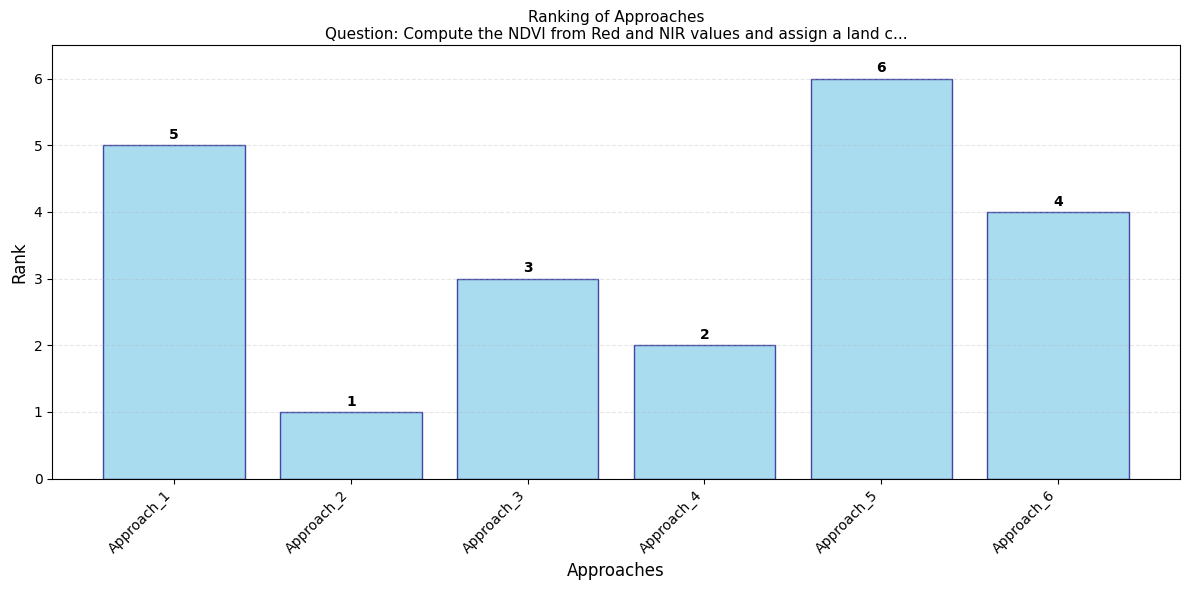

Plotting for question: Classify a pixel as 'urban' if NDVI < 0.2, 'vegetation' if NDVI > 0.3, and 'transition' otherwise.


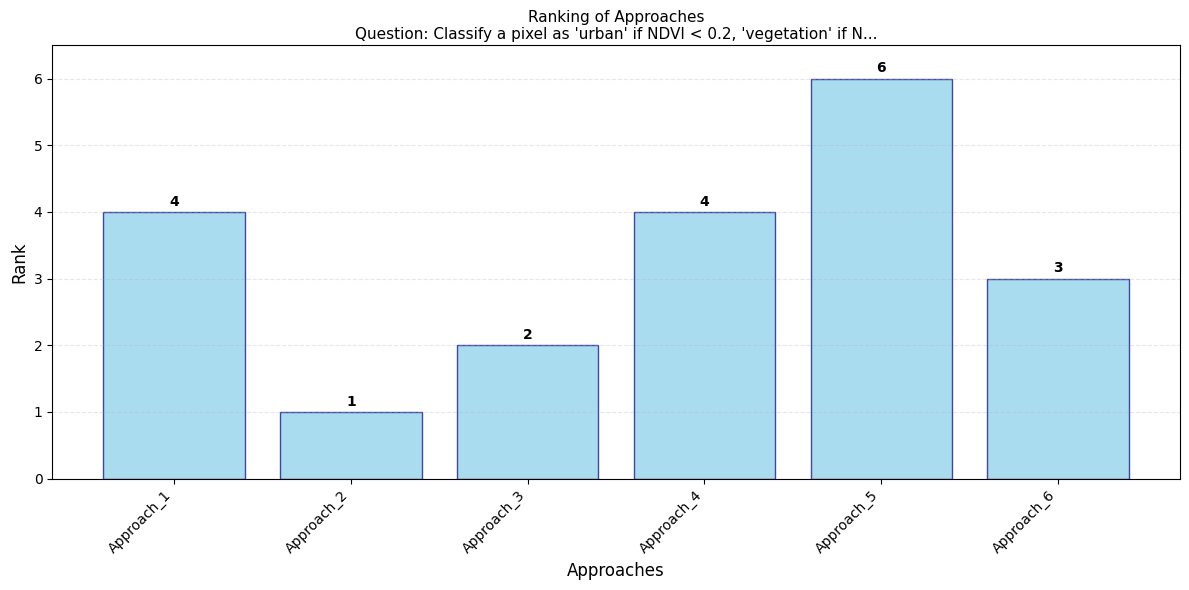

Plotting for question: Classify land cover from NDVI.


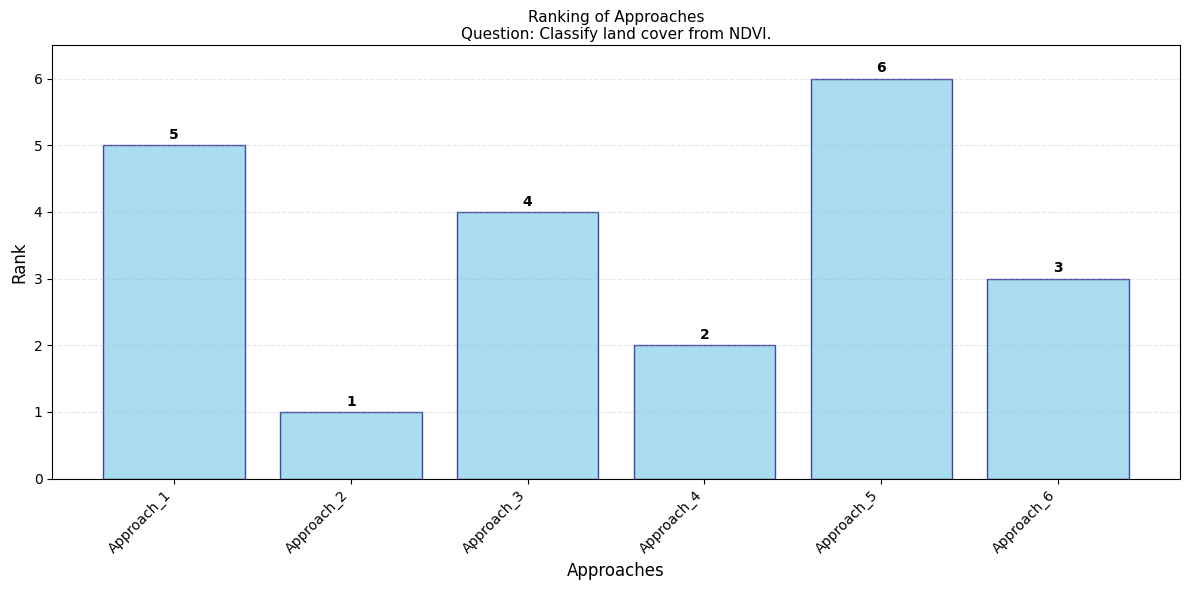

Plotting for question: Write Python code to compute and interpret NDVI from a given pair of reflectance values.


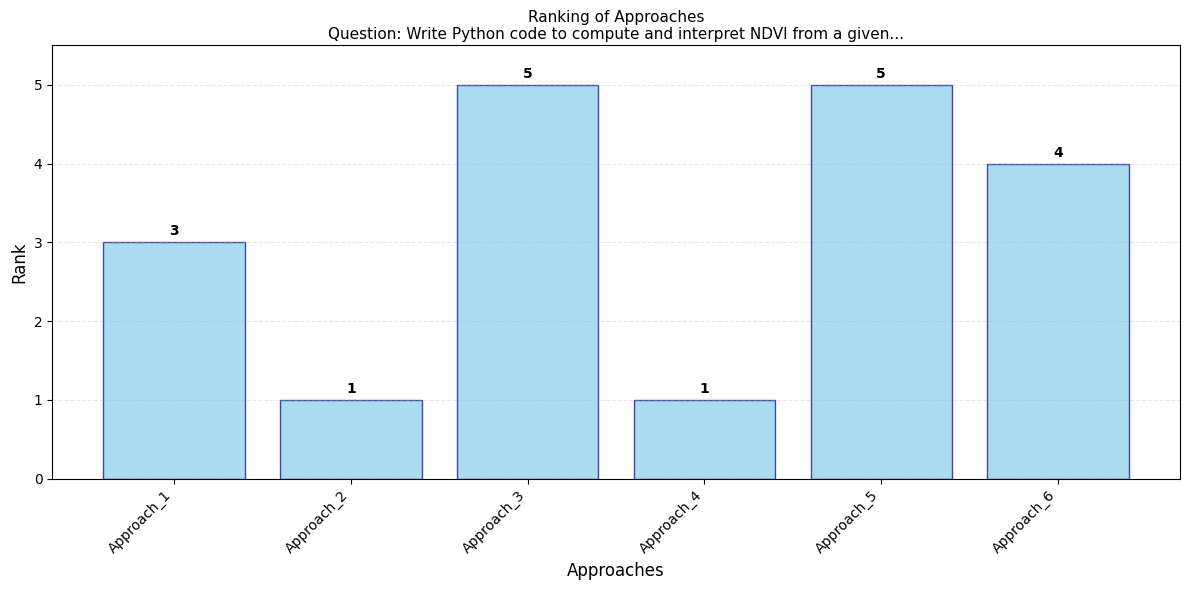

Plotting for question: Given the red and NIR reflectance of a pixel, write Python code to compute NDVI.


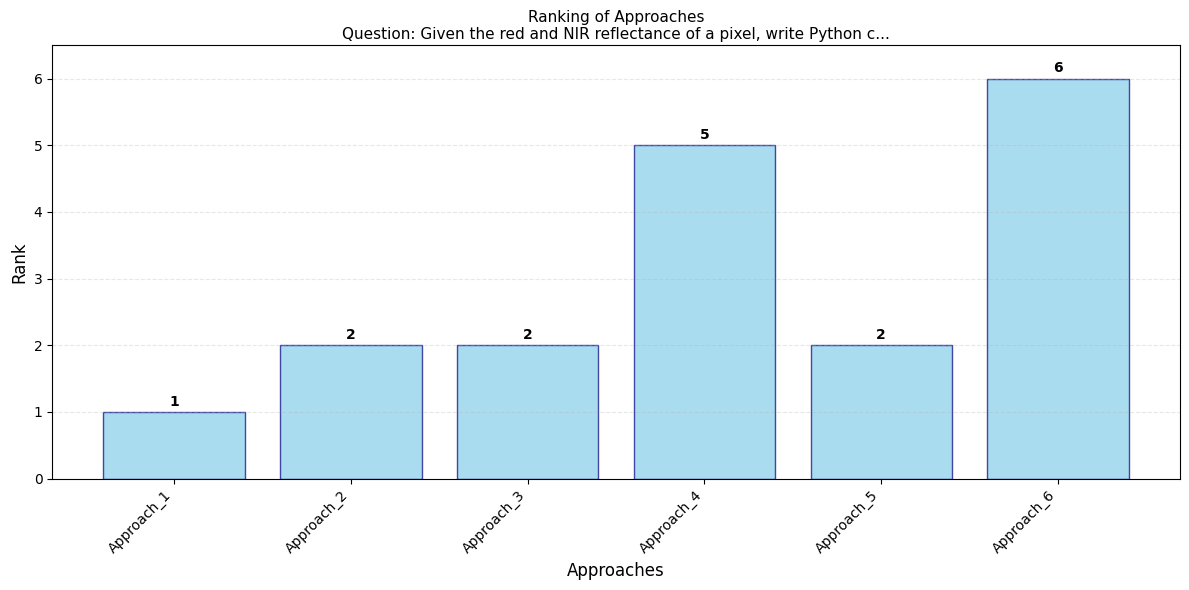

Plotting for question: Given the following spectral band values for a pixel: [Red=0.15, Green=0.35, Blue=0.20, NIR=0.60], write a code in Python to classify the land cover as either 'vegetation', 'water', or 'urban'.


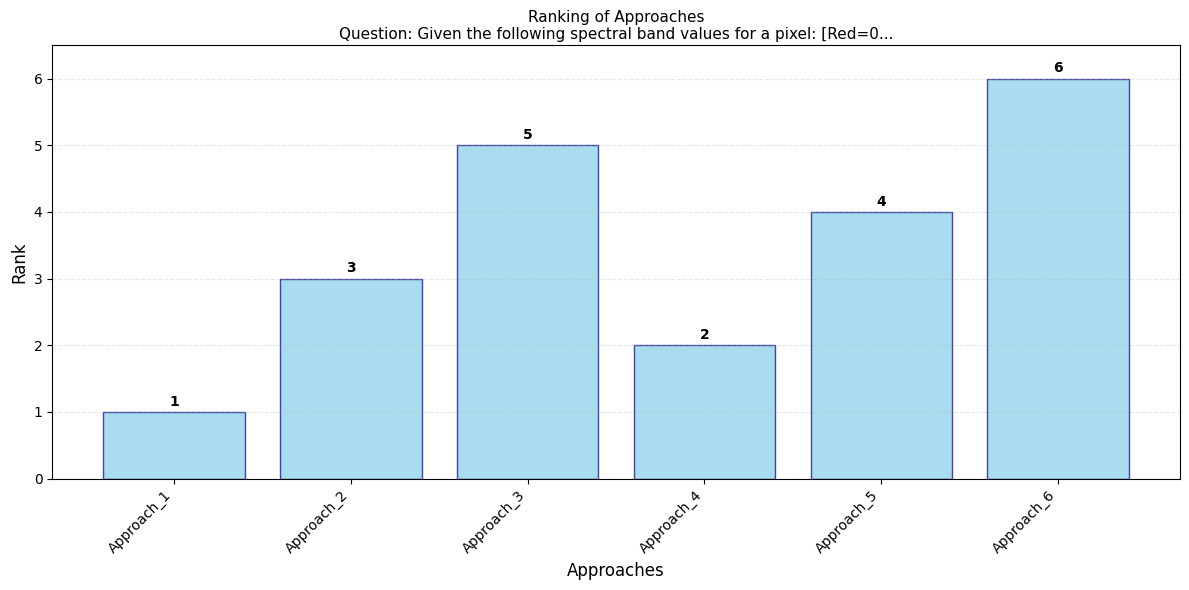

Plotting for question: Given the spectral band values for a pixel, write a Python function to classify it as 'vegetation', 'water', or 'urban' based on NDVI.


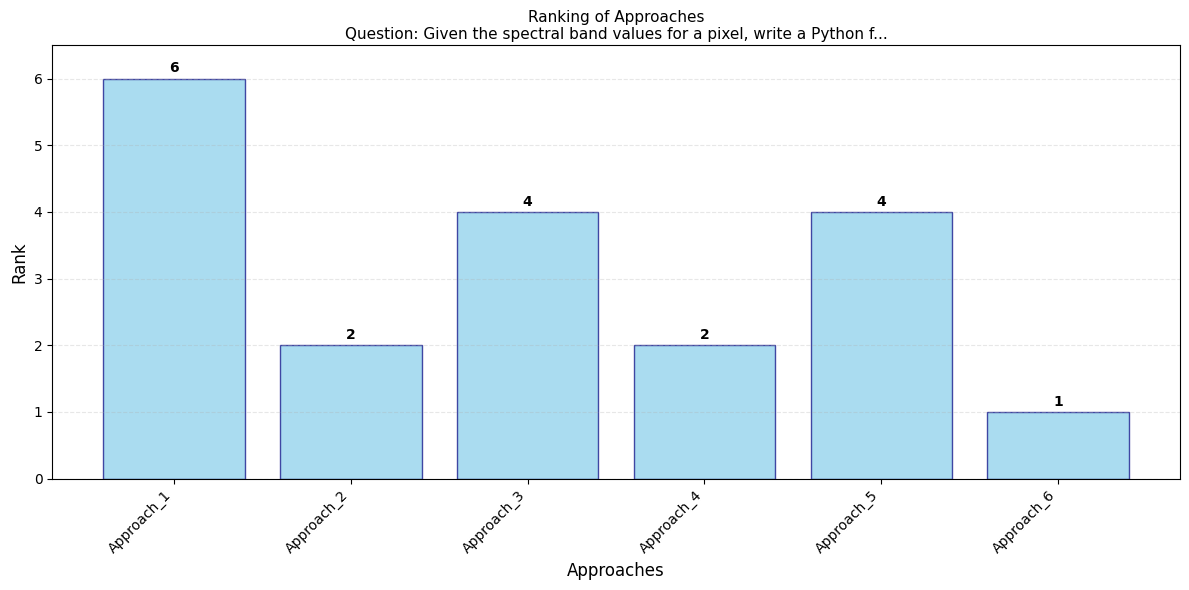

Plotting for question: Write code to classify NDVI into 'vegetation', 'urban', or 'transition' using thresholds 0.3 and 0.2.


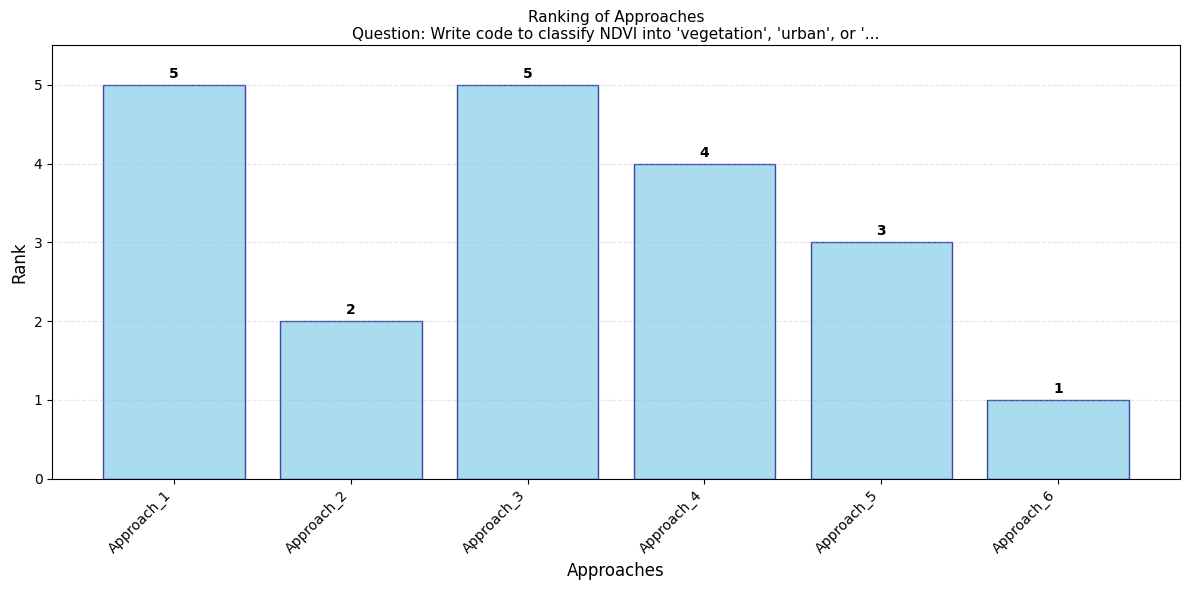

Plotting for question: Given the red and near-infrared (NIR) reflectance values of a pixel, compute the NDVI: (NIR - Red) / (NIR + Red). Return 0 if the denominator is zero.


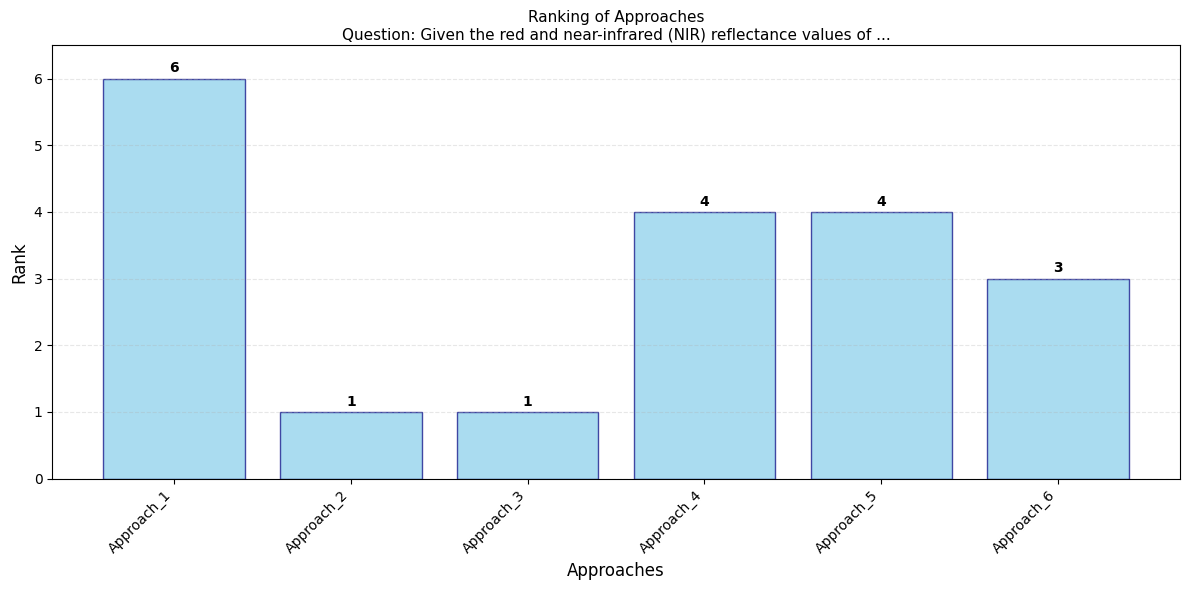

In [71]:
for question in reranked_df['question'].unique():
    plt.figure(figsize=(12, 6))
    print(f"Plotting for question: {question}")
    question_data = reranked_df[reranked_df['question'] == question]
    
    # Extract rank columns - filter the columns properly
    # rank_columns = [col for col in question_data.columns if col.endswith('_final_rank')]
    # print(rank_columns)
    rank_columns = [
    'Approach_1_final_rank',
    'Approach_2_final_rank',
    'Approach_3_final_rank',
    'Approach_4_final_rank',
    'Approach_5_final_rank',
    'Approach_6_final_rank'
    ]

    if rank_columns:
        # Get the data for plotting
        plot_data = question_data[rank_columns].iloc[0]
        
        # Create more readable labels (remove '_final_rank' suffix)
        approach_labels = [col.replace('_final_rank', '') for col in rank_columns]
        
        # Create the bar plot
        plt.bar(approach_labels, plot_data.values, color='skyblue', edgecolor='navy', alpha=0.7)
        
        # Customize the plot
        plt.ylabel('Rank', fontsize=12)
        plt.xlabel('Approaches', fontsize=12)
        plt.title(f"Ranking of Approaches\nQuestion: {question[:60]}{'...' if len(question) > 60 else ''}", 
                  fontsize=11, wrap=True)
        plt.xticks(rotation=45, ha='right')
        
        # Add value labels on top of bars
        for i, v in enumerate(plot_data.values):
            plt.text(i, v + 0.05, str(int(v)), ha='center', va='bottom', fontweight='bold')
        
        # Set y-axis to start from 0 and add some padding
        plt.ylim(0, max(plot_data.values) + 0.5)
        
        # Add grid for better readability
        plt.grid(axis='y', alpha=0.3, linestyle='--')
        
        plt.tight_layout()
        plt.show()
    

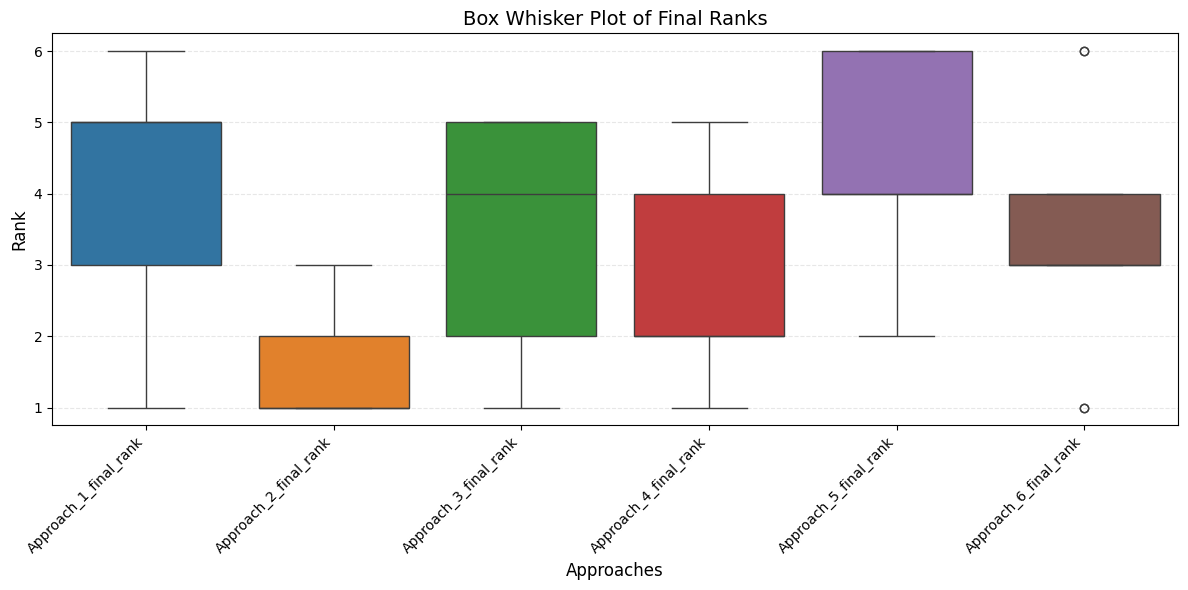

In [72]:
# plot the box whisker plot of final_rank
plt.figure(figsize=(12, 6))
sns.boxplot(data=reranked_df[rank_columns])
plt.title("Box Whisker Plot of Final Ranks", fontsize=14)
plt.ylabel("Rank", fontsize=12)
plt.xlabel("Approaches", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

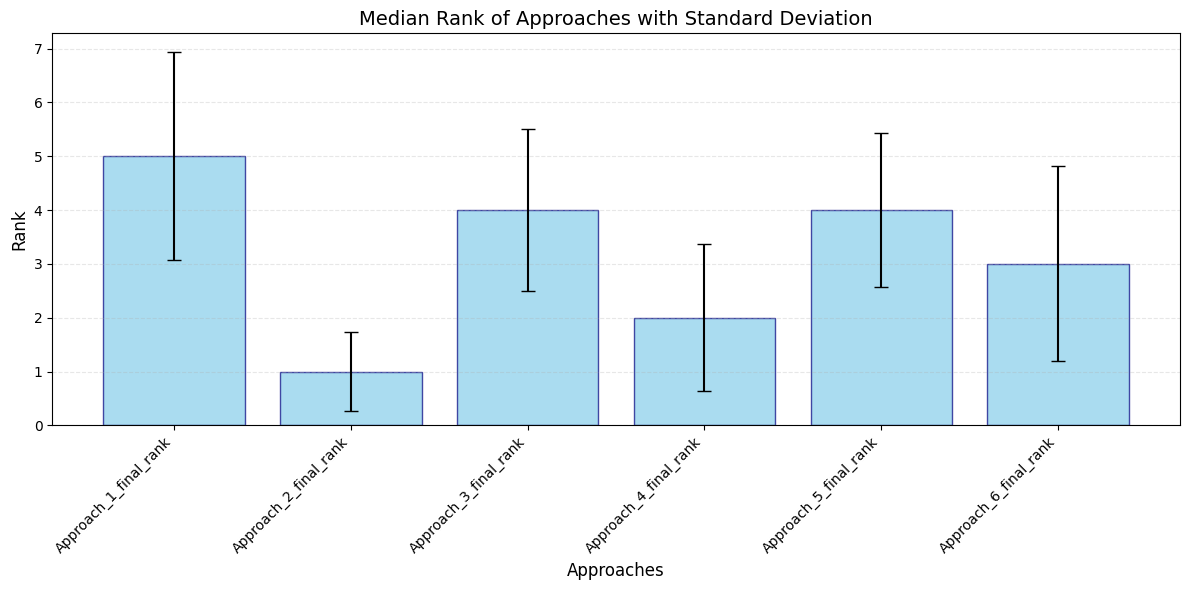

In [73]:
# can plot only the median rank for each final approach with the std as error bars
median_ranks = reranked_df[rank_columns].median()
std_ranks = reranked_df[rank_columns].std()

plt.figure(figsize=(12, 6))
plt.bar(median_ranks.index, median_ranks.values, yerr=std_ranks.values, capsize=5, color='skyblue', edgecolor='navy', alpha=0.7)
plt.title("Median Rank of Approaches with Standard Deviation", fontsize=14)
plt.ylabel("Rank", fontsize=12)
plt.xlabel("Approaches", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [30]:
reasoning_df = pd.read_csv("C:/Users/Theo/Documents/Projects/LLM_Code_Generation/LLM_fo_Code_Gen/annotations/participants/11 Step (TextResponse).csv", skiprows=1)
reasoning_df

,Answer Id,Answer,Approved,Created By Id,Created By Display Name,Created At
0,68a331b529502f078401aa23,The ranking was mostly based on the relevance ...,False,68a331b529502f078401aa0e,Participant 6,"18 Aug 2025, 01:59 pm"
1,68a318b1114dd8f41d17c4a2,I mostly looked at readability. If the solutio...,False,68a318b0114dd8f41d17c48d,Participant 5,"18 Aug 2025, 12:12 pm"
2,68a2df11114dd8f41d10b0dd,1) conciseness of the code\n\n2) the code just...,False,68a2df11114dd8f41d10b0c8,Participant 4,"18 Aug 2025, 08:06 am"
3,68a230c8905d497748be6bb4,"For the abstract questions, my rankings are ba...",False,68a230c8905d497748be6b9f,Participant 3,"17 Aug 2025, 07:43 pm"



Original text length: 1235 characters
Filtered text length: 689 characters

Generating word cloud...


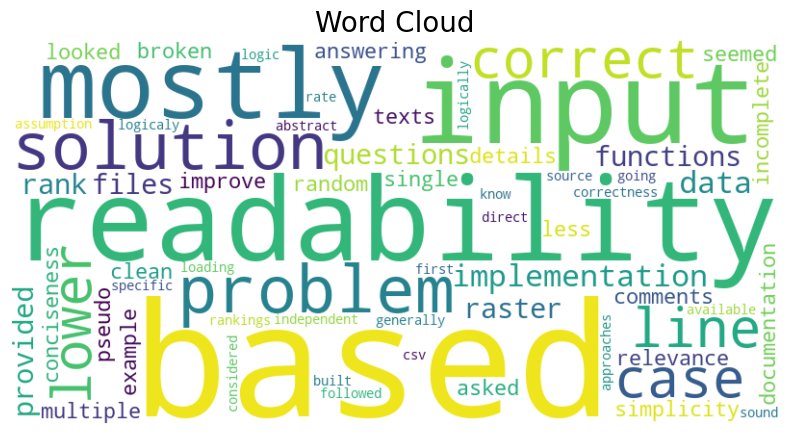

In [35]:
# Combine all text from the Answer column
answer_text = ' '.join(reasoning_df['Answer'].dropna().astype(str))

# Clean the text for word cloud
import re
# Remove extra whitespace and clean up the text
answer_text = re.sub(r'\s+', ' ', answer_text)  # Replace multiple spaces with single space
answer_text = re.sub(r'[^\w\s]', ' ', answer_text)  # Remove punctuation
answer_text = answer_text.lower()  # Convert to lowercase

# Remove common stop words using the existing function logic
stop_words = set(stopwords.words('english'))
# Add some domain-specific stop words that might not be meaningful
stop_words.update(['approach', 'code', 'function', 'python', 'use', 'using', 'used', 'would', 'could', 'should', 'ranked', 'higher','ranking'])

# Filter out stop words
words = answer_text.split()
filtered_words = [word for word in words if word.lower() not in stop_words and len(word) > 2]
filtered_text = ' '.join(filtered_words)

print(f"\nOriginal text length: {len(answer_text)} characters")
print(f"Filtered text length: {len(filtered_text)} characters")

# Create word cloud using the existing function
print("\nGenerating word cloud...")
plot_word_cloud(filtered_text)

##### ChatGPT Ranking

In [74]:
# Convert the ranking data to a DataFrame

import pandas as pd
from io import StringIO

# Create the CSV data as a string
csv_data = """question,approach_1,approach_2,approach_3,approach_4,approach_5,approach_6
Compute the NDVI from Red and NIR values and assign a land cover category.,2,3,1,5,6,4
"Classify a pixel as 'urban' if NDVI < 0.2, 'vegetation' if NDVI > 0.3, and 'transition' otherwise.",3,4,5,2,6,1
Classify land cover from NDVI.,4,2,5,1,6,3
Write Python code to compute and interpret NDVI from a given pair of reflectance values.,1,3,5,4,6,2
"Given the red and NIR reflectance of a pixel, write Python code to compute NDVI.",1,4,5,6,2,3
"Given the following spectral band values for a pixel: [Red=0.15... cover as either 'vegetation', 'water', or 'urban'.",5,3,4,1,6,2
"Given the spectral band values for a pixel, write a Python func...as 'vegetation', 'water', or 'urban' based on NDVI.",5,3,6,2,1,4
"Write code to classify NDVI into 'vegetation', 'urban', or 'transition' using thresholds 0.3 and 0.2.",1,4,5,6,2,3
"Given the red and near-infrared (NIR) reflectance values of a p.../ (NIR + Red). Return 0 if the denominator is zero.",5,2,6,3,4,1"""

# Read the CSV data into a DataFrame
ranking_data_df = pd.read_csv(StringIO(csv_data))

# Display the DataFrame
print("Ranking Data DataFrame:")
print(ranking_data_df)
print(f"\nDataFrame shape: {ranking_data_df.shape}")
print(f"Columns: {ranking_data_df.columns.tolist()}")

# Show data types
print(f"\nData types:")
print(ranking_data_df.dtypes)

# Optional: Clean up question text for better display
ranking_data_df['question_short'] = ranking_data_df['question'].apply(lambda x: x[:50] + '...' if len(x) > 50 else x)
print(f"\nDataFrame with shortened questions:")

ranking_data_df[['question_short', 'approach_1', 'approach_2', 'approach_3', 'approach_4', 'approach_5', 'approach_6']].head()

Ranking Data DataFrame:
                                            question  approach_1  approach_2  \
0  Compute the NDVI from Red and NIR values and a...           2           3   
1  Classify a pixel as 'urban' if NDVI < 0.2, 've...           3           4   
2                     Classify land cover from NDVI.           4           2   
3  Write Python code to compute and interpret NDV...           1           3   
4  Given the red and NIR reflectance of a pixel, ...           1           4   
5  Given the following spectral band values for a...           5           3   
6  Given the spectral band values for a pixel, wr...           5           3   
7  Write code to classify NDVI into 'vegetation',...           1           4   
8  Given the red and near-infrared (NIR) reflecta...           5           2   

   approach_3  approach_4  approach_5  approach_6  
0           1           5           6           4  
1           5           2           6           1  
2           5      

,question_short,approach_1,approach_2,approach_3,approach_4,approach_5,approach_6
0,Compute the NDVI from Red and NIR values and a...,2,3,1,5,6,4
1,"Classify a pixel as 'urban' if NDVI < 0.2, 've...",3,4,5,2,6,1
2,Classify land cover from NDVI.,4,2,5,1,6,3
3,Write Python code to compute and interpret NDV...,1,3,5,4,6,2
4,"Given the red and NIR reflectance of a pixel, ...",1,4,5,6,2,3


In [75]:
ranking_data_df = ranking_data_df[['question', 'approach_1', 'approach_2', 'approach_3', 'approach_4', 'approach_5', 'approach_6']]
ranking_data_df

,question,approach_1,approach_2,approach_3,approach_4,approach_5,approach_6
0,Compute the NDVI from Red and NIR values and a...,2,3,1,5,6,4
1,"Classify a pixel as 'urban' if NDVI < 0.2, 've...",3,4,5,2,6,1
2,Classify land cover from NDVI.,4,2,5,1,6,3
3,Write Python code to compute and interpret NDV...,1,3,5,4,6,2
4,"Given the red and NIR reflectance of a pixel, ...",1,4,5,6,2,3
5,Given the following spectral band values for a...,5,3,4,1,6,2
6,"Given the spectral band values for a pixel, wr...",5,3,6,2,1,4
7,"Write code to classify NDVI into 'vegetation',...",1,4,5,6,2,3
8,Given the red and near-infrared (NIR) reflecta...,5,2,6,3,4,1


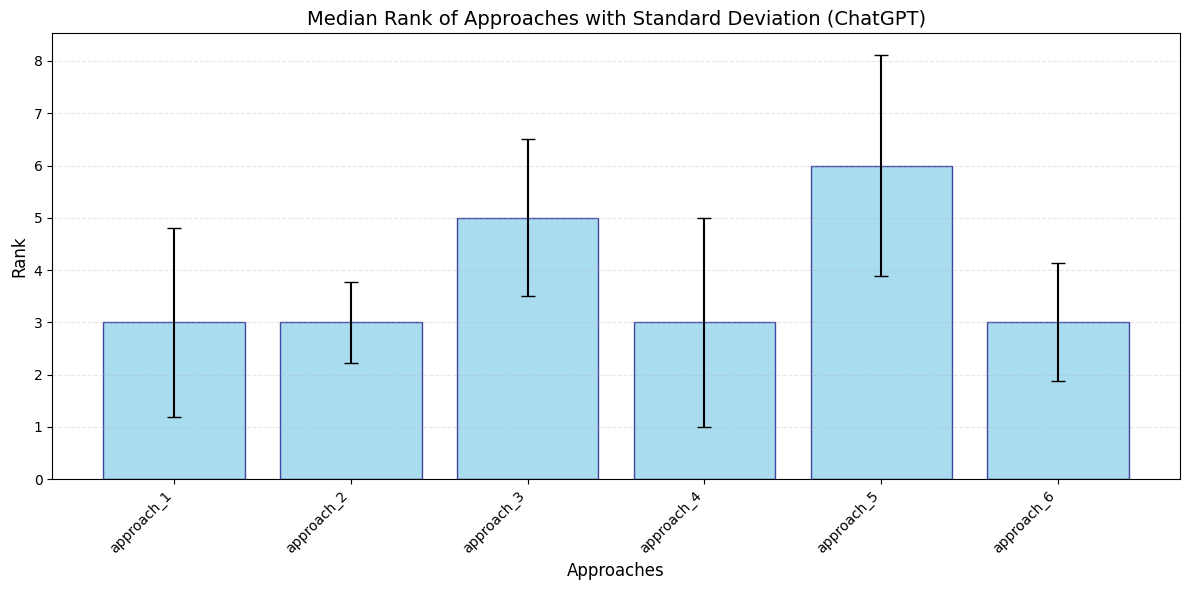

In [76]:
# can plot only the median rank for each final approach with the std as error bars
rank_columns = ['approach_1', 'approach_2', 'approach_3', 'approach_4', 'approach_5', 'approach_6']
median_ranks = ranking_data_df[rank_columns].median()
std_ranks = ranking_data_df[rank_columns].std()

plt.figure(figsize=(12, 6))
plt.bar(median_ranks.index, median_ranks.values, yerr=std_ranks.values, capsize=5, color='skyblue', edgecolor='navy', alpha=0.7)
plt.title("Median Rank of Approaches with Standard Deviation (ChatGPT)", fontsize=14)
plt.ylabel("Rank", fontsize=12)
plt.xlabel("Approaches", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


Plotting for question: Compute the NDVI from Red and NIR values and assign a land cover category.


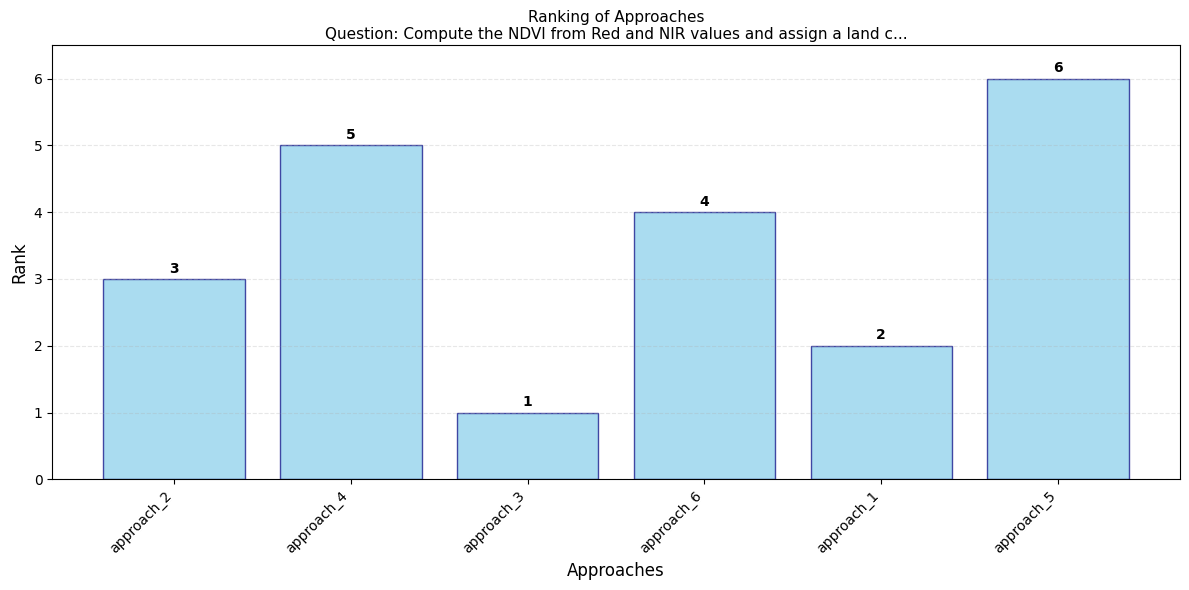

Plotting for question: Classify a pixel as 'urban' if NDVI < 0.2, 'vegetation' if NDVI > 0.3, and 'transition' otherwise.


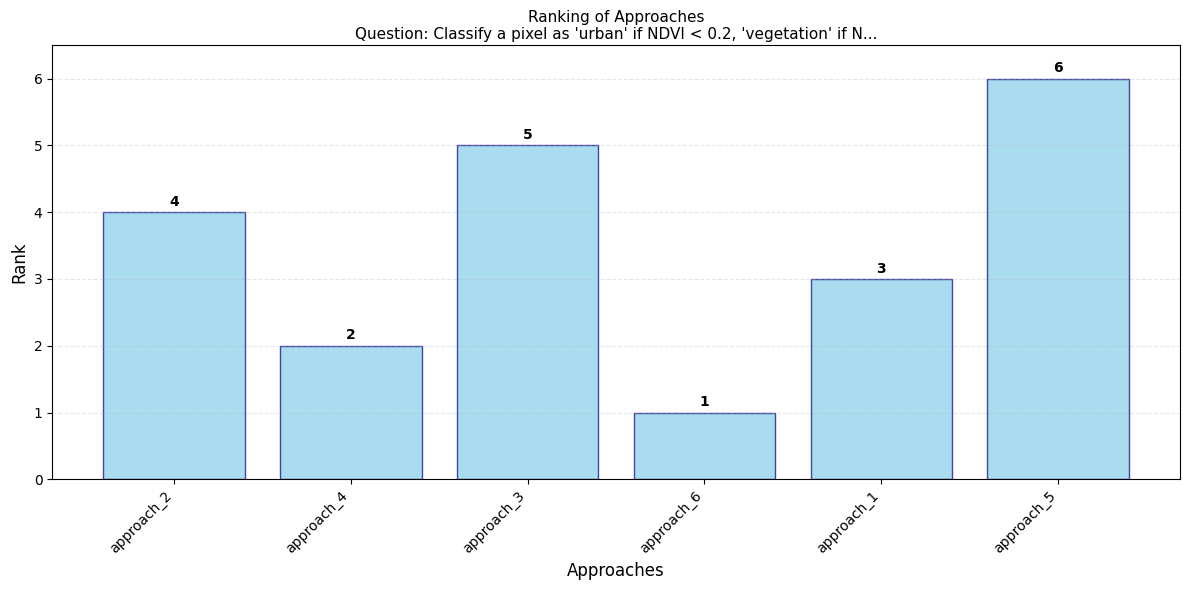

Plotting for question: Classify land cover from NDVI.


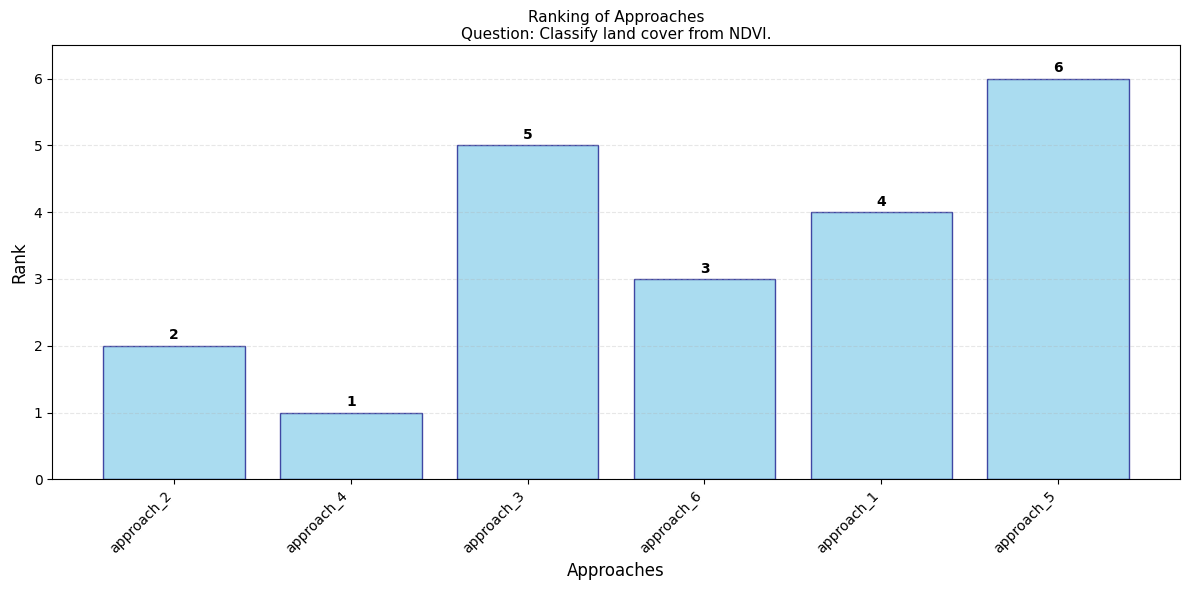

Plotting for question: Write Python code to compute and interpret NDVI from a given pair of reflectance values.


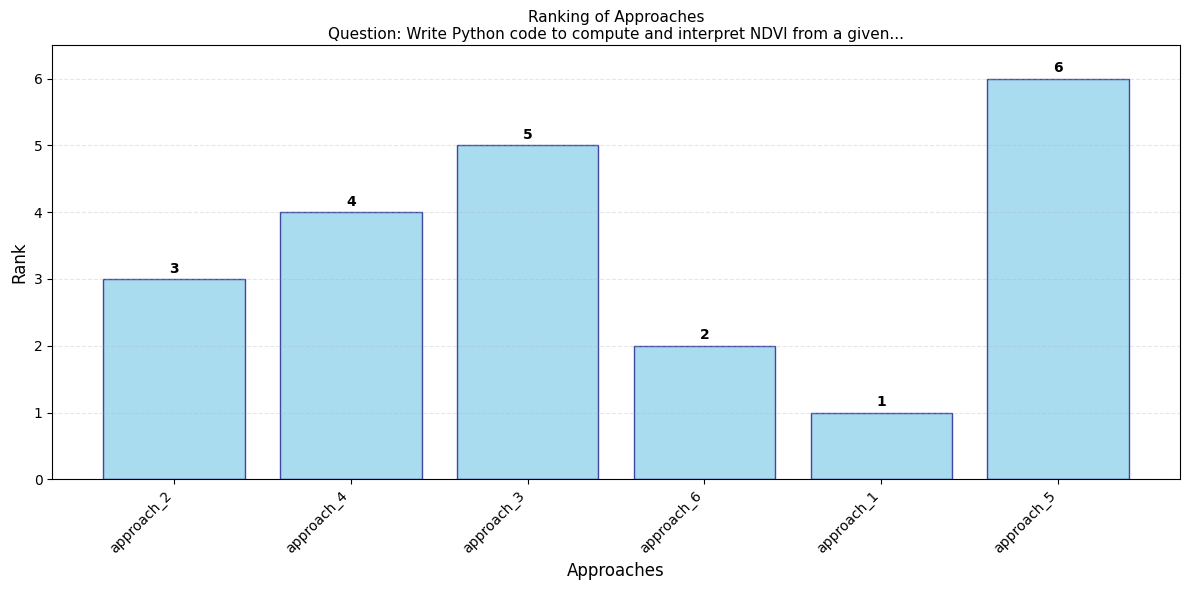

Plotting for question: Given the red and NIR reflectance of a pixel, write Python code to compute NDVI.


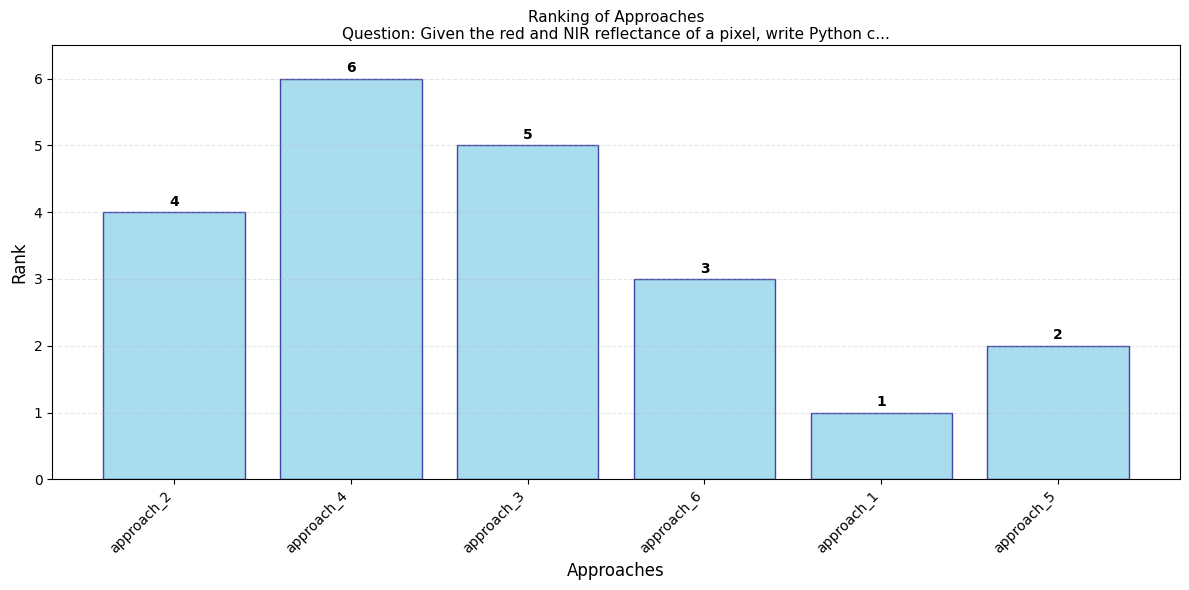

Plotting for question: Given the following spectral band values for a pixel: [Red=0.15... cover as either 'vegetation', 'water', or 'urban'.


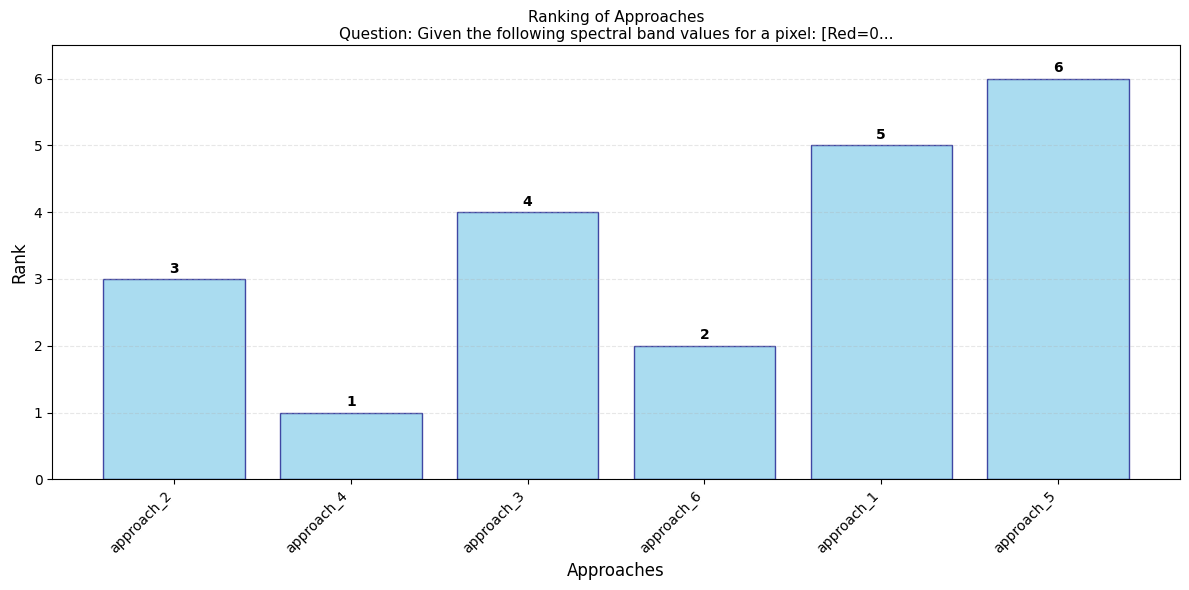

Plotting for question: Given the spectral band values for a pixel, write a Python func...as 'vegetation', 'water', or 'urban' based on NDVI.


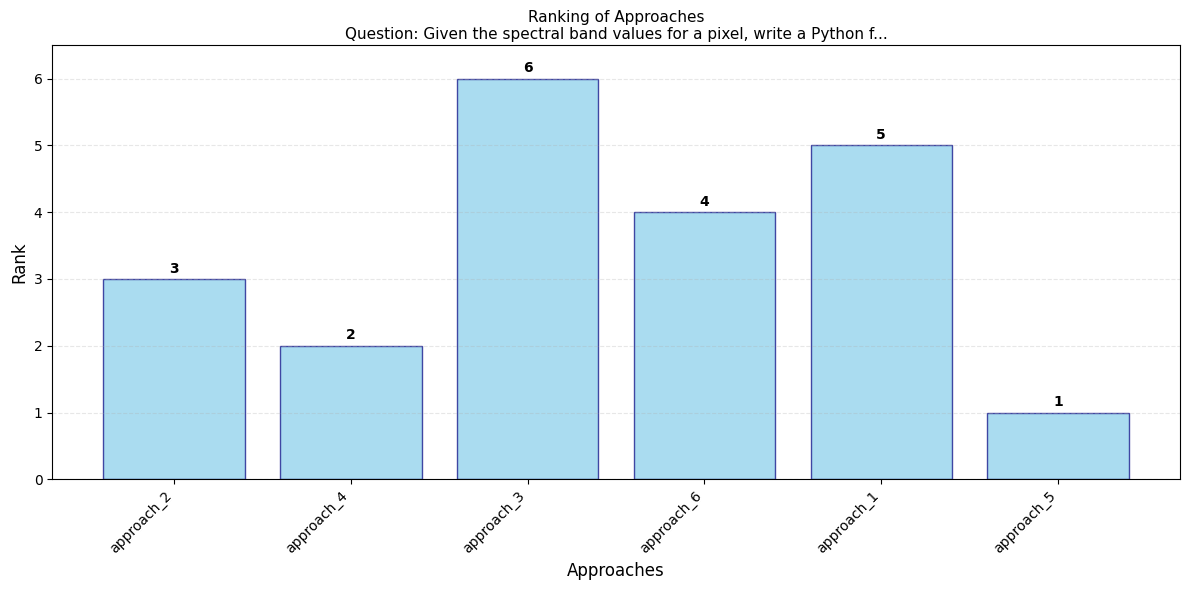

Plotting for question: Write code to classify NDVI into 'vegetation', 'urban', or 'transition' using thresholds 0.3 and 0.2.


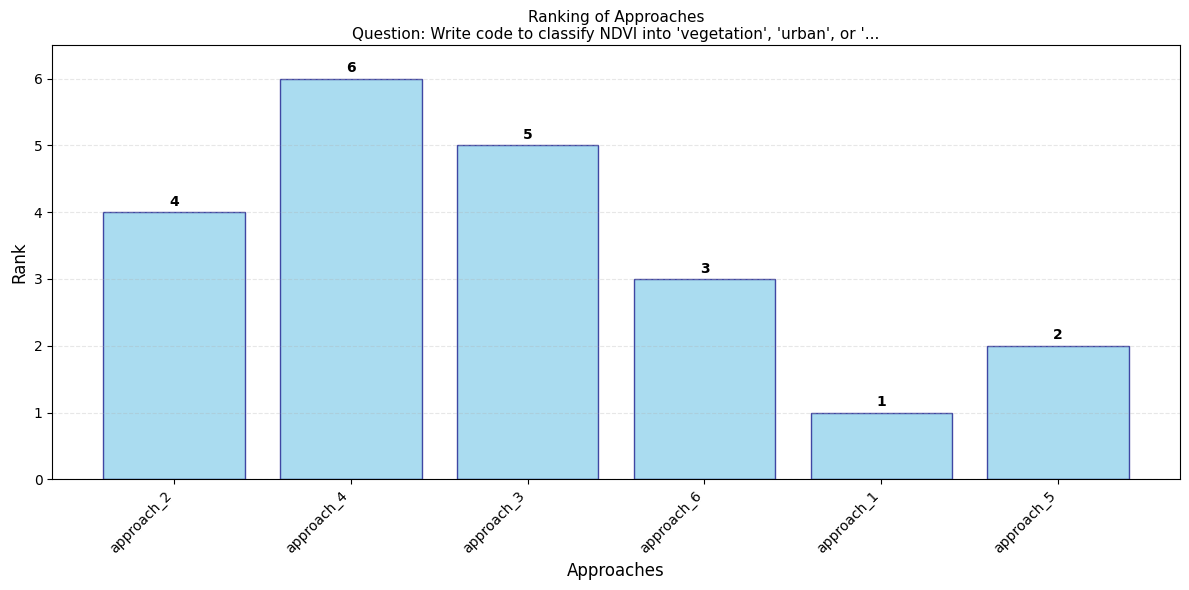

Plotting for question: Given the red and near-infrared (NIR) reflectance values of a p.../ (NIR + Red). Return 0 if the denominator is zero.


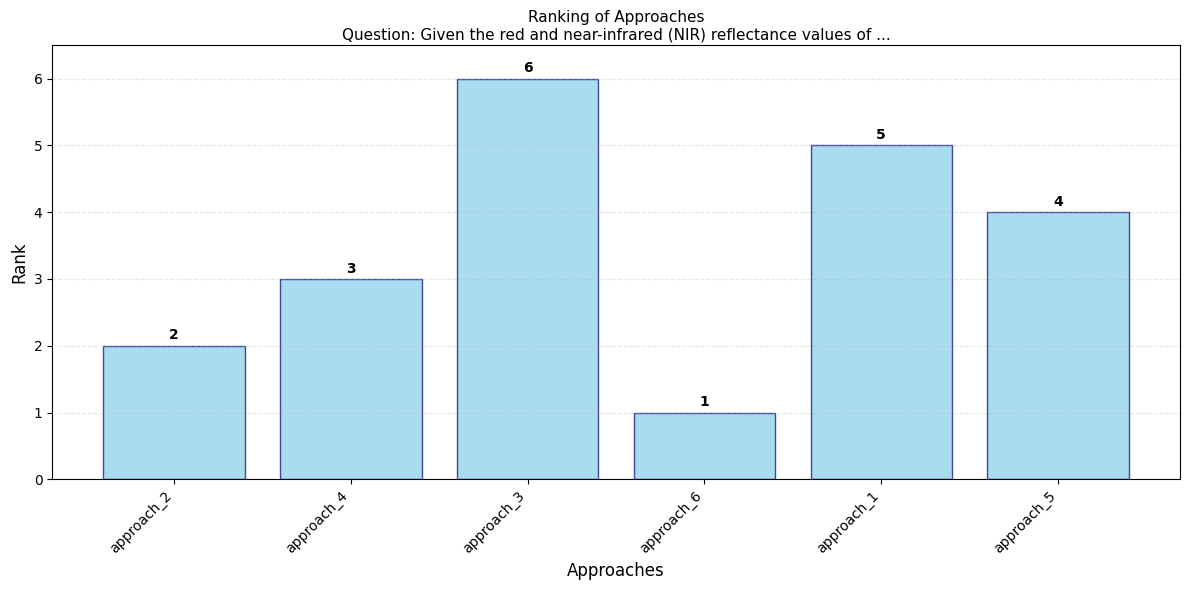

In [42]:
for question in ranking_data_df['question'].unique():
    plt.figure(figsize=(12, 6))
    print(f"Plotting for question: {question}")
    question_data = ranking_data_df[ranking_data_df['question'] == question]
    
    if rank_columns:
        # Get the data for plotting
        plot_data = question_data[rank_columns].iloc[0]
        
        # Create more readable labels (remove '_final_rank' suffix)
        approach_labels = [col.replace('_final_rank', '') for col in rank_columns]
        
        # Create the bar plot
        plt.bar(approach_labels, plot_data.values, color='skyblue', edgecolor='navy', alpha=0.7)
        
        # Customize the plot
        plt.ylabel('Rank', fontsize=12)
        plt.xlabel('Approaches', fontsize=12)
        plt.title(f"Ranking of Approaches\nQuestion: {question[:60]}{'...' if len(question) > 60 else ''}", 
                  fontsize=11, wrap=True)
        plt.xticks(rotation=45, ha='right')
        
        # Add value labels on top of bars
        for i, v in enumerate(plot_data.values):
            plt.text(i, v + 0.05, str(int(v)), ha='center', va='bottom', fontweight='bold')
        
        # Set y-axis to start from 0 and add some padding
        plt.ylim(0, max(plot_data.values) + 0.5)
        
        # Add grid for better readability
        plt.grid(axis='y', alpha=0.3, linestyle='--')
        
        plt.tight_layout()
        plt.show()
    

#### Comparison with new prompt approach

In [ ]:
question = "Compute the NDVI from Red and NIR values and assign a land cover category."

best_approach = ''' import numpy as np 
def compute_ndvi(red, nir): ndvi = (nir - red) / (nir + red + 1e-8) 
    return ndvi 

def classify_land_cover(ndvi): 
    if ndvi >= 0.5: 
        return 'Vegetation' 
    elif 0.5 > ndvi >= 0: 
        return 'Urban' 
    else: 
        return 'Water/Snow' 

# Example usage 
red = np.array([10, 20, 30, 40, 50]) 
nir = np.array([100, 200, 300, 400, 500]) 
ndvi_values = compute_ndvi(red, nir) 
land_cover_categories = [classify_land_cover(x) for x in ndvi_values] 
print(land_cover_categories)
'''

approach_7 =  '''
Function NDVI_LandCover_Assignment(Red, NIR):
    # Calculate NDVI
    ndvi = (NIR - Red) / (NIR + Red)

    # Assign Land Cover Category
    if ndvi > 0.3:
        category = "High Vegetation"
    elif ndvi > 0.2:
        category = "Medium Vegetation"
    else:
        category = "No Vegetation"

    return ndvi, category
'''
approach_8 =  ''' 
import numpy as np
def compute_ndvi_and_land_cover(red_values, nir_values):
    ndvi_values = []
    land_cover_categories = []

    for red, nir in zip(red_values, nir_values):
        ndvi = (nir - red) / (nir + red + 1e-8)
        ndvi_values.append(ndvi)

        if ndvi >= 0.5:
            land_cover_categories.append(1)  # vegetation
        elif 0.5 > ndvi >= 0:
            land_cover_categories.append(0.5)  # urban
        else:
            land_cover_categories.append(0)  # water/snow

    return ndvi_values, land_cover_categories

# Example usage:
red_values = [0.5, 0.4, 0.3]
nir_values = [0.6, 0.5, 0.4]

ndvi, land_cover = compute_ndvi_and_land_cover(red_values, nir_values)
print("NDVI Values:", ndvi)
print("Land Cover Categories:", land_cover)
'''

approach_9 = ''' # Input: Red and NIR values
red_band =...  # Get the Red band values
nir_band =...  # Get the NIR band values

# Calculate NDVI
ndvi = (nir_band - red_band) / (nir_band + red_band)

# Assign land cover category
if ndvi > 0.5:
    land_cover = 'Vegetation'
elif ndvi < -0.5:
    land_cover = 'Water'
else:
    land_cover = 'Other'

# Output: NDVI and land cover category
print(f'NDVI: {ndvi:.2f}')
print(f'Land Cover: {land_cover}')
'''

approach_10 = '''
import numpy as np
def compute_ndvi(red, nir):
    ndvi = (nir - red) / (nir + red + 1e-8)
    return ndvi

def classify_land_cover(ndvi):
    land_cover = np.where(ndvi >= 0.5,'vegetation', np.where(0.5 > ndvi >= 0, 'urban', 'water/snow'))
    return land_cover

def main(red, nir):
    ndvi = compute_ndvi(red, nir)
    land_cover = classify_land_cover(ndvi)
    return ndvi, land_cover

red = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
nir = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0])

ndvi, land_cover = main(red, nir)
print('NDVI:', ndvi)
print('Land Cover:', land_cover)
'''

approach_11 = '''
def generate_code(prompt):
    response = openai.Completion.create(
        engine="text-davinci-002",
        prompt=prompt,
        temperature=0.5,
        max_tokens=1000
    )
    return response.choices[0].text.strip()

print(generate_code(prompt))
'''

approach_12 = '''
import numpy as np
def compute_ndvi_and_land_cover(red_values, nir_values):
    ndvi_values = []
    land_cover_categories = []

    for red, nir in zip(red_values, nir_values):
        ndvi = (nir - red) / (nir + red + 1e-8)
        ndvi_values.append(ndvi)

        if ndvi >= 0.5:
            land_cover_categories.append(1)  # vegetation
        elif 0.5 > ndvi >= 0:
            land_cover_categories.append(0.5)  # urban
        else:
            land_cover_categories.append(0)  # water/snow

    return ndvi_values, land_cover_categories

# Example usage:
red_values = [0.5, 0.4, 0.3]
nir_values = [0.6, 0.5, 0.4]

ndvi, land_cover = compute_ndvi_and_land_cover(red_values, nir_values)
print("NDVI Values:", ndvi)
print("Land Cover Categories:", land_cover)
'''

approach_13 = '''
import numpy as np
import rasterio
from rasterio.plot import show

# Load the raster data
with rasterio.open('input_raster.tif') as src:
    red_band = src.read(1)
    nir_band = src.read(2)

# Calculate NDVI
ndvi = (nir_band - red_band) / (nir_band + red_band)

# Assign land cover category
ndvi_categories = np.where(ndvi > 0.5,'vegetation', np.where(ndvi < -0.5, 'water', 'other'))

# Visualize the results
show(ndvi_categories, cmap='viridis')
'''

#### Analysing output of no_reason, manual reason, reason , with ranking

##### Combining all parts jsons

In [8]:
from glob import glob
all_parts_jsons = glob("../all_downloads/data_output_reasoning_with_none_reason_manual_part_*.json", recursive=True)

#combine all jsons into a single dataframe
all_data_ls = []
for json_file in all_parts_jsons:
    with open(json_file) as f:
        data_part = json.load(f)
    data_part_df = pd.DataFrame(data_part)
    all_data_ls.append(data_part_df)
all_data_df = pd.concat(all_data_ls, ignore_index=True)
all_data_df.reset_index(drop=True, inplace=True)
all_data_df.to_excel("../all_downloads/combined_data_output_reasoning_with_none_reason_manual.xlsx", index=False)
all_data_df.head()

,reasoner,coder,plan,code,question,reasoning_type,reasoning_approach,ranker
0,microsoft/wavecoder-ultra-6.7b,meta-llama/Meta-Llama-3-8B-instruct,\n Act as an expert Python prog...,"```\ndef NDVI_classifier(red_reflectance, nir_...",Given the red and near-infrared (NIR) reflecta...,automated,doc,meta-llama/Meta-Llama-3-8B-instruct
1,microsoft/wavecoder-ultra-6.7b,meta-llama/Meta-Llama-3-8B-instruct,{'domain': 'Classify the scientific domain of ...,"```python\ndef compute_ndvi(red, nir):\n if...",Given the red and near-infrared (NIR) reflecta...,automated,sections,meta-llama/Meta-Llama-3-8B-instruct
2,microsoft/wavecoder-ultra-6.7b,meta-llama/Meta-Llama-3-8B-instruct,\n Act as an expert Python prog...,"```\nimport math\n\ndef classify_pixel(red, gr...",Given the spectral band values for a pixel: [R...,automated,doc,meta-llama/Meta-Llama-3-8B-instruct
3,microsoft/wavecoder-ultra-6.7b,meta-llama/Meta-Llama-3-8B-instruct,{'domain': 'Classify the scientific domain of ...,```python\nred = 0.15\ngreen = 0.35\nblue = 0....,Given the spectral band values for a pixel: [R...,automated,sections,meta-llama/Meta-Llama-3-8B-instruct
4,microsoft/wavecoder-ultra-6.7b,meta-llama/Meta-Llama-3-8B-instruct,\n Act as an expert Python prog...,"```\ndef classify_landcover(red_band, nir_band...",Write a Python function that takes the spectra...,automated,doc,meta-llama/Meta-Llama-3-8B-instruct


In [126]:
all_data_df['question'].unique()

array(['Given the red and near-infrared (NIR) reflectance values of a pixel as floating-point numbers, write Python code to compute the NDVI: (NIR - Red) / (NIR + Red). Return 0 if the denominator is zero, and classify the pixel as ‘vegetation’ if NDVI > 0.3, ‘urban’ if NDVI < 0.2, and ‘transition’ otherwise.',
       'Given the spectral band values for a pixel: [Red = 0.15, Green = 0.35, Blue = 0.20, NIR = 0.60], write Python code to compute NDVI and classify the pixel as ‘vegetation’, ‘water’, or ‘urban’ based on NDVI thresholds.',
       'Write a Python function that takes the spectral band values of a pixel (at minimum Red and NIR) as input, computes NDVI, and classifies the land cover as ‘vegetation’, ‘water’, or ‘urban’ using defined thresholds.',
       'Given a Sentinel-2 GeoTIFF file, write  a Python code to compute NDVI for every pixel and classify each pixel as ‘urban’ if NDVI < 0.2, ‘vegetation’ if NDVI > 0.3, and ‘transition’ otherwise.',
       'Write Python code to compu

##### Question 1

In [7]:
question = 'Given the red and near-infrared (NIR) reflectance values of a pixel as floating-point numbers, write Python code to compute the NDVI: (NIR - Red) / (NIR + Red). Return 0 if the denominator is zero, and classify the pixel as ‘vegetation’ if NDVI > 0.3, ‘urban’ if NDVI < 0.2, and ‘transition’ otherwise.'
sample_data = all_data_df[all_data_df['question'] == question]
sample_data = sample_data[(sample_data['coder'] == 'meta-llama/Meta-Llama-3-8B-instruct') & (sample_data['reasoner'] == 'meta-llama/Meta-Llama-3-8B-instruct')]
sample_data = sample_data[sample_data['ranker'] == 'meta-llama/Meta-Llama-3-8B-instruct']
for _, row in sample_data.iterrows():
    print(f"Question: {row['question']}")
    print(f"Reasoning Type: {row['reasoning_type']}")
    print(f"Reasoner: {row['reasoner']}")
    print(f"Reasoning Approach: {row['reasoning_approach']}")
    print(f"Coder: {row['coder']}")
    print(f"Plan:\n{row['plan']}")
    print(f"Code:\n{row['code']}")
    print(f"Ranker: {row['ranker']}")
    print("-" * 100)

Question: Given the red and near-infrared (NIR) reflectance values of a pixel as floating-point numbers, write Python code to compute the NDVI: (NIR - Red) / (NIR + Red). Return 0 if the denominator is zero, and classify the pixel as ‘vegetation’ if NDVI > 0.3, ‘urban’ if NDVI < 0.2, and ‘transition’ otherwise.
Reasoning Type: automated
Reasoner: meta-llama/Meta-Llama-3-8B-instruct
Reasoning Approach: doc
Coder: meta-llama/Meta-Llama-3-8B-instruct
Plan:

                Act as an expert Python programmer and logical driven code reasoner. Your task is to generate a code reasoning snippet in a detailed breakdown.

                User Request: Given the red and near-infrared (NIR) reflectance values of a pixel as floating-point numbers, write Python code to compute the NDVI: (NIR - Red) / (NIR + Red). Return 0 if the denominator is zero, and classify the pixel as ‘vegetation’ if NDVI > 0.3, ‘urban’ if NDVI < 0.2, and ‘transition’ otherwise.

                Please provide your response i

In [ ]:
question = "Given the red and near-infrared (NIR) reflectance values of a pixel as floating-point numbers, write Python code to compute the NDVI: (NIR - Red) / (NIR + Red). Return 0 if the denominator is zero, and classify the pixel as ‘vegetation’ if NDVI > 0.3, ‘urban’ if NDVI < 0.2, and ‘transition’ otherwise."
code_automated_doc= '''
def calculate_ndvi(red, nir):
    ndvi = (nir - red) / (nir + red) if nir + red!= 0 else 0
    if ndvi > 0.3:
        return'vegetation'
    elif ndvi < 0.2:
        return 'urban'
    else:
        return 'transition'
'''

code_automated_sections = '''
def compute_ndvi(red, nir):
    ndvi = (nir - red) / (nir + red)
    if ndvi == float('inf') or ndvi == -float('inf'):
        return 0
    elif ndvi > 0.3:
        return'vegetation'
    elif ndvi < 0.2:
        return 'urban'
    else:
        return 'transition'
'''

code_manual_doc = '''
def calculate_ndvi(red, nir):
    denominator = nir + red
    if denominator == 0:
        return 0
    ndvi = (nir - red) / denominator
    if ndvi > 0.3:
        return'vegetation'
    elif ndvi < 0.2:
        return 'urban'
    else:
        return 'transition'
'''

code_no_reasoning = '''
```
red = 0.5
nir = 1.0

ndvi = (nir - red) / (nir + red)

if ndvi > 0.3:
    print("Vegetation")
elif ndvi < 0.2:
    print("Urban")
else:
    print("Transition")

print(ndvi)
'''

##### Question 2

In [35]:
question = "Given the spectral band values for a pixel: [Red = 0.15, Green = 0.35, Blue = 0.20, NIR = 0.60], write Python code to compute NDVI and classify the pixel as ‘vegetation’, ‘water’, or ‘urban’ based on NDVI thresholds."
sample_data = all_data_df[all_data_df['question'] == question]
sample_data = sample_data[(sample_data['coder'] == 'meta-llama/Meta-Llama-3-8B-instruct') & (sample_data['reasoner'] == 'meta-llama/Meta-Llama-3-8B-instruct')]
sample_data = sample_data[sample_data['ranker'] == 'meta-llama/Meta-Llama-3-8B-instruct']
for _, row in sample_data.iterrows():
    print(f"Question: {row['question']}")
    print(f"Reasoning Type: {row['reasoning_type']}")
    print(f"Reasoner: {row['reasoner']}")
    print(f"Reasoning Approach: {row['reasoning_approach']}")
    print(f"Coder: {row['coder']}")
    print(f"Plan:\n{row['plan']}")
    print(f"Code:\n{row['code']}")
    print("-" * 100)
for _, row in sample_data.iterrows():
    print(f"Question: {row['question']}")
    print(f"Reasoning Type: {row['reasoning_type']}")
    print(f"Reasoner: {row['reasoner']}")
    print(f"Reasoning Approach: {row['reasoning_approach']}")
    print(f"Coder: {row['coder']}")
    print(f"Plan:\n{row['plan']}")
    print(f"Code:\n{row['code']}")
    print("-" * 100)

Question: Given the spectral band values for a pixel: [Red = 0.15, Green = 0.35, Blue = 0.20, NIR = 0.60], write Python code to compute NDVI and classify the pixel as ‘vegetation’, ‘water’, or ‘urban’ based on NDVI thresholds.
Reasoning Type: automated
Reasoner: meta-llama/Meta-Llama-3-8B-instruct
Reasoning Approach: doc
Coder: meta-llama/Meta-Llama-3-8B-instruct
Plan:

                Act as an expert Python programmer and logical driven code reasoner. Your task is to generate a code reasoning snippet in a detailed breakdown.

                User Request: Given the spectral band values for a pixel: [Red = 0.15, Green = 0.35, Blue = 0.20, NIR = 0.60], write Python code to compute NDVI and classify the pixel as ‘vegetation’, ‘water’, or ‘urban’ based on NDVI thresholds.

                Please provide your response in the following structured in a markdown format:

                The documentation should include the following sections:
                1. Problem Description: How to ap

In [ ]:
### 5 iterations
question = "Given the spectral band values for a pixel: [Red = 0.15, Green = 0.35, Blue = 0.20, NIR = 0.60], write Python code to compute NDVI and classify the pixel as ‘vegetation’, ‘water’, or ‘urban’ based on NDVI thresholds."
code_automated_doc= '''
# NDVI calculation
ndvi = (nir - red) / (nir + red)

# Classification
if ndvi > 0.4:
    classification ='vegetation'
elif -0.1 <= ndvi <= 0.4:
    classification = 'water'
else:
    classification = 'urban'
'''

code_automated_sections = '''
def classify_pixel(spectral_band_values):
    red, green, blue, nir = spectral_band_values

    ndvi = (nir - red) / (nir + red)

    if ndvi > 0.5:
        return'vegetation'
    elif 0.2 <= ndvi <= 0.5:
        return 'water'
    else:
        return 'urban'

spectral_band_values = [0.15, 0.35, 0.20, 0.60]
print(classify_pixel(spectral_band_values))
'''

code_manual_doc = '''
import numpy as np

def classify_pixel(red, green, blue, nir):
    numerator = nir - red
    denominator = nir + red
    ndvi = np.where(denominator == 0, 0, numerator / denominator)
    
    if ndvi > 0.4:
        return'vegetation'
    elif ndvi < 0:
        return 'water'
    else:
        return 'urban'
'''

code_no_reasoning = '''
NDVI = (NIR - Red) / (NIR + Red)
if NDVI > 0.5:
    return'vegetation'
elif NDVI > 0.2:
    return 'water'
else:
    return 'urban'

# Define a function to calculate NDVI
def calculate_ndvi(red, green, blue, nir):
    ndvi = (nir - red) / (nir + red)
    return ndvi

# Define a function to classify the pixel
def classify_pixel(red, green, blue, nir):
    ndvi = calculate_ndvi(red, green, blue, nir)
    if ndvi > 0.5:
        return'vegetation'
    elif ndvi > 0.2:
        return 'water'
    else:
        return 'urban'

# Test the function
red = 0.15
green = 0.35
blue = 0.20
nir = 0.60
print(classify_pixel(red, green, blue, nir))  # Output: vegetation
'''

##### Question 3

In [39]:
question = "Write a Python function that takes the spectral band values of a pixel (at minimum Red and NIR) as input, computes NDVI, and classifies the land cover as ‘vegetation’, ‘water’, or ‘urban’ using defined thresholds."
sample_data = all_data_df[all_data_df['question'] == question]
sample_data = sample_data[(sample_data['coder'] == 'meta-llama/Meta-Llama-3-8B-instruct') & (sample_data['reasoner'] == 'meta-llama/Meta-Llama-3-8B-instruct')]
sample_data = sample_data[sample_data['ranker'] == 'meta-llama/Meta-Llama-3-8B-instruct']
sample_data
for _, row in sample_data.iterrows():
    print(f"Question: {row['question']}")
    print(f"Reasoning Type: {row['reasoning_type']}")
    print(f"Reasoner: {row['reasoner']}")
    print(f"Reasoning Approach: {row['reasoning_approach']}")
    print(f"Coder: {row['coder']}")
    print(f"Plan:\n{row['plan']}")
    print(f"Code:\n{row['code']}")
    print("-" * 100)

Question: Write a Python function that takes the spectral band values of a pixel (at minimum Red and NIR) as input, computes NDVI, and classifies the land cover as ‘vegetation’, ‘water’, or ‘urban’ using defined thresholds.
Reasoning Type: automated
Reasoner: meta-llama/Meta-Llama-3-8B-instruct
Reasoning Approach: doc
Coder: meta-llama/Meta-Llama-3-8B-instruct
Plan:

                Act as an expert Python programmer and logical driven code reasoner. Your task is to generate a code reasoning snippet in a detailed breakdown.

                User Request: Write a Python function that takes the spectral band values of a pixel (at minimum Red and NIR) as input, computes NDVI, and classifies the land cover as ‘vegetation’, ‘water’, or ‘urban’ using defined thresholds.

                Please provide your response in the following structured in a markdown format:

                The documentation should include the following sections:
                1. Problem Description: How to approach

In [ ]:
### 5 iterations
question = "Write a Python function that takes the spectral band values of a pixel (at minimum Red and NIR) as input, computes NDVI, and classifies the land cover as ‘vegetation’, ‘water’, or ‘urban’ using defined thresholds."
code_automated_doc= '''
def classify_land_cover(red, nir):
    # Compute NDVI
    ndvi = (nir - red) / (nir + red)

    # Define thresholds for each land cover class
    vegetation_threshold = 0.3
    water_threshold = 0.1
    urban_threshold = -0.1

    # Classify the land cover
    if ndvi > vegetation_threshold:
        return'vegetation'
    elif ndvi > water_threshold:
        return 'water'
    else:
        return 'urban'
'''

code_automated_sections = '''
def classify_land_cover(red, nir):
    ndvi = (nir - red) / (nir + red)
    if ndvi > 0.7:
        return'vegetation'
    elif ndvi > 0.3:
        return 'water'
    else:
        return 'urban'
'''

code_manual_doc = '''
import numpy as np

def classify_land_cover(Red, NIR):
    NDVI = (NIR - Red) / (NIR + Red + 1e-8)
    if NDVI > 0.3:
        return'vegetation'
    elif NDVI < 0:
        return 'water'
    else:
        return 'urban'
'''

code_no_reasoning = '''
def classify_land_cover(red, nir):
    ndvi = (nir - red) / (nir + red)
    if ndvi > 0.7:
        return'vegetation'
    elif ndvi > 0.3:
        return 'water'
    else:
        return 'urban'
'''

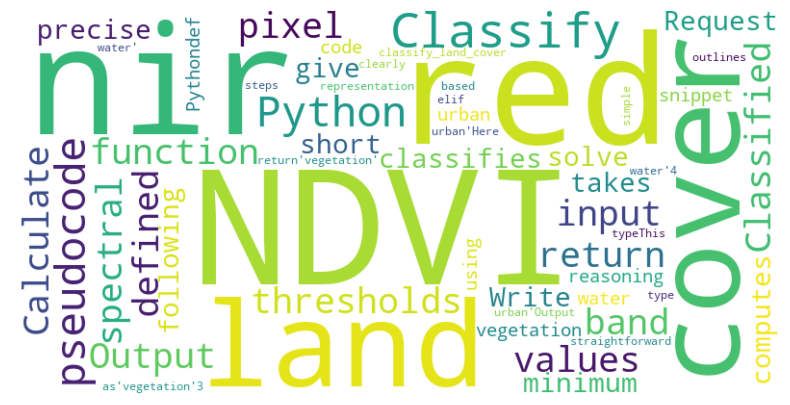

In [40]:
suggested_approach_q_3 = sample_data[sample_data['reasoning_approach'] == 'sections']['plan'].values[0]['reasoning_snippet']
suggested_approach_q_3 = suggested_approach_q_3.replace("```python", "").replace("```", "").replace("\n", "").replace("#", "").strip()
replace_text = f"Can you give a short and precise pseudocode on how to solve the following: Request: {question}.. Output only the reasoning snippet. Solution:"
suggested_approach_q_3 = suggested_approach_q_3.replace(replace_text, "").strip()
suggested_approach_q_3
plot_word_cloud(suggested_approach_q_3)

##### Question 4

In [38]:
question = "Given a Sentinel-2 GeoTIFF file, write  a Python code to compute NDVI for every pixel and classify each pixel as ‘urban’ if NDVI < 0.2, ‘vegetation’ if NDVI > 0.3, and ‘transition’ otherwise."
sample_data = all_data_df[all_data_df['question'] == question]
sample_data = sample_data[(sample_data['coder'] == 'meta-llama/Meta-Llama-3-8B-instruct') & (sample_data['reasoner'] == 'meta-llama/Meta-Llama-3-8B-instruct')]
sample_data = sample_data[sample_data['ranker'] == 'meta-llama/Meta-Llama-3-8B-instruct']
for _, row in sample_data.iterrows():
    print(f"Question: {row['question']}")
    print(f"Reasoning Type: {row['reasoning_type']}")
    print(f"Reasoner: {row['reasoner']}")
    print(f"Reasoning Approach: {row['reasoning_approach']}")
    print(f"Coder: {row['coder']}")
    print(f"Plan:\n{row['plan']}")
    print(f"Code:\n{row['code']}")
    print("-" * 100)

Question: Given a Sentinel-2 GeoTIFF file, write  a Python code to compute NDVI for every pixel and classify each pixel as ‘urban’ if NDVI < 0.2, ‘vegetation’ if NDVI > 0.3, and ‘transition’ otherwise.
Reasoning Type: automated
Reasoner: meta-llama/Meta-Llama-3-8B-instruct
Reasoning Approach: doc
Coder: meta-llama/Meta-Llama-3-8B-instruct
Plan:

                Act as an expert Python programmer and logical driven code reasoner. Your task is to generate a code reasoning snippet in a detailed breakdown.

                User Request: Given a Sentinel-2 GeoTIFF file, write  a Python code to compute NDVI for every pixel and classify each pixel as ‘urban’ if NDVI < 0.2, ‘vegetation’ if NDVI > 0.3, and ‘transition’ otherwise.

                Please provide your response in the following structured in a markdown format:

                The documentation should include the following sections:
                1. Problem Description: How to approach the problem and what the main challenges ar

In [ ]:
### 5 iterations
question = "Given a Sentinel-2 GeoTIFF file, write  a Python code to compute NDVI for every pixel and classify each pixel as ‘urban’ if NDVI < 0.2, ‘vegetation’ if NDVI > 0.3, and ‘transition’ otherwise."
code_automated_doc= '''
import rasterio
import numpy as np

with rasterio.open('sentinel2.tif') as src:
    nir = src.read(1)
    red = src.read(3)
    ndvi = (nir - red) / (nir + red)
    ndvi[ndvi < 0.2] = 'urban'
    ndvi[ndvi > 0.3] ='vegetation'
    ndvi[(ndvi >= 0.2) & (ndvi <= 0.3)] = 'transition'

print(ndvi)
'''

code_automated_sections = '''
import rasterio
import numpy as np
from scipy import stats

# Open the Sentinel-2 GeoTIFF file
with rasterio.open('sentinel2.tif') as src:
    # Read the raster bands
    band1 = src.read(1)
    band2 = src.read(2)

    # Compute NDVI
    ndvi = (band2 - band1) / (band2 + band1)

    # Classify pixels based on NDVI values
    urban = np.where(ndvi < 0.2, 1, 0)
    vegetation = np.where(ndvi > 0.3, 1, 0)
    transition = np.where((ndvi >= 0.2) & (ndvi <= 0.3), 1, 0)

    # Save the classified NDVI values to a new GeoTIFF file
    with rasterio.open('classified_ndvi.tif', 'w', **src.meta) as dst:
        dst.write(urban.astype(rasterio.uint8), 1)
        dst.write(vegetation.astype(rasterio.uint8), 2)
        dst.write(transition.astype(rasterio.uint8), 3)
'''

code_manual_doc = '''
import rasterio
import numpy as np

def compute_ndvi(sentinel2_file):
    with rasterio.open(sentinel2_file) as src:
        red_band = src.read(3)
        nir_band = src.read(7)
        
        ndvi = np.where(nir_band + red_band == 0, 0, (nir_band - red_band) / (nir_band + red_band))
        
        urban = ndvi < 0.2
        vegetation = ndvi > 0.3
        transition = ~urban & ~vegetation
        
        return urban, vegetation, transition

# Example usage:
sentinel2_file = 'path/to/sentinel2_file.tif'
urban, vegetation, transition = compute_ndvi(sentinel2_file)
'''

code_no_reasoning = '''
import rasterio
import numpy as np

def compute_ndvi(tif_file):
    with rasterio.open(tif_file) as src:
        ndvi = (src.read(4) - src.read(3)) / (src.read(4) + src.read(3))
        return ndvi

def classify_ndvi(ndvi):
    classified = np.where(ndvi < 0.2, 'urban', np.where(ndvi > 0.3,'vegetation', 'transition'))
    return classified

tif_file = 'path_to_your_sentinel2_tif_file.tif'
ndvi = compute_ndvi(tif_file)
classified = classify_ndvi(ndvi)
'''

##### Question 5

In [36]:
question = "Write Python code to compute NDVI from a GeoTIFF file with Red and NIR bands, and classify each pixel into ‘vegetation’, ‘urban’, or ‘transition’ using thresholds of 0.3 and 0.2. Save the output as a new classified raster file."
sample_data = all_data_df[all_data_df['question'] == question]
sample_data = sample_data[(sample_data['coder'] == 'meta-llama/Meta-Llama-3-8B-instruct') & (sample_data['reasoner'] == 'meta-llama/Meta-Llama-3-8B-instruct')]
sample_data = sample_data[sample_data['ranker'] == 'meta-llama/Meta-Llama-3-8B-instruct']
print(sample_data.shape)
for _, row in sample_data.iterrows():
    print(f"Question: {row['question']}")
    print(f"Reasoning Type: {row['reasoning_type']}")
    print(f"Reasoner: {row['reasoner']}")
    print(f"Reasoning Approach: {row['reasoning_approach']}")
    print(f"Coder: {row['coder']}")
    print(f"Ranker : {row['ranker']}")
    print(f"Plan:\n{row['plan']}")
    print(f"Code:\n{row['code']}")
    print("-" * 100)
    

(4, 8)
Question: Write Python code to compute NDVI from a GeoTIFF file with Red and NIR bands, and classify each pixel into ‘vegetation’, ‘urban’, or ‘transition’ using thresholds of 0.3 and 0.2. Save the output as a new classified raster file.
Reasoning Type: automated
Reasoner: meta-llama/Meta-Llama-3-8B-instruct
Reasoning Approach: doc
Coder: meta-llama/Meta-Llama-3-8B-instruct
Ranker : meta-llama/Meta-Llama-3-8B-instruct
Plan:

                Act as an expert Python programmer and logical driven code reasoner. Your task is to generate a code reasoning snippet in a detailed breakdown.

                User Request: Write Python code to compute NDVI from a GeoTIFF file with Red and NIR bands, and classify each pixel into ‘vegetation’, ‘urban’, or ‘transition’ using thresholds of 0.3 and 0.2. Save the output as a new classified raster file.

                Please provide your response in the following structured in a markdown format:

                The documentation should include

In [37]:
question = "Write Python code to compute NDVI from a GeoTIFF file with Red and NIR bands, and classify each pixel into ‘vegetation’, ‘urban’, or ‘transition’ using thresholds of 0.3 and 0.2. Save the output as a new classified raster file."
code_automated_doc= '''
import rasterio
import numpy as np
from osgeo import gdal

# Open the GeoTIFF file
with rasterio.open('input.tif') as src:
    red_band = src.read(1)
    nir_band = src.read(2)

# Compute NDVI
ndvi = (nir_band - red_band) / (nir_band + red_band)

# Classify pixels
classified = np.where(ndvi > 0.3,'vegetation', np.where(ndvi < 0.2, 'urban', 'transition'))

# Save the classified raster file
with rasterio.open('output.tif', 'w', driver='GTiff', height=src.height, width=src.width, count=1, dtype=rasterio.uint8) as dst:
    dst.write(classified.astype(np.uint8), 1)
'''

code_automated_sections = '''
import rasterio
import numpy as np

with rasterio.open('input.tif') as src:
    red_band = src.read(1)
    nir_band = src.read(2)

    ndvi = (nir_band - red_band) / (nir_band + red_band)

    vegetation_mask = ndvi > 0.3
    urban_mask = ndvi < 0.2
    transition_mask = np.logical_and(ndvi >= 0.2, ndvi <= 0.3)

with rasterio.open('output.tif', 'w', driver='GTiff', height=src.height, width=src.width, count=1, dtype=rasterio.uint8) as dst:
    dst.write(vegetation_mask.astype(np.uint8), 1)
    dst.write(urban_mask.astype(np.uint8), 1)
    dst.write(transition_mask.astype(np.uint8), 1)
'''

code_manual_doc = '''
import rasterio
import numpy as np

def compute_ndvi(red_band, nir_band):
    ndvi = (nir_band - red_band) / (nir_band + red_band + 1e-8)
    return ndvi

def classify_ndvi(ndvi):
    classified = np.where(ndvi >= 0.3, 1, np.where(ndvi < 0.2, 2, 0))
    return classified

def main():
    with rasterio.open('input.tif') as src:
        red_band = src.read(3)
        nir_band = src.read(7)
        ndvi = compute_ndvi(red_band, nir_band)
        classified = classify_ndvi(ndvi)
    
    with rasterio.open('output.tif', 'w', **src.meta) as dst:
        dst.write(classified.astype(rasterio.uint8), 1)

if __name__ == '__main__':
    main()
'''

code_no_reasoning = '''
import rasterio
import numpy as np
from scipy import ndimage

# Open the GeoTIFF file
with rasterio.open('input.tif') as src:
    red_band = src.read(1)
    nir_band = src.read(2)

# Compute NDVI
ndvi = (nir_band - red_band) / (nir_band + red_band)

# Classify pixels into'vegetation', 'urban', or 'transition'
classified = np.where(ndvi > 0.3,'vegetation', np.where(ndvi > 0.2, 'urban', 'transition'))

# Save the output as a new classified raster file
with rasterio.open('output.tif', 'w', driver='GTiff', height=src.height, width=src.width, count=1, dtype=rasterio.uint8) as dst:
    dst.write(classified.astype(np.uint8), 1)
'''

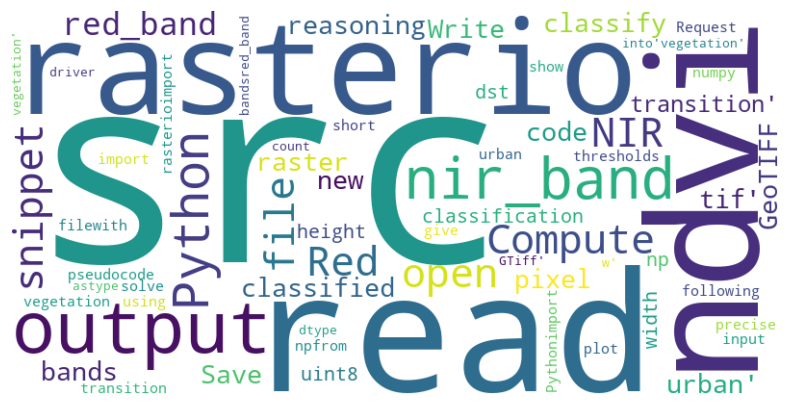

In [38]:
suggested_approach_q_5 = sample_data[sample_data['reasoning_approach'] == 'sections']['plan'].values[0]['reasoning_snippet']
suggested_approach_q_5 = suggested_approach_q_5.replace("```python", "").replace("```", "").replace("\n", "").replace("#", "").strip()
replace_text = f"Can you give a short and precise pseudocode on how to solve the following: Request: {question}.. Output only the reasoning snippet. Solution:"
suggested_approach_q_5 = suggested_approach_q_5.replace(replace_text, "").strip()
suggested_approach_q_5
plot_word_cloud(suggested_approach_q_5)

##### Question 6

In [31]:
question = "Given an Excel sheet with columns for Red and NIR reflectance values, write Python code to compute NDVI for each row and assign a land cover category (‘vegetation’, ‘urban’, or ‘transition’) based on NDVI thresholds."
sample_data = all_data_df[all_data_df['question'] == question]
sample_data = sample_data[(sample_data['coder'] == 'meta-llama/Meta-Llama-3-8B-instruct') & (sample_data['reasoner'] == 'meta-llama/Meta-Llama-3-8B-instruct')]
sample_data = sample_data[sample_data['ranker'] == 'meta-llama/Meta-Llama-3-8B-instruct']
print(sample_data.shape)
for _, row in sample_data.iterrows():
    print(f"Question: {row['question']}")
    print(f"Reasoning Type: {row['reasoning_type']}")
    print(f"Reasoner: {row['reasoner']}")
    print(f"Reasoning Approach: {row['reasoning_approach']}")
    print(f"Coder: {row['coder']}")
    print(f"Plan:\n{row['plan']}")
    print(f"Code:\n{row['code']}")
    print("-" * 100)

(4, 8)
Question: Given an Excel sheet with columns for Red and NIR reflectance values, write Python code to compute NDVI for each row and assign a land cover category (‘vegetation’, ‘urban’, or ‘transition’) based on NDVI thresholds.
Reasoning Type: automated
Reasoner: meta-llama/Meta-Llama-3-8B-instruct
Reasoning Approach: doc
Coder: meta-llama/Meta-Llama-3-8B-instruct
Plan:

                Act as an expert Python programmer and logical driven code reasoner. Your task is to generate a code reasoning snippet in a detailed breakdown.

                User Request: Given an Excel sheet with columns for Red and NIR reflectance values, write Python code to compute NDVI for each row and assign a land cover category (‘vegetation’, ‘urban’, or ‘transition’) based on NDVI thresholds.

                Please provide your response in the following structured in a markdown format:

                The documentation should include the following sections:
                1. Problem Description: Ho

In [33]:
question = "Given an Excel sheet with columns for Red and NIR reflectance values, write Python code to compute NDVI for each row and assign a land cover category (‘vegetation’, ‘urban’, or ‘transition’) based on NDVI thresholds."
code_automated_doc= '''
import pandas as pd
from openpyxl import load_workbook

# Load the Excel file
wb = load_workbook(filename='input.xlsx')
sheet = wb.active

# Convert the Excel sheet to a Pandas DataFrame
df = pd.DataFrame(sheet.values)

# Compute NDVI values
df['NDVI'] = (df['NIR'] - df['Red']) / (df['NIR'] + df['Red'])

# Assign land cover categories
df['Land Cover'] = df['NDVI'].apply(lambda x:'vegetation' if x > 0.5 else ('urban' if x < -0.5 else 'transition'))

# Save the output to a new Excel file
df.to_excel('output.xlsx', index=False)
'''

code_automated_sections = '''
import pandas as pd
import numpy as np
from openpyxl import load_workbook

# Load the Excel file
wb = load_workbook(filename='your_file.xlsx')
sheet = wb.active

# Convert the Excel sheet to a Pandas DataFrame
df = pd.DataFrame(sheet.values)

# Compute NDVI
df['NDVI'] = (df['NIR'] - df['Red']) / (df['NIR'] + df['Red'])

# Assign land cover categories based on NDVI thresholds
df['Land Cover'] = np.where(df['NDVI'] > 0.5,'vegetation', np.where(df['NDVI'] < -0.5, 'urban', 'transition'))

# Print the resulting DataFrame
print(df)
'''

code_manual_doc = '''
import pandas as pd
import numpy as np

def compute_ndvi(df):
    ndvi = (df['NIR'] - df['Red']) / (df['NIR'] + df['Red'] + 1e-8)
    return ndvi

def classify_land_cover(ndvi):
    land_cover = []
    for value in ndvi:
        if value >= 0.3:
            land_cover.append('vegetation')
        elif value < 0.3:
            land_cover.append('urban')
        else:
            land_cover.append('transition')
    return land_cover

def main():
    df = pd.read_excel('input.xlsx')
    ndvi = compute_ndvi(df)
    land_cover = classify_land_cover(ndvi)
    df['NDVI'] = ndvi
    df['Land Cover'] = land_cover
    df.to_excel('output.xlsx', index=False)

if __name__ == "__main__":
    main()
'''

code_no_reasoning = '''
import pandas as pd
import numpy as np

def compute_ndvi(df):
    df['NDVI'] = (df['Red'] - df['NIR']) / (df['Red'] + df['NIR'])
    return df

def classify_land_cover(df):
    df['Land Cover'] = np.where(df['NDVI'] > 0.5,'vegetation', np.where(df['NDVI'] < -0.5, 'urban', 'transition'))
    return df

def main():
    df = pd.read_excel('input.xlsx')
    df = compute_ndvi(df)
    df = classify_land_cover(df)
    df.to_excel('output.xlsx', index=False)

if __name__ == "__main__":
    main()
'''

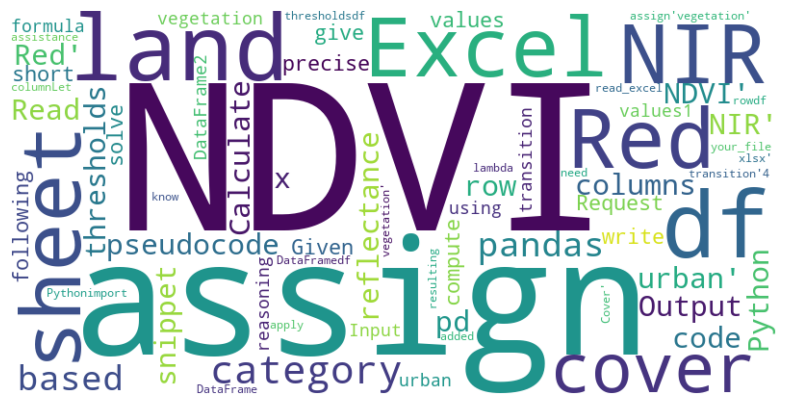

In [35]:
suggested_approach_q_6 = sample_data[sample_data['reasoning_approach'] == 'sections']['plan'].values[0]['reasoning_snippet']
suggested_approach_q_6 = suggested_approach_q_6.replace("```python", "").replace("```", "").replace("\n", "").replace("#", "").strip()
replace_text = f"Can you give a short and precise pseudocode on how to solve the following: Request: {question}.. Output only the reasoning snippet. Solution:"
suggested_approach_q_6 = suggested_approach_q_6.replace(replace_text, "").strip()
suggested_approach_q_6
plot_word_cloud(suggested_approach_q_6)

##### Question 7

In [41]:
question = "Given a Sentinel-2 GeoTIFF image containing Red and NIR bands, write Python code to compute NDVI and classify the land cover into ‘vegetation’, ‘urban’, or ‘water’."
sample_data = all_data_df[(all_data_df['question'] == question)]
sample_data = sample_data[(sample_data['coder'] == 'meta-llama/Meta-Llama-3-8B-instruct') & (sample_data['reasoner'] == 'meta-llama/Meta-Llama-3-8B-instruct')]
sample_data = sample_data[sample_data['ranker'] == 'meta-llama/Meta-Llama-3-8B-instruct']
print(sample_data.shape)
for _, row in sample_data.iterrows():
    print(f"Question: {row['question']}")
    print(f"Reasoning Type: {row['reasoning_type']}")
    print(f"Reasoner: {row['reasoner']}")
    print(f"Reasoning Approach: {row['reasoning_approach']}")
    print(f"Coder: {row['coder']}")
    print(f"Ranker : {row['ranker']}")
    print(f"Plan:\n{row['plan']}")
    print(f"Code:\n{row['code']}")
    print("-" * 100)

(4, 8)
Question: Given a Sentinel-2 GeoTIFF image containing Red and NIR bands, write Python code to compute NDVI and classify the land cover into ‘vegetation’, ‘urban’, or ‘water’.
Reasoning Type: automated
Reasoner: meta-llama/Meta-Llama-3-8B-instruct
Reasoning Approach: doc
Coder: meta-llama/Meta-Llama-3-8B-instruct
Ranker : meta-llama/Meta-Llama-3-8B-instruct
Plan:

                Act as an expert Python programmer and logical driven code reasoner. Your task is to generate a code reasoning snippet in a detailed breakdown.

                User Request: Given a Sentinel-2 GeoTIFF image containing Red and NIR bands, write Python code to compute NDVI and classify the land cover into ‘vegetation’, ‘urban’, or ‘water’.

                Please provide your response in the following structured in a markdown format:

                The documentation should include the following sections:
                1. Problem Description: How to approach the problem and what the main challenges are.

In [42]:
question = "Given a Sentinel-2 GeoTIFF image containing Red and NIR bands, write Python code to compute NDVI and classify the land cover into ‘vegetation’, ‘urban’, or ‘water’."
code_automated_doc= '''
import rasterio
import numpy as np
from skimage import filters

# Open the Sentinel-2 GeoTIFF image
with rasterio.open('sentinel2_image.tif') as src:
    red_band = src.read(1)
    nir_band = src.read(2)

# Compute NDVI
ndvi = (nir_band - red_band) / (nir_band + red_band)

# Apply threshold to classify land cover
ndvi_classified = np.where(ndvi > 0.5,'vegetation',
                           np.where(ndvi < -0.1, 'water', 'urban'))

# Save the classified image
with rasterio.open('classified_image.tif', 'w', driver='GTiff',
                   height=src.height, width=src.width, count=1,
                   dtype=rasterio.uint8) as dst:
    dst.write(ndvi_classified.astype(np.uint8), 1)
'''

code_automated_sections = '''
import rasterio
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

with rasterio.open('sentinel2_image.tif') as src:
    img = src.read(4)  # Assuming Red band is at band 4
    nir_band = src.read(8)  # Assuming NIR band is at band 8

ndvi = (nir_band - img) / (nir_band + img)

threshold_vegetation = 0.3  # NDVI value for vegetation
threshold_urban = -0.1  # NDVI value for urban
threshold_water = -0.5  # NDVI value for water

land_cover = np.where(ndvi > threshold_vegetation,'vegetation', np.where(ndvi < threshold_water, 'water', 'urban'))

print(land_cover)
'''

code_manual_doc = '''
import rasterio
import numpy as np

def compute_ndvi(red_band, nir_band):
    ndvi = (nir_band - red_band) / (nir_band + red_band + 1e-8)
    return ndvi

def classify_land_cover(ndvi):
    land_cover = np.where(ndvi > 0.3,'vegetation', np.where(ndvi < 0, 'water', 'urban'))
    return land_cover

with rasterio.open('sentinel2_image.tif') as src:
    red_band = src.read(3)
    nir_band = src.read(7)
    ndvi = compute_ndvi(red_band, nir_band)
    land_cover = classify_land_cover(ndvi)
    print(land_cover)
'''

code_no_reasoning = '''
import rasterio
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

def compute_ndvi(red_band, nir_band):
    return (nir_band - red_band) / (nir_band + red_band)

def classify_land_cover(ndvi, threshold_vegetation=0.3, threshold_urban=-0.1, threshold_water=-0.5):
    if ndvi > threshold_vegetation:
        return'vegetation'
    elif ndvi < threshold_urban:
        return 'water'
    else:
        return 'urban'

def main():
    with rasterio.open('sentinel2_image.tif') as src:
        red_band = src.read(4)
        nir_band = src.read(5)
        
    ndvi = compute_ndvi(red_band, nir_band)
    land_cover = np.vectorize(classify_land_cover)(ndvi)
    
    print(land_cover)

if __name__ == "__main__":
    main()
'''

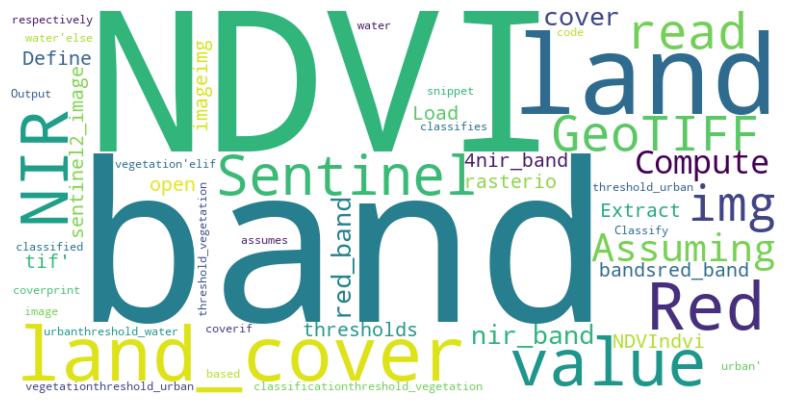

In [46]:
suggested_approach = sample_data[sample_data['reasoning_approach'] == 'sections']['plan'].values[0]['reasoning_snippet']
suggested_approach = suggested_approach.replace("```python", "").replace("```", "").replace("\n", "").replace("#", "").strip()
replace_text = "Can you give a short and precise pseudocode on how to solve the following: Request: Given a Sentinel-2 GeoTIFF image containing Red and NIR bands, write Python code to compute NDVI and classify the land cover into ‘vegetation’, ‘urban’, or ‘water’.. Output only the reasoning snippet. Solution:"
suggested_approach = suggested_approach.replace(replace_text, "").strip()
suggested_approach
plot_word_cloud(suggested_approach)

In [53]:
replace_text = "Act as an expert Python programmer and logical driven code reasoner. Your task is to generate a code reasoning snippet in a detailed breakdown.\n\n                User Request: Given a Sentinel-2 GeoTIFF image containing Red and NIR bands, write Python code to compute NDVI and classify the land cover into ‘vegetation’, ‘urban’, or ‘water’.\n\n                Please provide your response in the following structured in a markdown format:\n\n                The documentation should include the following sections:\n                1. Problem Description: How to approach the problem and what the main challenges are.\n                2. Domain-Specific Libraries : The field(s) or context (e.g., math, computer vision, NLP, remote sensing)\n                3. Algorithm Design / Pseudocode : Provide the pseudocode  implementation, of your reasoning, it need not be a full code\n                4. Implementation Considerations : Edge cases and other things that needs to be considered in the implementation\n                5. References (optional)\n\n                Ensure your reasoning is detailed and explains the 'why' behind your pseudocode decisions. Always ensure the reasoning snippet comes before pseudocode, and that the reasoning matches the pseudocode.\n                Output only the reasoning snippet."

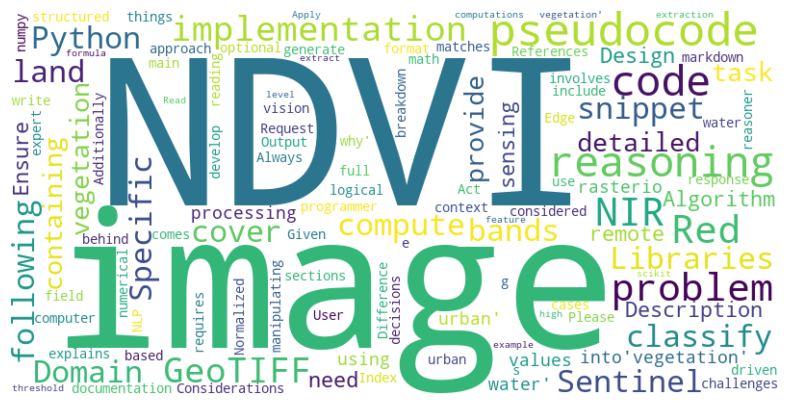

In [54]:
suggested_approach = sample_data[sample_data['reasoning_approach'] == 'doc']['plan'].values[0]
suggested_approach = suggested_approach.replace("```python", "").replace("```", "").replace("\n", "").replace("#", "").replace("/n", "").strip()
suggested_approach = suggested_approach.replace(replace_text, "").strip()
suggested_approach
plot_word_cloud(suggested_approach)

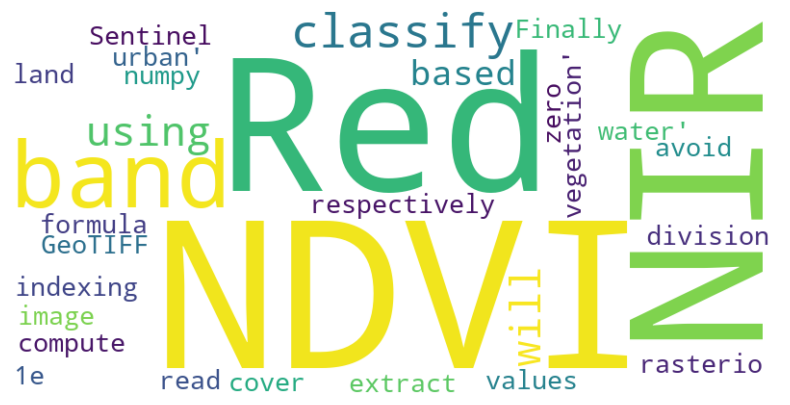

In [64]:
suggested_approach = sample_data[sample_data['reasoning_type'] == 'manual']['plan'].values[0]['reasoning_snippet'][0]
suggested_approach = suggested_approach.replace("```python", "").replace("```", "").replace("\n", "").replace("#", "").replace("/n", "").strip()
suggested_approach = suggested_approach.replace(replace_text, "").strip()
suggested_approach
plot_word_cloud(suggested_approach)

In [ ]:
suggested_approach = sample_data[sample_data['reasoning_type'] == 'no_reasoning']['plan'].values[0]['reasoning_snippet'][0]
suggested_approach = suggested_approach.replace("```python", "").replace("```", "").replace("\n", "").replace("#", "").replace("/n", "").strip()
suggested_approach = suggested_approach.replace(replace_text, "").strip()
suggested_approach
plot_word_cloud(suggested_approach)

IndexError: list index out of range

In [ ]:
import itertools
models_ls = ["microsoft/wavecoder-ultra-6.7b","meta-llama/Meta-Llama-3-8B-instruct", "Qwen2.5-Coder-3B"]
pairs = list(itertools.combinations_with_replacement(models_ls, 3))
len(pairs)

10

In [8]:
for pairs in pairs:
    print(pairs)
    print("*")

('microsoft/wavecoder-ultra-6.7b', 'microsoft/wavecoder-ultra-6.7b', 'microsoft/wavecoder-ultra-6.7b')
*
('microsoft/wavecoder-ultra-6.7b', 'microsoft/wavecoder-ultra-6.7b', 'meta-llama/Meta-Llama-3-8B-instruct')
*
('microsoft/wavecoder-ultra-6.7b', 'microsoft/wavecoder-ultra-6.7b', 'Qwen2.5-Coder-3B')
*
('microsoft/wavecoder-ultra-6.7b', 'meta-llama/Meta-Llama-3-8B-instruct', 'meta-llama/Meta-Llama-3-8B-instruct')
*
('microsoft/wavecoder-ultra-6.7b', 'meta-llama/Meta-Llama-3-8B-instruct', 'Qwen2.5-Coder-3B')
*
('microsoft/wavecoder-ultra-6.7b', 'Qwen2.5-Coder-3B', 'Qwen2.5-Coder-3B')
*
('meta-llama/Meta-Llama-3-8B-instruct', 'meta-llama/Meta-Llama-3-8B-instruct', 'meta-llama/Meta-Llama-3-8B-instruct')
*
('meta-llama/Meta-Llama-3-8B-instruct', 'meta-llama/Meta-Llama-3-8B-instruct', 'Qwen2.5-Coder-3B')
*
('meta-llama/Meta-Llama-3-8B-instruct', 'Qwen2.5-Coder-3B', 'Qwen2.5-Coder-3B')
*
('Qwen2.5-Coder-3B', 'Qwen2.5-Coder-3B', 'Qwen2.5-Coder-3B')
*


In [ ]:
part_1 = [['microsoft/wavecoder-ultra-6.7b', 'microsoft/wavecoder-ultra-6.7b', 'meta-llama/Meta-Llama-3-8B-instruct']] # 2714383

part_2 = [['microsoft/wavecoder-ultra-6.7b', 'microsoft/wavecoder-ultra-6.7b', 'Qwen/Qwen2.5-Coder-3B']]  # 2714384

part_3 = [['microsoft/wavecoder-ultra-6.7b', 'meta-llama/Meta-Llama-3-8B-instruct', 'Qwen/Qwen2.5-Coder-3B']] # 2714385

part_4 = [['meta-llama/Meta-Llama-3-8B-instruct', 'meta-llama/Meta-Llama-3-8B-instruct', 'meta-llama/Meta-Llama-3-8B-instruct']] # done 

part_5 = [['meta-llama/Meta-Llama-3-8B-instruct', 'Qwen/Qwen2.5-Coder-3B', 'Qwen/Qwen2.5-Coder-3B'],
          ['Qwen/Qwen2.5-Coder-3B', 'Qwen/Qwen2.5-Coder-3B', 'Qwen/Qwen2.5-Coder-3B']] #done

part_6 = [['meta-llama/Meta-Llama-3-8B-instruct', 'meta-llama/Meta-Llama-3-8B-instruct', 'Qwen/Qwen2.5-Coder-3B']]
part_7 = [['microsoft/wavecoder-ultra-6.7b', 'meta-llama/Meta-Llama-3-8B-instruct', 'meta-llama/Meta-Llama-3-8B-instruct']]
part_8 = [['microsoft/wavecoder-ultra-6.7b', 'Qwen/Qwen2.5-Coder-3B', 'Qwen/Qwen2.5-Coder-3B']]
part_9 = [['microsoft/wavecoder-ultra-6.7b', 'microsoft/wavecoder-ultra-6.7b', 'microsoft/wavecoder-ultra-6.7b']]

##### Analysis of Annotations

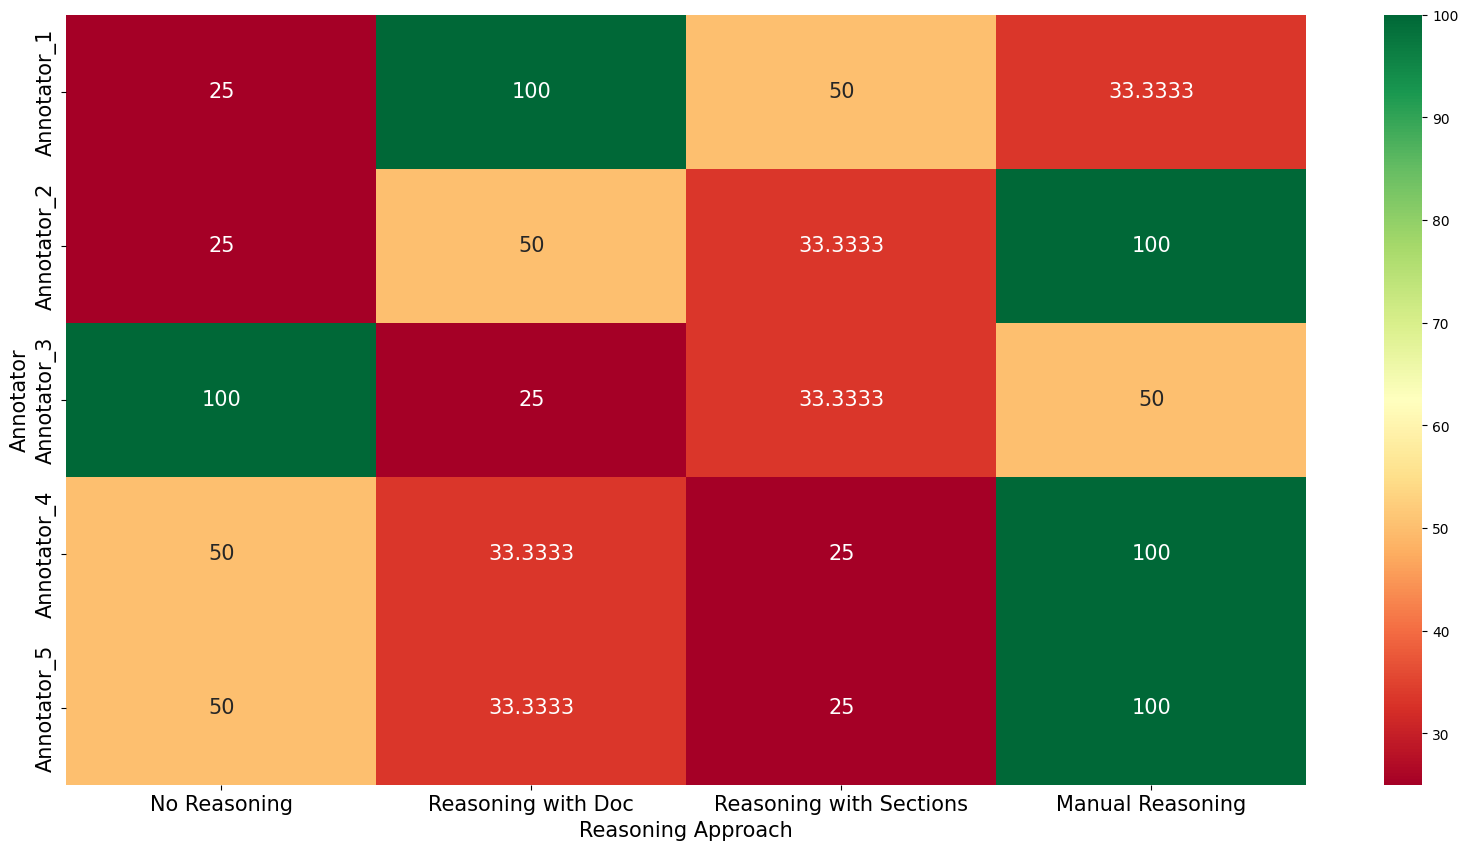

/var/folders/kd/vk8lq70d391f841cqpqv1cg40000gn/T/ipykernel_31467/625569618.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=summary_stats.index, y=summary_stats['median'].values, errorbar=None, palette='RdYlGn')


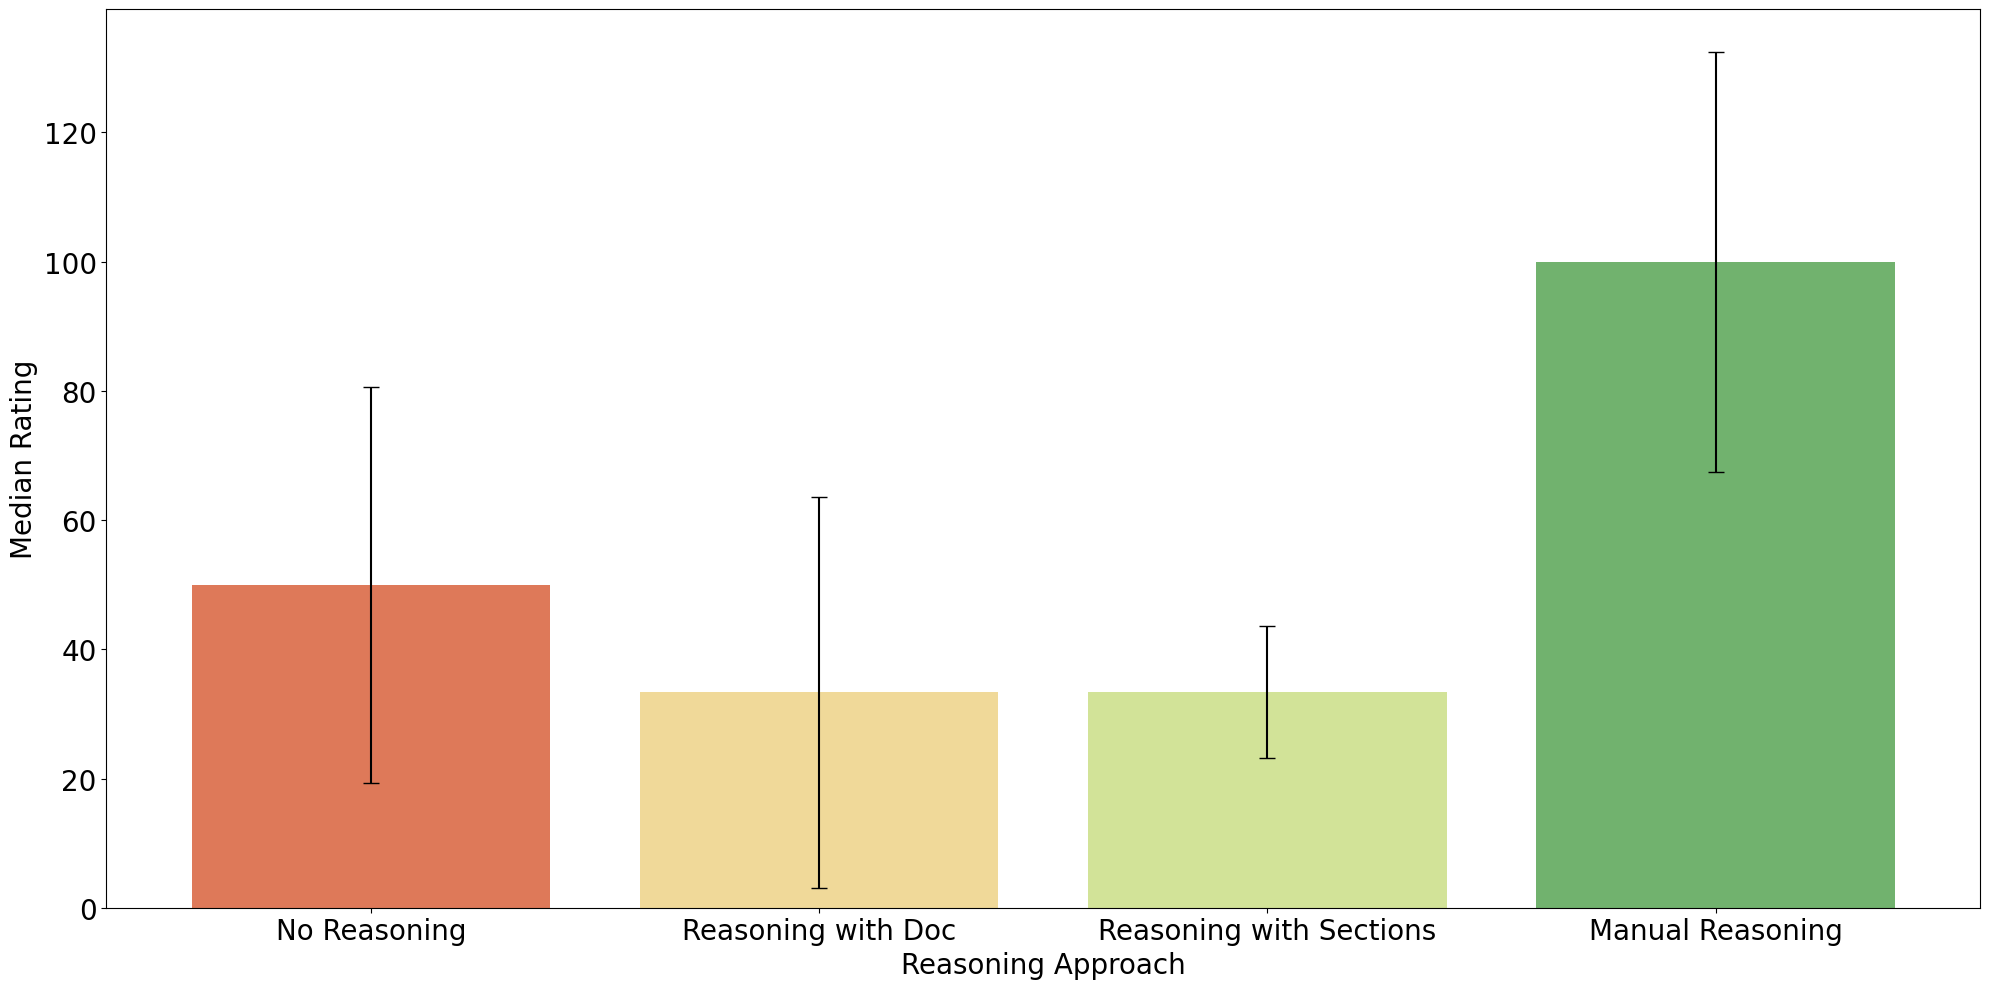

In [77]:
survey_data = pd.read_csv("/Users/theo/Documents/Projects/LLM_fo_Code_Gen/annotations/participants/3 Step (Order Rank) - Given an Excel sheet with columns for Red and NIR reflectance values, write Python code to compute NDVI for each row and assign a land cover category (‘vegetation’, ‘urban’, or ‘transition’) based on NDVI thresholds..csv", skiprows=1)
question = "Given an Excel sheet with columns for Red and NIR reflectance values, write Python code to compute NDVI for each row and assign a land cover category (‘vegetation’, ‘urban’, or ‘transition’) based on NDVI thresholds."
survey_data_1 = survey_data.reset_index()

def plot_results(input_survey_data, question):
    input_survey_data['Display Name'] = input_survey_data['Display Name'].str.replace('Participant ', 'Annotator_')
    input_survey_data['Display Name'] = input_survey_data['Display Name'].str.replace(r'Annotator_(\d+)', lambda m: f'Annotator_{int(m.group(1)) - 1}', regex=True)

    # Define the mapping for options to reasoning types
    option_mapping = {
        'option_1': 'Reasoning with Doc',
        'option_2': 'Reasoning with Sections',
        'option_3': 'Manual Reasoning',
        'option_4': 'No Reasoning'
    }

    # Replace Opinion column values using the mapping
    input_survey_data['Opinion'] = input_survey_data['Opinion'].map(option_mapping)

    input_survey_data.rename(columns={'Opinion': 'Reasoning Approach'}, inplace=True)
    # Pivot the dataframe to get annotators as rows and reasoning types as columns
    output_data = input_survey_data.pivot(index='Display Name', columns='Reasoning Approach', values='Rating')

    # Sort columns in the desired order
    column_order = ['No Reasoning', 'Reasoning with Doc', 'Reasoning with Sections', 'Manual Reasoning']
    output_data = output_data[column_order]
    plt.figure(figsize=(20, 10))
    sns.heatmap(output_data, cmap='RdYlGn', cbar=True, annot=True, fmt='g', annot_kws={'fontsize': 15})
    #plt.title(f'Rater Scores per Code Version \n {question}', fontsize=14)
    plt.xlabel('Reasoning Approach', fontsize=15)
    plt.ylabel('Annotator', fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.show()
    plt.close()

    plt.figure(figsize=(20, 10))
    summary_stats = input_survey_data.groupby('Reasoning Approach')['Rating'].agg(['median', 'std']).reindex(column_order)

    # fill NaN std (single sample) and drop approaches with no median
    summary_stats['std'] = summary_stats['std'].fillna(0)
    summary_stats = summary_stats.dropna(subset=['median'])

    # Create bar plot with error bars
    x_coords = np.arange(len(summary_stats))
    ax = sns.barplot(x=summary_stats.index, y=summary_stats['median'].values, errorbar=None, palette='RdYlGn')
    ax.errorbar(x_coords, summary_stats['median'].values, yerr=summary_stats['std'].values,
                fmt='none', ecolor='k', capsize=6, linewidth=1.5)

    #plt.title(f'Average Rater Scores with Std Dev \\n {question}', fontsize=14)
    plt.xlabel('Reasoning Approach', fontsize=20)
    plt.ylabel('Median Rating', fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.tight_layout()
    plt.show()

plot_results(survey_data_1.copy(), question)

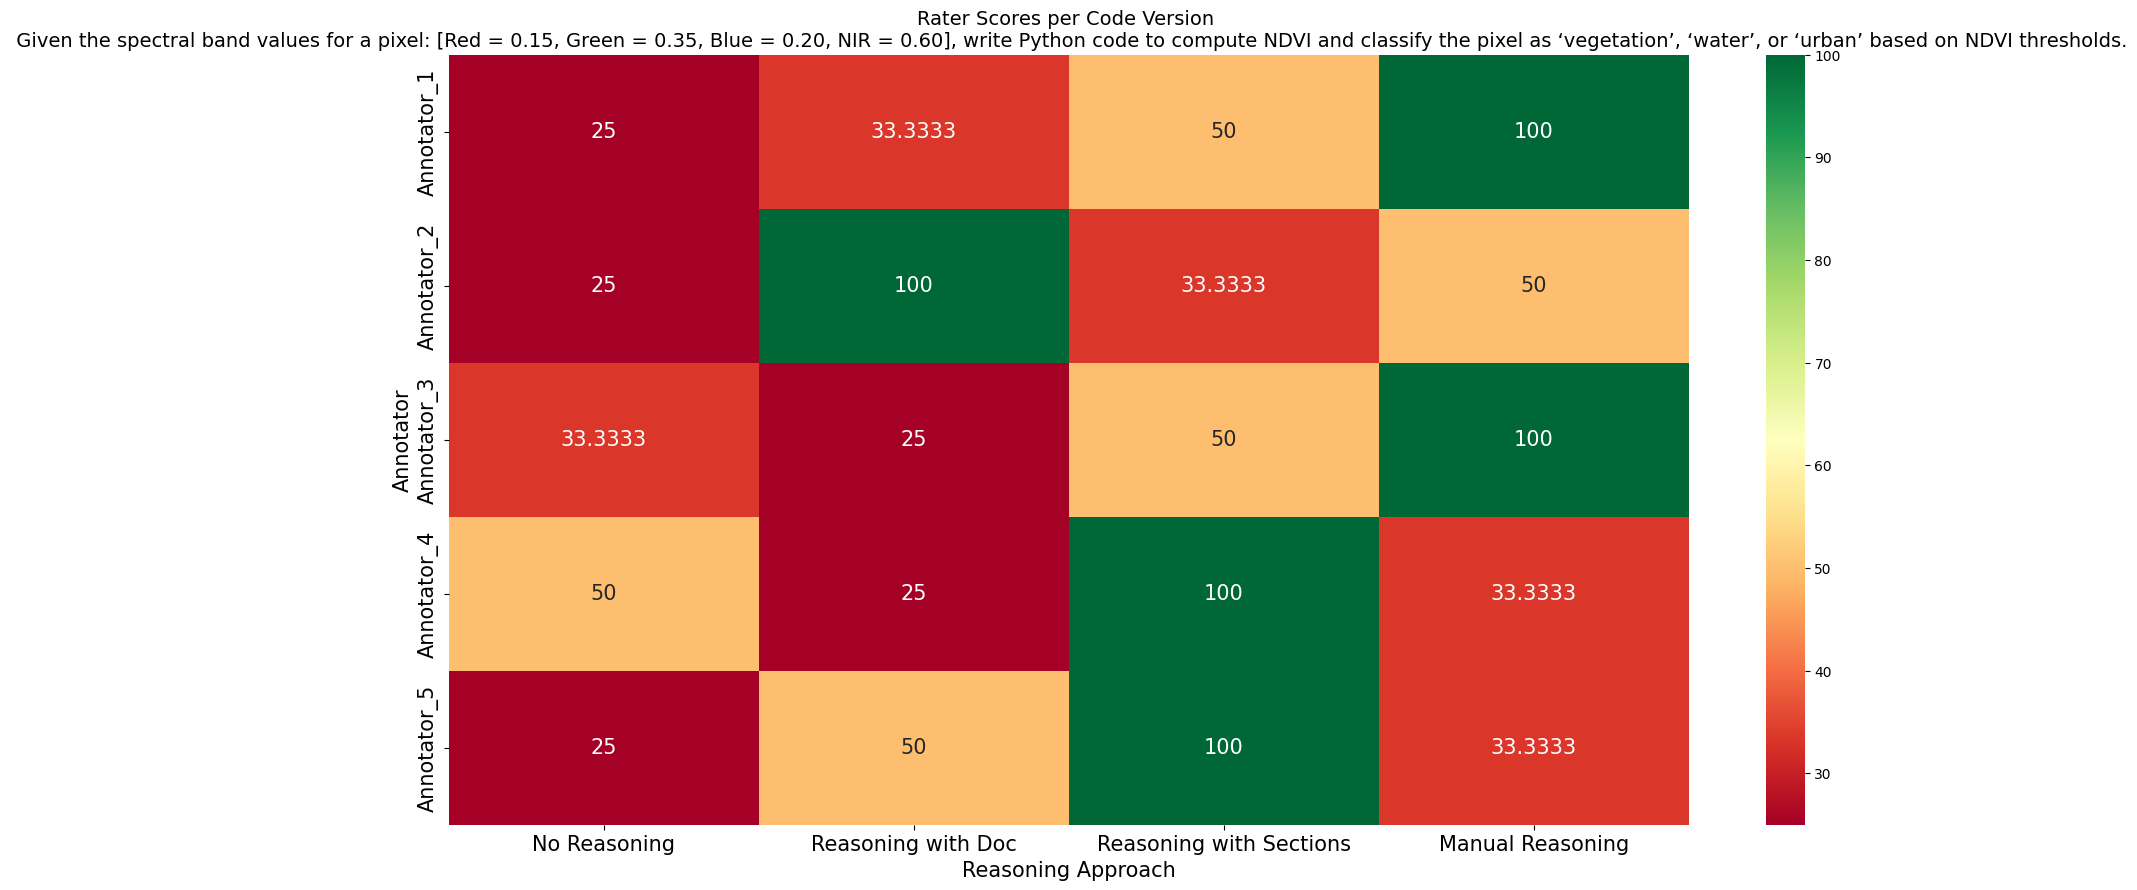

In [54]:
survey_data_3 = pd.read_csv("/Users/theo/Documents/Projects/LLM_fo_Code_Gen/annotations/participants/5 Step (Order Rank) - Given the spectral band values for a pixel [Red = 0.15, Green = 0.35, Blue = 0.20, NIR = 0.60], write Python code to compute NDVI and classify the pixel as ‘vegetation’, ‘water’, or ‘urban’ based on NDVI thresholds..csv", skiprows=1)
question = "Given the spectral band values for a pixel: [Red = 0.15, Green = 0.35, Blue = 0.20, NIR = 0.60], write Python code to compute NDVI and classify the pixel as ‘vegetation’, ‘water’, or ‘urban’ based on NDVI thresholds."
plot_results(survey_data_3.copy(), question)

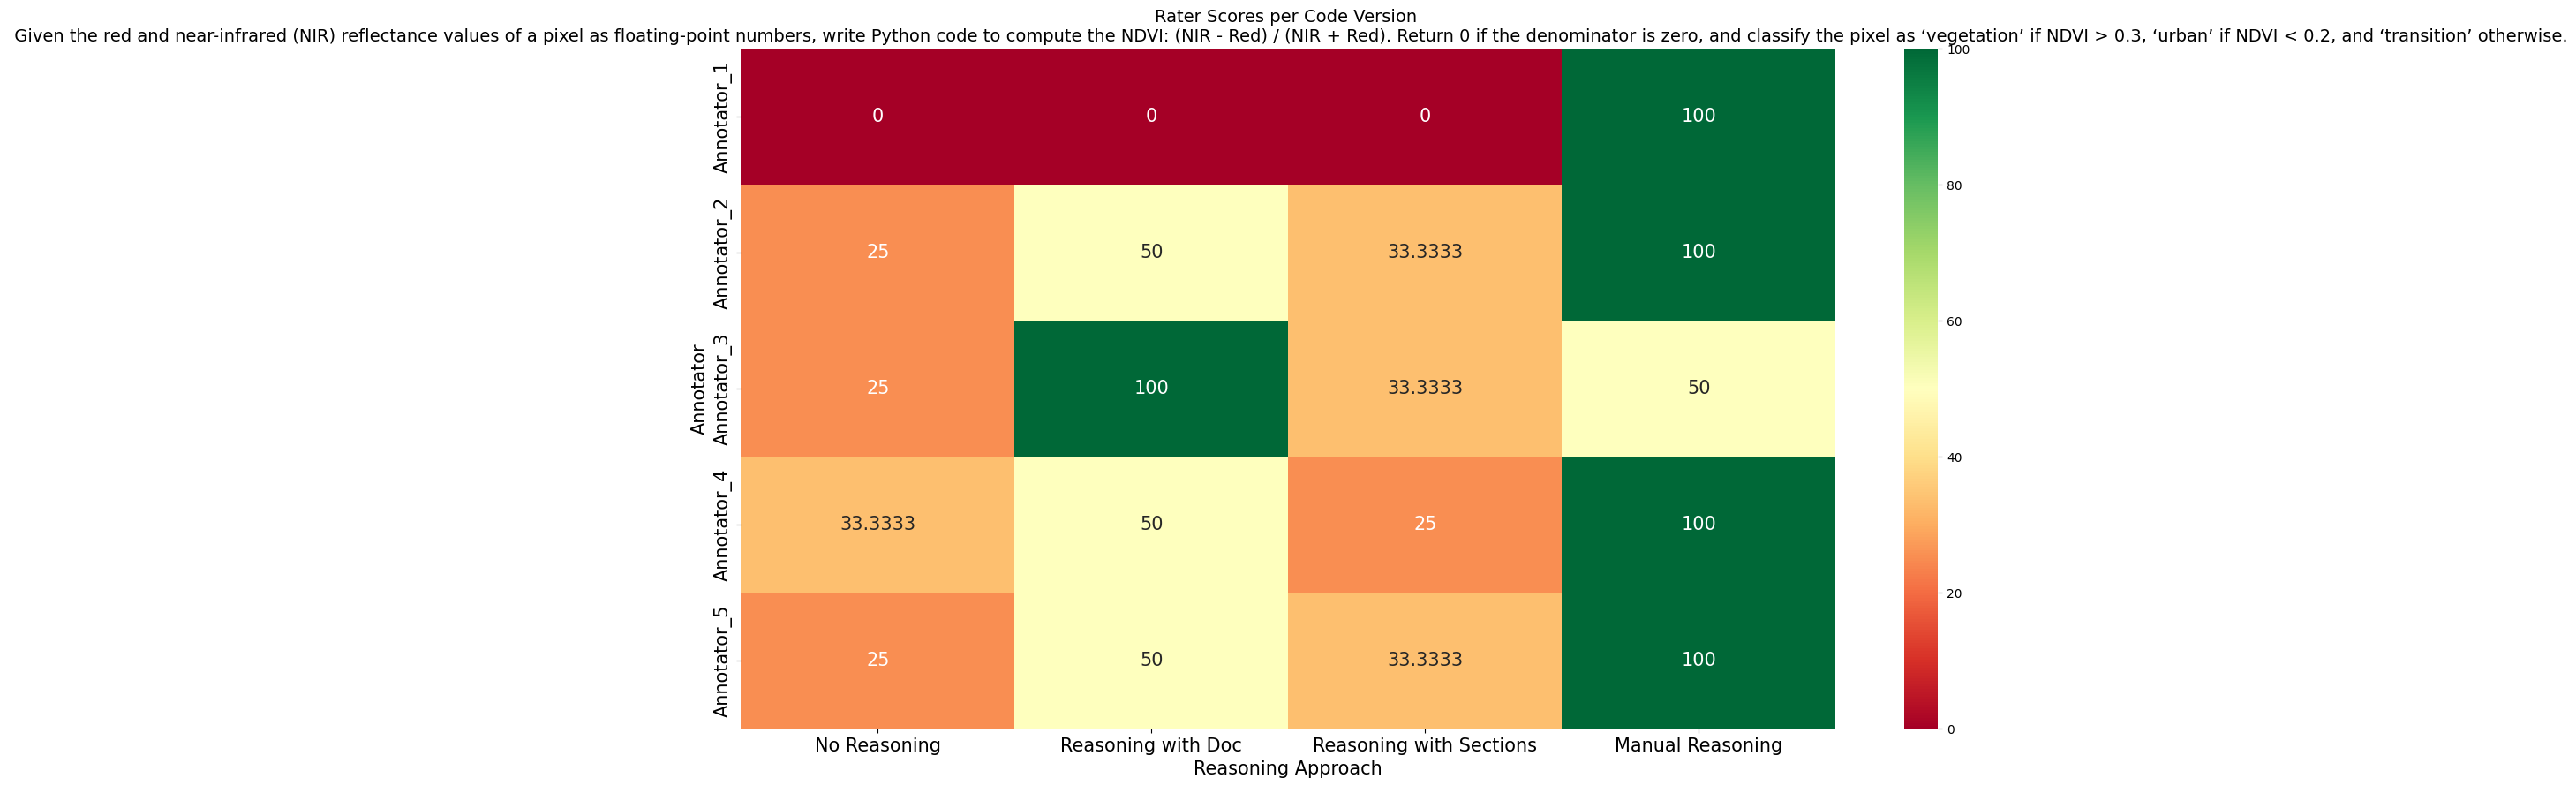

In [55]:
survey_data_4 = pd.read_csv("/Users/theo/Documents/Projects/LLM_fo_Code_Gen/annotations/participants/6 Step (Order Rank) - Given the red and near-infrared (NIR) reflectance values of a pixel as floating-point numbers, write Python code to compute the NDVI (NIR - Red)  (NIR + Red). Return 0 if the denominator is zero, and classify the pixel as.csv", skiprows=1)
question = "Given the red and near-infrared (NIR) reflectance values of a pixel as floating-point numbers, write Python code to compute the NDVI: (NIR - Red) / (NIR + Red). Return 0 if the denominator is zero, and classify the pixel as ‘vegetation’ if NDVI > 0.3, ‘urban’ if NDVI < 0.2, and ‘transition’ otherwise."
plot_results(survey_data_4.copy(), question)

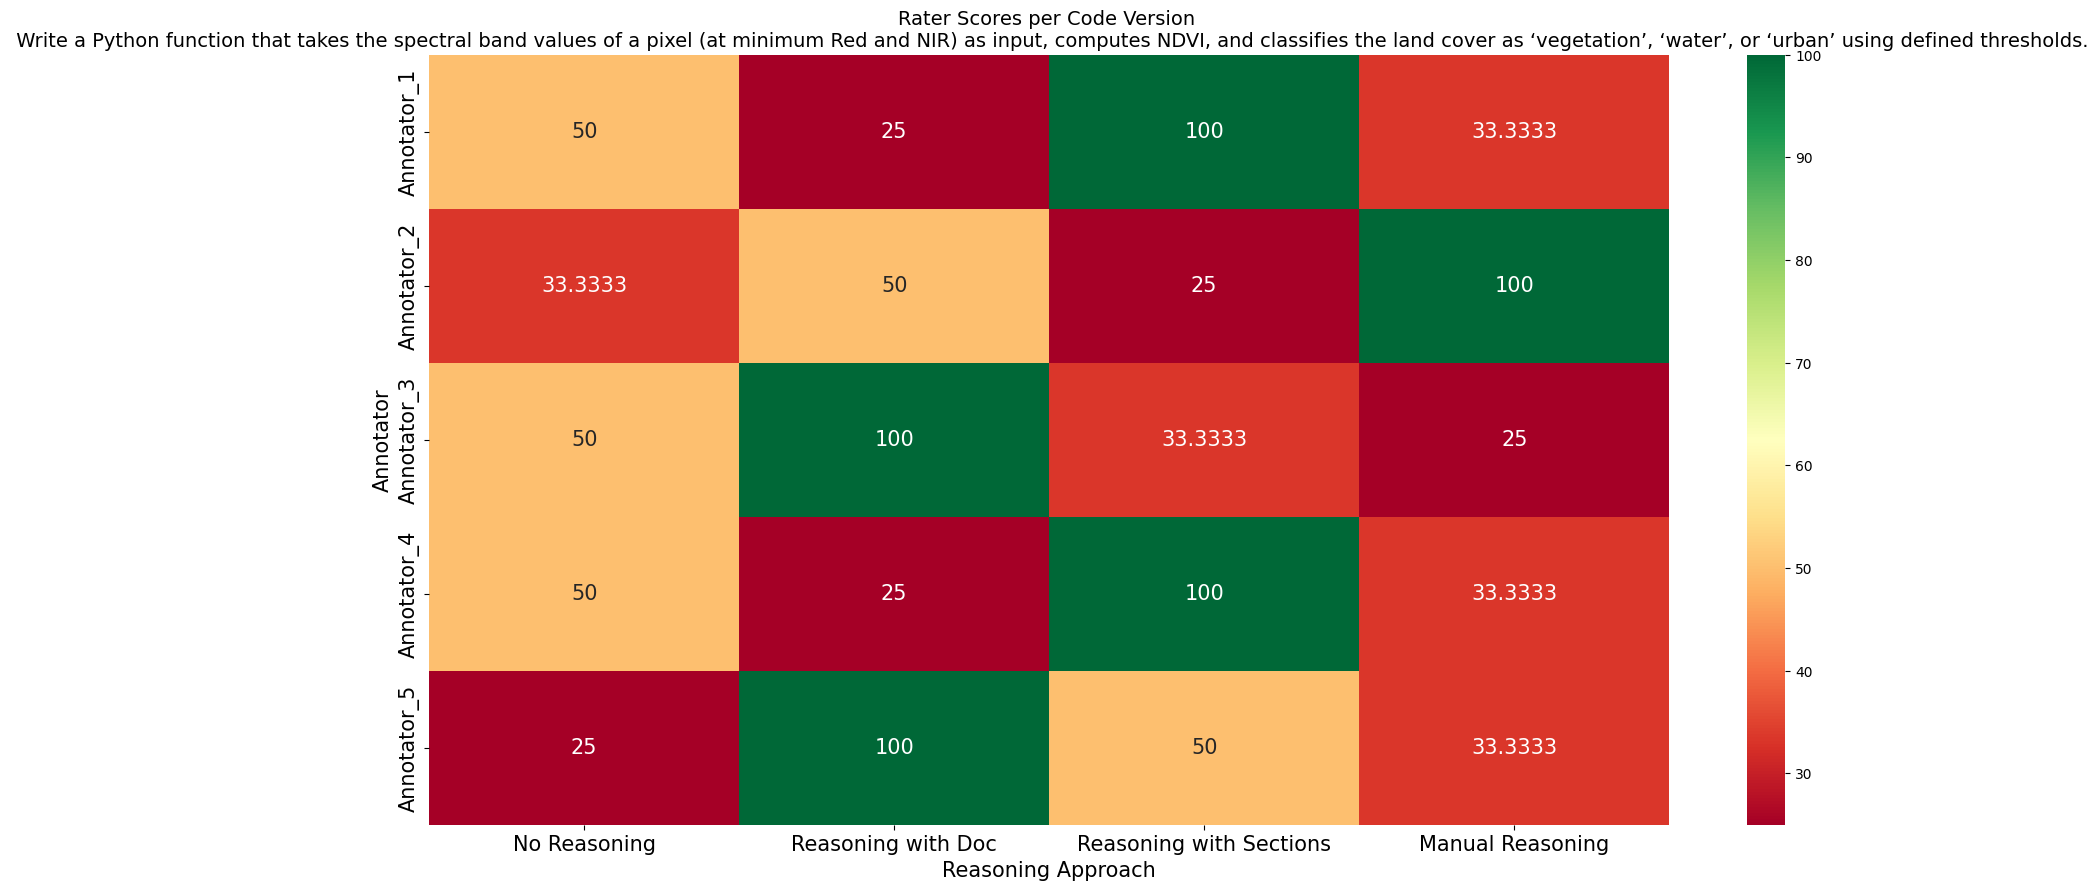

In [56]:
survey_data_6 = pd.read_csv("/Users/theo/Documents/Projects/LLM_fo_Code_Gen/annotations/participants/8 Step (Order Rank) - Write a Python function that takes the spectral band values of a pixel (at minimum Red and NIR) as input, computes NDVI, and classifies the land cover as ‘vegetation’, ‘water’, or ‘urban’ using defined thresholds.csv", skiprows=1)
question = "Write a Python function that takes the spectral band values of a pixel (at minimum Red and NIR) as input, computes NDVI, and classifies the land cover as ‘vegetation’, ‘water’, or ‘urban’ using defined thresholds."
plot_results(survey_data_6, question)

##### Domain Questions

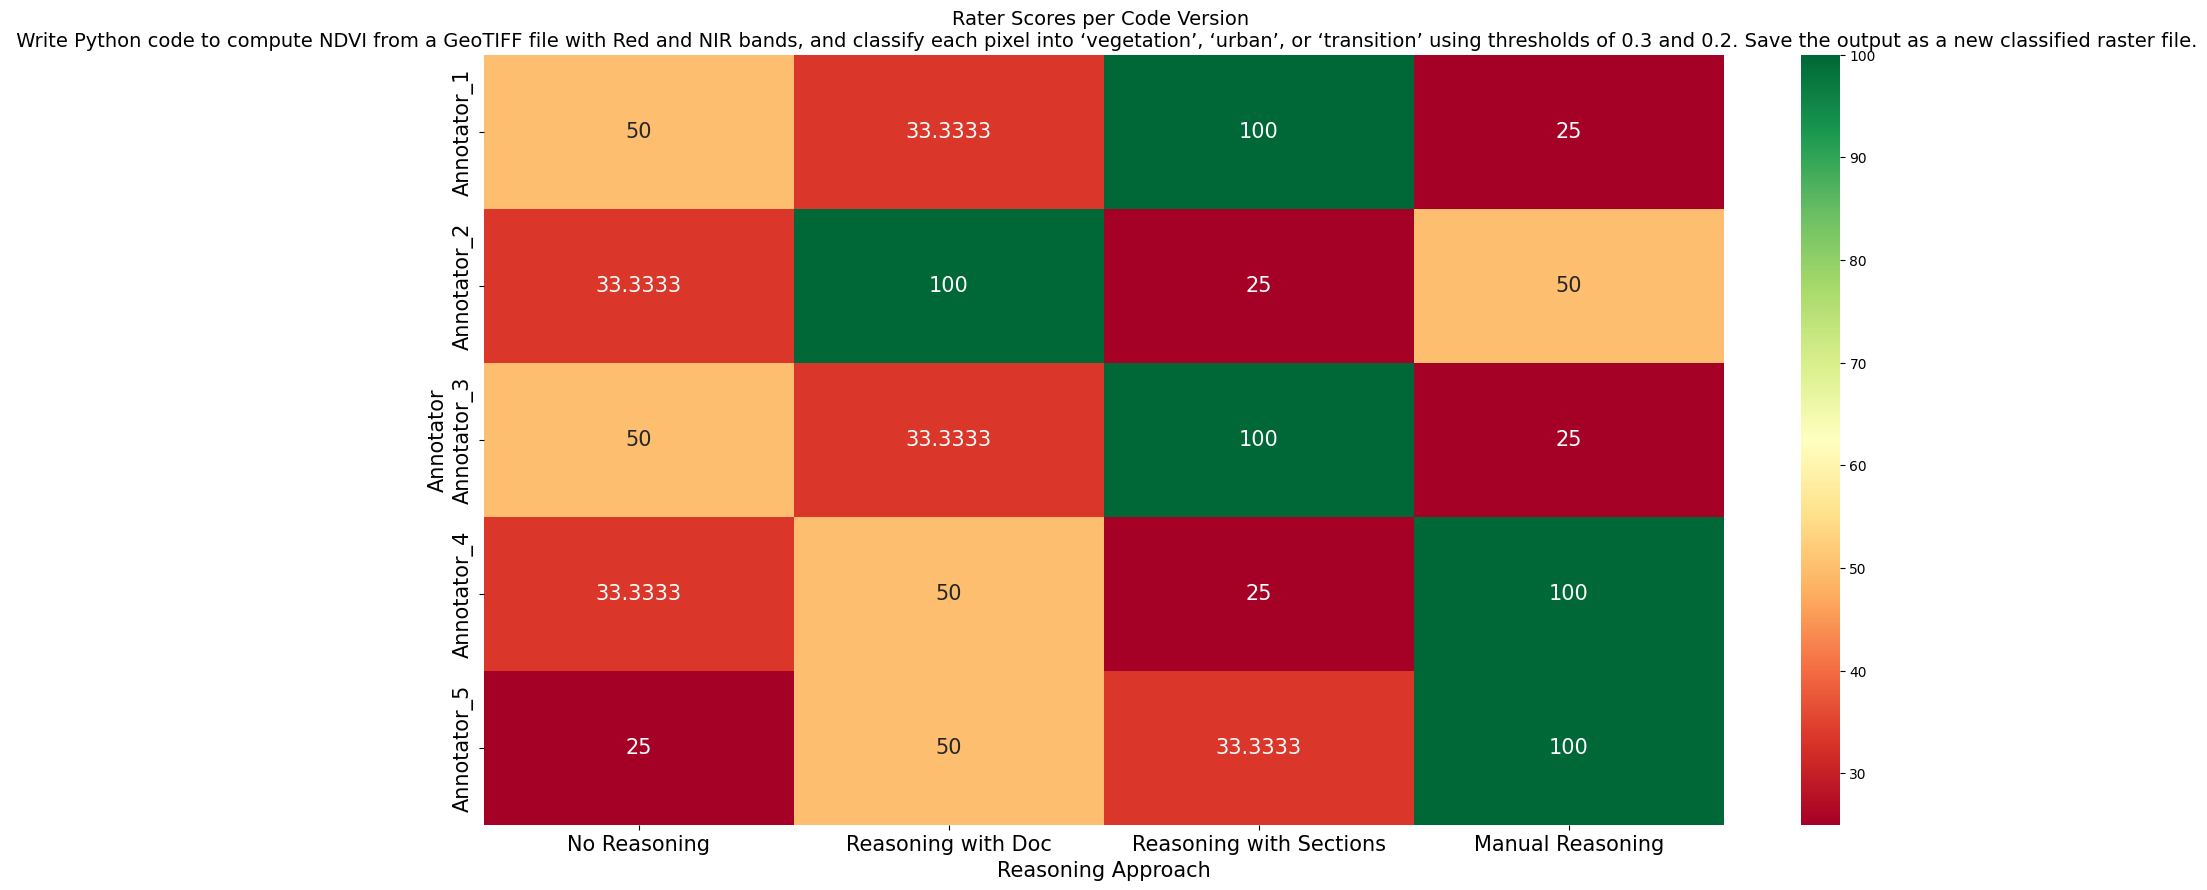

In [57]:
survey_data_2 = pd.read_csv("/Users/theo/Documents/Projects/LLM_fo_Code_Gen/annotations/participants/4 Step (Order Rank) - Write Python code to compute NDVI from a GeoTIFF file with Red and NIR bands, and classify each pixel into ‘vegetation’, ‘urban’, or ‘transition’ using thresholds of 0.3 and 0.2. Save the output as a new classified raster.csv", skiprows=1)
question = "Write Python code to compute NDVI from a GeoTIFF file with Red and NIR bands, and classify each pixel into ‘vegetation’, ‘urban’, or ‘transition’ using thresholds of 0.3 and 0.2. Save the output as a new classified raster file."
plot_results(survey_data_2.copy(), question)

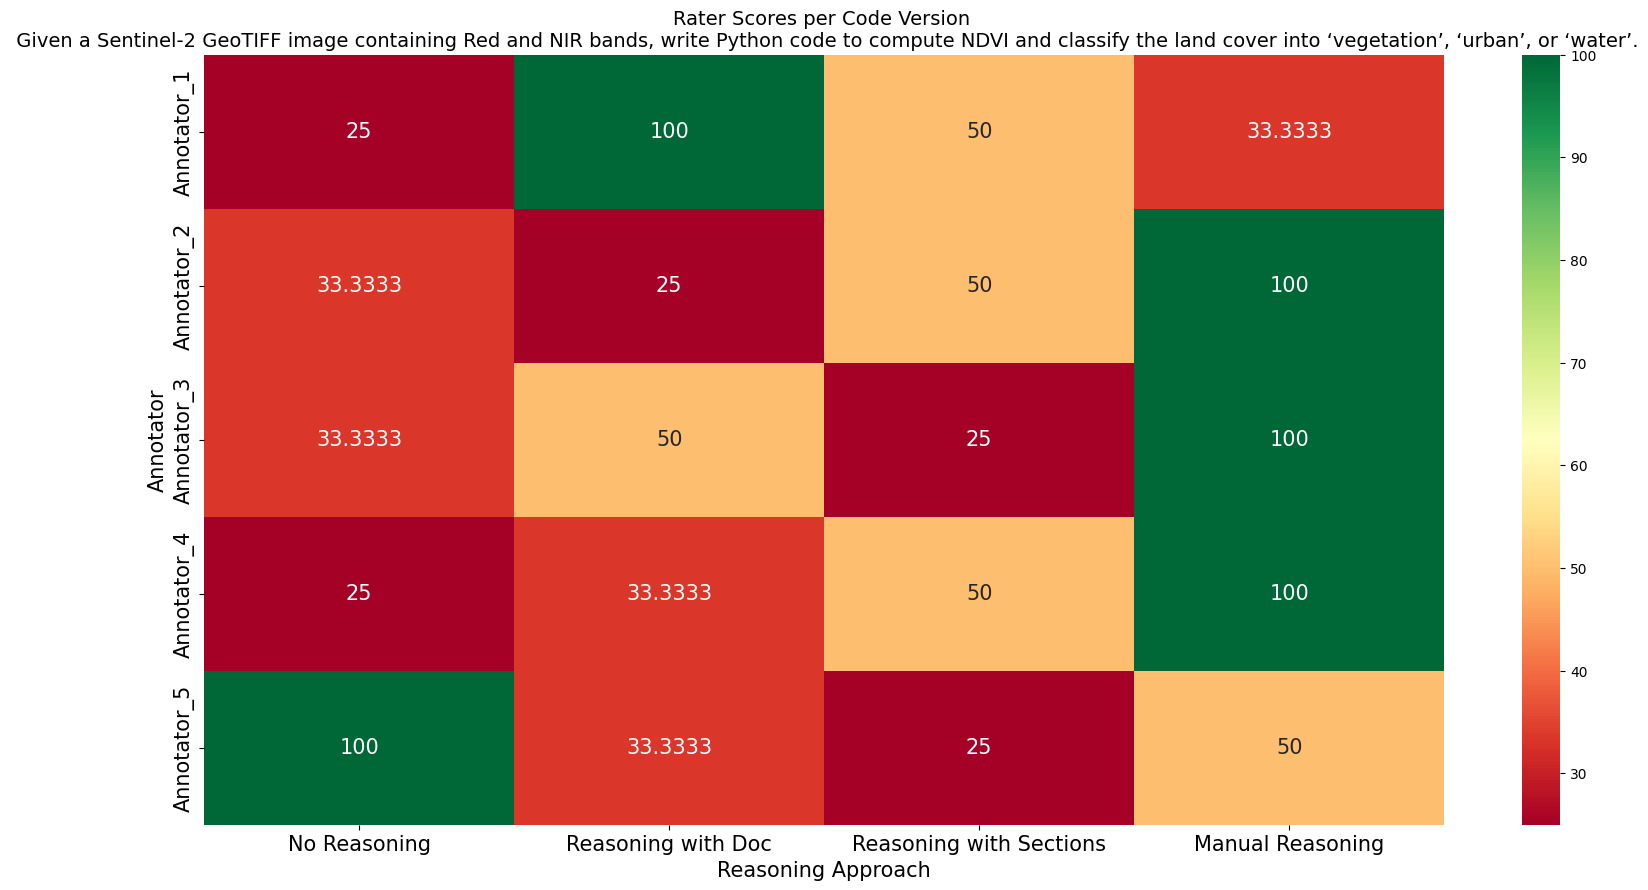

In [58]:
survey_data_5 = pd.read_csv("/Users/theo/Documents/Projects/LLM_fo_Code_Gen/annotations/participants/7 Step (Order Rank) - Given a Sentinel-2 GeoTIFF image containing Red and NIR bands, write Python code to compute NDVI and classify the land cover into ‘vegetation’, ‘urban’, or ‘water’..csv", skiprows=1)
question = "Given a Sentinel-2 GeoTIFF image containing Red and NIR bands, write Python code to compute NDVI and classify the land cover into ‘vegetation’, ‘urban’, or ‘water’."
plot_results(survey_data_5.copy(), question)

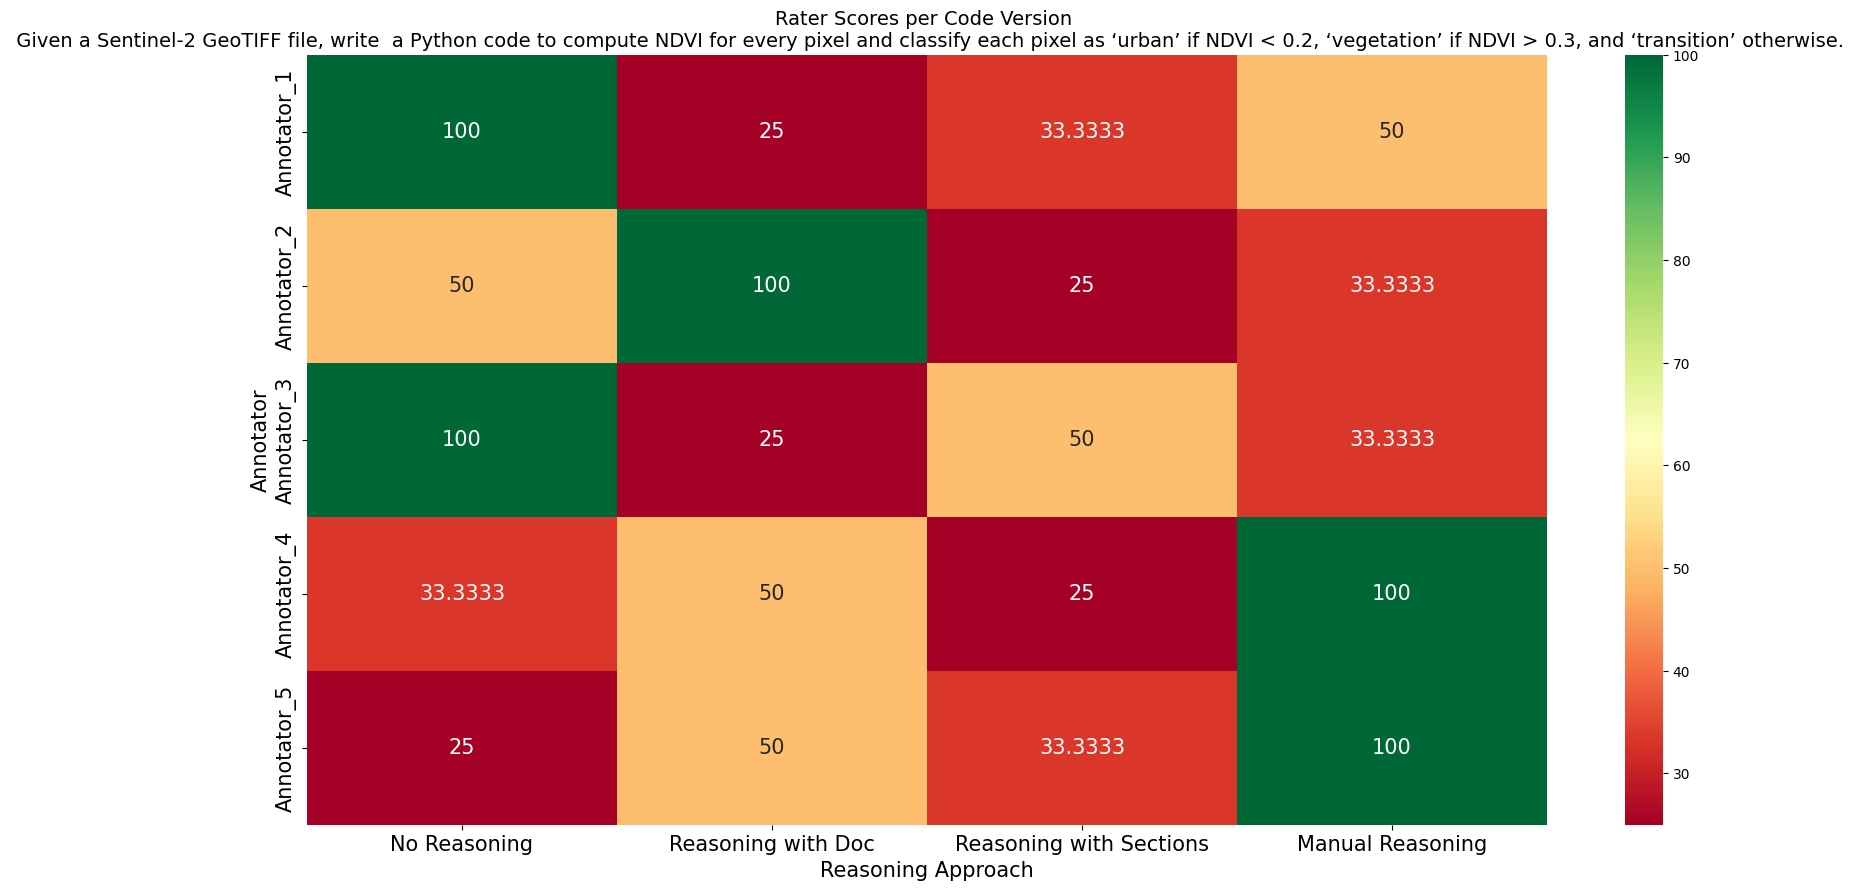

In [59]:
survey_data_7 = pd.read_csv("/Users/theo/Documents/Projects/LLM_fo_Code_Gen/annotations/participants/9 Step (Order Rank) - Given a Sentinel-2 GeoTIFF file, write a Python code to compute NDVI for every pixel and classify each pixel as ‘urban’ if NDVI  0.2, ‘vegetation’ if NDVI  0.3, and ‘transition’ otherwise..csv", skiprows=1)
question = "Given a Sentinel-2 GeoTIFF file, write  a Python code to compute NDVI for every pixel and classify each pixel as ‘urban’ if NDVI < 0.2, ‘vegetation’ if NDVI > 0.3, and ‘transition’ otherwise."
plot_results(survey_data_7.copy(), question)

In [ ]:
def combine_results(input_survey_data_ls):
    combined_df_ls = []
    for idx, input_survey_data in enumerate(input_survey_data_ls):
        input_survey_data['Display Name'] = input_survey_data['Display Name'].str.replace('Participant', 'Annotator_')

        # Define the mapping for options to reasoning types
        option_mapping = {
            'option_1': 'Reasoning with Doc',
            'option_2': 'Reasoning with Sections',
            'option_3': 'Manual Reasoning',
            'option_4': 'No Reasoning'
        }

        # Replace Opinion column values using the mapping
        input_survey_data['Opinion'] = input_survey_data['Opinion'].map(option_mapping)

        input_survey_data.rename(columns={'Opinion': 'Reasoning Approach'}, inplace=True)
        # Pivot the dataframe to get annotators as rows and reasoning types as columns
        output_data = input_survey_data.pivot(index='Display Name', columns='Reasoning Approach', values='Rating')

        # Sort columns in the desired order
        column_order = ['No Reasoning', 'Reasoning with Doc', 'Reasoning with Sections', 'Manual Reasoning']
        output_data = output_data[column_order]
        combined_df_ls.extend([output_data])
    combined_df = pd.concat(combined_df_ls)
    return combined_df

combined_survey_df = combine_results([survey_data_1.copy(), survey_data_2.copy(), survey_data_3.copy(), survey_data_4.copy(), survey_data_5.copy(), survey_data_6.copy(), survey_data_7.copy()])
combined_survey_df = combined_survey_df.reset_index()


Reasoning Approach,Display Name,No Reasoning,Reasoning with Doc,Reasoning with Sections,Manual Reasoning
0,Annotator_ 2,25.0,100.000000,50.000000,33.333333
1,Annotator_ 3,25.0,50.000000,33.333333,100.000000
2,Annotator_ 4,100.0,25.000000,33.333333,50.000000
3,Annotator_ 5,50.0,33.333333,25.000000,100.000000
4,Annotator_ 6,50.0,33.333333,25.000000,100.000000


Original Median Ratings by Reasoning Approach:
Reasoning Approach
No Reasoning               33.333333
Reasoning with Doc         50.000000
Reasoning with Sections    33.333333
Manual Reasoning           50.000000
dtype: float64

Normalized Median Ratings (0-5) by Reasoning Approach:
Reasoning Approach
No Reasoning               3.333333
Reasoning with Doc         5.000000
Reasoning with Sections    3.333333
Manual Reasoning           5.000000
dtype: float64


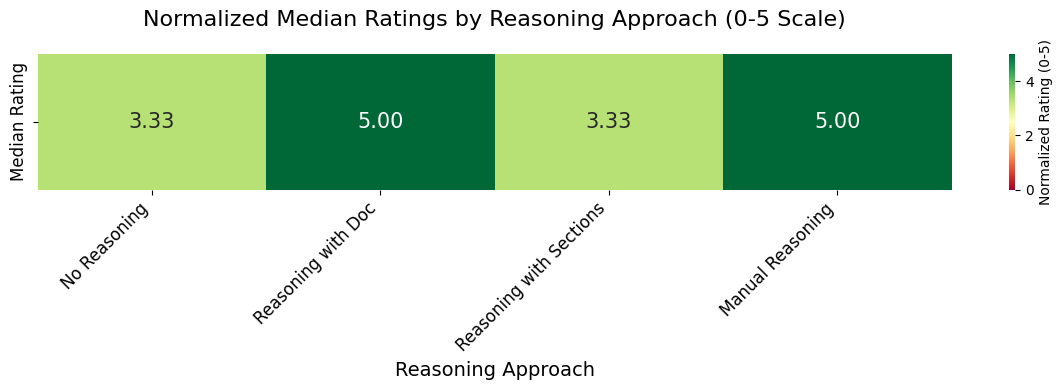


         Reasoning Approach  Original Median  Normalized (0-5)
0             No Reasoning        33.333333          3.333333
1       Reasoning with Doc        50.000000          5.000000
2  Reasoning with Sections        33.333333          3.333333
3         Manual Reasoning        50.000000          5.000000


In [40]:
reasoning_columns = ['No Reasoning', 'Reasoning with Doc', 'Reasoning with Sections', 'Manual Reasoning']
median_ratings = combined_survey_df[reasoning_columns].median()

# Normalize to range 0-5
min_rating = 0
max_rating = median_ratings.max()
normalized_ratings = 5 * (median_ratings - min_rating) / (max_rating - min_rating)

print("Original Median Ratings by Reasoning Approach:")
print(median_ratings)
print("\nNormalized Median Ratings (0-5) by Reasoning Approach:")
print(normalized_ratings)

# Reshape for heatmap (convert to 2D array)
heatmap_data = normalized_ratings.values.reshape(1, -1)

# Create heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn', 
            xticklabels=normalized_ratings.index,
            yticklabels=['Median Rating'],
            cbar_kws={'label': 'Normalized Rating (0-5)'},
            vmin=0, 
            vmax=5,
            annot_kws={'fontsize': 15})

plt.title("Normalized Median Ratings by Reasoning Approach (0-5 Scale)", fontsize=16, pad=20)
plt.xlabel("Reasoning Approach", fontsize=14)
plt.ylabel("")
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# Display comparison as DataFrame
comparison_df = pd.DataFrame({
    'Reasoning Approach': median_ratings.index,
    'Original Median': median_ratings.values,
    'Normalized (0-5)': normalized_ratings.values
})
print("\n", comparison_df)

##### Annotator preferences

In [60]:
all_surveys = pd.concat([survey_data_1.copy(), survey_data_2.copy(), survey_data_3.copy(), survey_data_4.copy(), survey_data_5.copy(), survey_data_6.copy(), survey_data_7.copy()])
all_surveys = all_surveys.reset_index()
all_surveys['Display Name'] = all_surveys['Display Name'].str.replace('Participant ', 'Annotator_')
all_surveys['Display Name'] = all_surveys['Display Name'].str.replace(r'Annotator_(\d+)', lambda m: f'Annotator_{int(m.group(1)) - 1}', regex=True)
all_surveys.head()

,level_0,index,Participant Id,Display Name,Submitted At,Opinion Id,Opinion,Rank,Of,Rating,Votes,Created At
0,0,0.0,68fe73c59f9cd61e548cf286,Annotator_5,"26 Oct 2025, 07:17 pm",68f963b0e3c81a9869bcb461,option_3,1,4,100.000000,5,"22 Oct 2025, 11:07 pm"
1,1,1.0,68fe73c59f9cd61e548cf286,Annotator_5,"26 Oct 2025, 07:17 pm",68f963bcc9f4b37f1ae91dbc,option_4,2,4,50.000000,5,"22 Oct 2025, 11:07 pm"
2,2,2.0,68fe73c59f9cd61e548cf286,Annotator_5,"26 Oct 2025, 07:17 pm",68f9632ac9f4b37f1ae91225,option_1,3,4,33.333333,5,"22 Oct 2025, 11:05 pm"
3,3,3.0,68fe73c59f9cd61e548cf286,Annotator_5,"26 Oct 2025, 07:17 pm",68f963a4e3c81a9869bcb182,option_2,4,4,25.000000,5,"22 Oct 2025, 11:07 pm"
4,4,4.0,68fd4a189f9cd61e547aa345,Annotator_4,"25 Oct 2025, 10:07 pm",68f963b0e3c81a9869bcb461,option_3,1,4,100.000000,5,"22 Oct 2025, 11:07 pm"


Median Ratings per Annotator by Reasoning Approach:
Opinion       No Reasoning  Doc Level Reasoning  Section Level Reasoning  \
Display Name                                                               
Annotator_1      25.000000            33.333333                50.000000   
Annotator_2      33.333333            50.000000                33.333333   
Annotator_3      50.000000            33.333333                33.333333   
Annotator_4      33.333333            33.333333                25.000000   
Annotator_5      25.000000            50.000000                33.333333   

Opinion       Manual Reasoning  
Display Name                    
Annotator_1          33.333333  
Annotator_2         100.000000  
Annotator_3          50.000000  
Annotator_4         100.000000  
Annotator_5         100.000000  


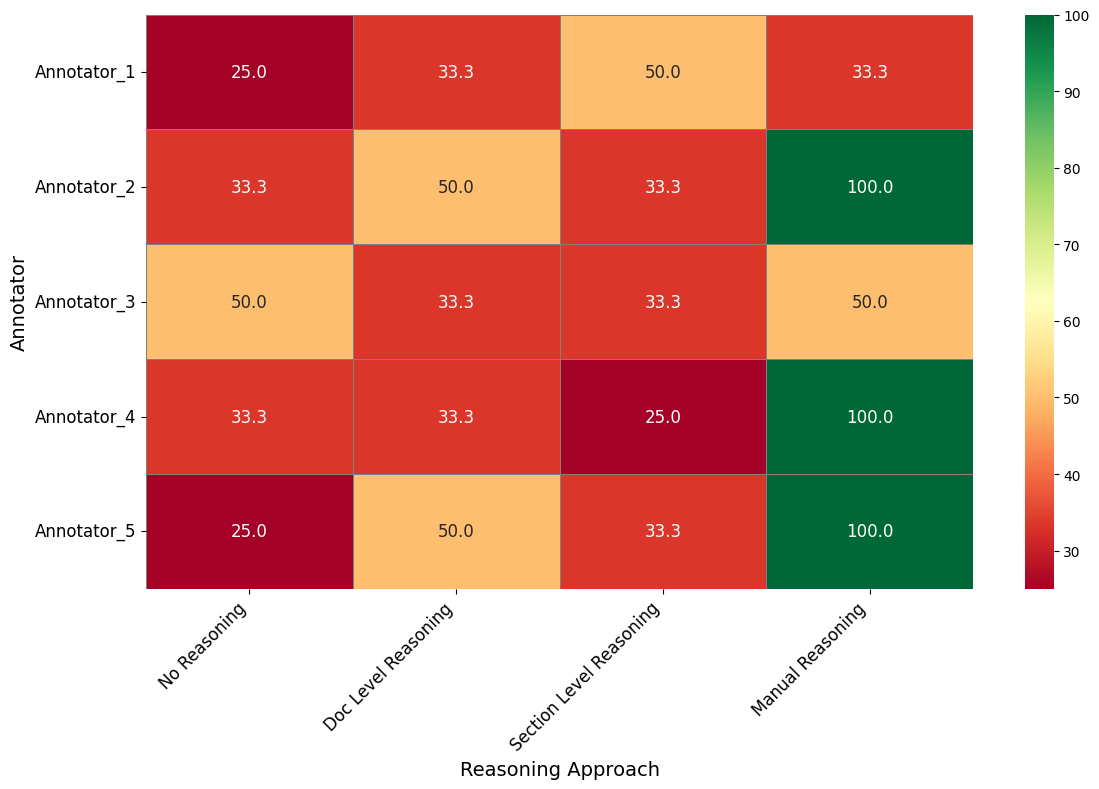

In [63]:
all_surveys_copy = all_surveys.copy()

# Define the mapping for options to reasoning types
option_mapping = {
    'option_1': 'Doc Level Reasoning',
    'option_2': 'Section Level Reasoning',
    'option_3': 'Manual Reasoning',
    'option_4': 'No Reasoning'
}

# Replace Opinion column values using the mapping
all_surveys_copy['Opinion'] = all_surveys_copy['Opinion'].map(option_mapping)

# Group by Display Name and Opinion, then calculate median
annotator_summary = all_surveys_copy.groupby(['Display Name', 'Opinion'])['Rating'].median().unstack()

# Sort columns in the desired order
column_order = ['No Reasoning', 'Doc Level Reasoning', 'Section Level Reasoning', 'Manual Reasoning']
annotator_summary = annotator_summary[column_order]

# Display the summary table
print("Median Ratings per Annotator by Reasoning Approach:")
print(annotator_summary)

# Create a heatmap visualization
plt.figure(figsize=(12, 8))
sns.heatmap(annotator_summary, 
            annot=True, 
            fmt='.1f', 
            cmap='RdYlGn', 
            #cbar_kws={'label': ''},
            vmin=annotator_summary.min().min(), 
            vmax=annotator_summary.max().max(),
            annot_kws={'fontsize': 12},
            linewidths=0.5,
            linecolor='gray')

#plt.title("Median Ratings per Annotator by Reasoning Approach", fontsize=16, pad=20)
plt.xlabel("Reasoning Approach", fontsize=14)
plt.ylabel("Annotator", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()